# Ming Xie Plots

In [1]:
%matplotlib inline
import sys
import os
import pickle

import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.patches as patches

import numpy as np

import scipy.interpolate as sinterp
from scipy.signal import find_peaks
import scipy.optimize as sopt
from genesis import genesis, lattice, analysis, lattice_operations, bsub, writers, wakefields,parsers
import genesis as gh #now gh.parsers []
sys.path.append('/sdf/group/ad/beamphysics/dcesar/python_dev')

colorlist=['#982649', '#6BCAE2', '#72bda3', '#ed6a5a', '#533a71']
#fde74c
colorlist2=['#E2836A','#6a7ee2','#74e26a']

#save info Load
savefolder='/sdf/home/d/dcesar/sdf_beamphysics/dcesar/documents'
savestem='Ming_Xie_presentation.png'

## Cu HXR Ming Xie

In [3]:
#https://uspas.fnal.gov/materials/09VU/Lecture7.pdf
Bp=3.336 #per GeV in [T m], 
L=4.03
k=1
f=L/2/k
gamma=15000/0.511;
gamma_min=1/(Bp*(0.511/1000)/f/4) #4 for 4 tesla
print("gamma min",gamma_min*0.511)
gamma=15000/0.511;

Bdz=2.8; #tesla
f=Bp*(gamma*0.511/1000)/Bdz
k=2*f/L
beta1=L*k*(k+1)/np.sqrt(k**2-1)
beta2=L*k*(k-1)/np.sqrt(k**2-1)
emi=0.27e-6/gamma;
print("beta min [um]", np.sqrt(beta1*emi)*1e6)
print("beta max [um]", np.sqrt(beta2*emi)*1e6)
print("rms div urad[]",np.sqrt(2*emi/(L*np.sqrt(-1+4*(f/L)**2)))*1e6)

gamma min 2416.067146282973
beta min [um] 19.18797703760902
beta max [um] 17.133791611049716
rms div urad[] 0.7197077181350268


In [4]:
def Lg(emittance,phEnergy):
    gamma0=15000/0.511
    delgamma=2.5/0.511
    current=6e3
    #emittance=0.27e-6
    plam=1240e-9/phEnergy
    lamU=0.026
    Kgen=np.sqrt(2*gamma0**2*plam/lamU-1)
    
    Bp=3.336 #per GeV in [T m], 
    L=4.03
    Bdz=4; #tesla
    f=Bp*(gamma0*0.511/1000)/Bdz
    k=2*f/L
    beta1=L*k*(k+1)/np.sqrt(k**2-1)
    beta2=L*k*(k-1)/np.sqrt(k**2-1)
    sigBeam=(np.sqrt(beta1*emittance/gamma0)+np.sqrt(beta2*emittance/gamma0))/2;
    
    MX=analysis.MingXie(Kgen,2*np.pi/lamU,gamma0,delgamma/gamma0,current,sigBeam,emittance,plam,0)
    #print(MX)
    Lg=MX['Lg']
    return Lg
Lg(0.2e-6,50e3)

5.488193722507566

In [5]:
1240e-9/(0.026/(2*gamma**2)*(1+1.5**2)/2)

50578.469719846275

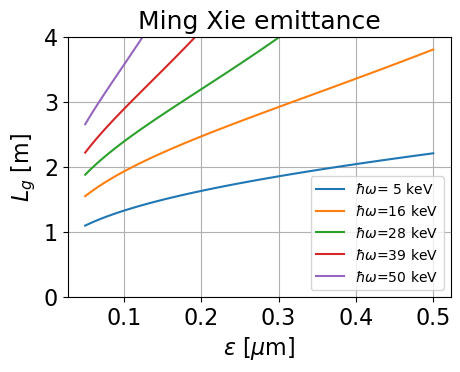

In [6]:
fig = plt.figure(num=1,figsize=[3.375*1.61*2,3.375])
fig.clf()

ax=plt.subplot(1,2,1)
emis=np.linspace(0.05e-6,0.5e-6,100)
Es=np.linspace(5e3,50e3,5);

for phE in Es:
    ys=[Lg(x,phE) for x in emis]
    ax.plot(emis*1e6,ys,label='$\hbar\omega$={:2.0f} keV'.format(phE*1e-3))
ax.set_ylim([0,4])
plt.legend()
ax.set_title('Ming Xie emittance',fontsize=18)
ax.tick_params(labelsize=16)
ax.grid(which='both')
ax.set_xlabel('$\epsilon$ [$\mu$m]',fontsize=16)
ax.set_ylabel('$L_g$ [m]',fontsize=16);

In [99]:
1240e-9/50e3/4/np.pi*gamma

5.793115345419283e-08

In [112]:
def Lg(Bdz,phEnergy):
    gamma0=15000/0.511
    delgamma=2.5/0.511
    current=6e3
    emittance=0.1e-6
    plam=1240e-9/phEnergy
    lamU=0.026
    Kgen=np.sqrt(2*gamma0**2*plam/lamU-1)
    
    Bp=3.336 #per GeV in [T m], 
    L=4.03
    #Bdz=4; #tesla
    f=Bp*(gamma0*0.511/1000)/Bdz
    k=2*f/L
    beta1=L*k*(k+1)/np.sqrt(k**2-1)
    beta2=L*k*(k-1)/np.sqrt(k**2-1)
    sigBeam=(np.sqrt(beta1*emittance/gamma0)+np.sqrt(beta2*emittance/gamma0))/2;
    
    MX=analysis.MingXie(Kgen,2*np.pi/lamU,gamma0,delgamma/gamma0,current,sigBeam,emittance,plam,0)
    #print(MX)
    Lg=MX['Lg']
    return Lg
Lg(4,50e3)

3.5681794167604344

In [14]:
gamma0=3800/0.511
Bp=3.336 #per GeV in [T m], 
L=4.03
Bdz=3; #tesla
f=Bp*(gamma0*0.511/1000)/Bdz
k=2*f/L
np.arccos(1-L**2/(2*f**2))*180/np.pi

56.96044216605045

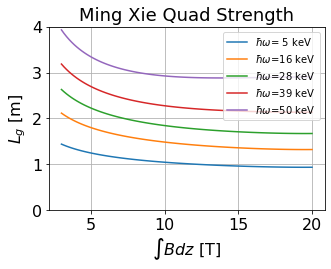

In [113]:
fig = plt.figure(num=1,figsize=[3.375*1.61*2,3.375])
fig.clf()

ax=plt.subplot(1,2,1)
qs=np.linspace(3,20,100)
Es=np.linspace(5e3,50e3,5);

for phE in Es:
    ys=[Lg(x,phE) for x in qs]
    ax.plot(qs,ys,label='$\hbar\omega$={:2.0f} keV'.format(phE*1e-3))
ax.set_ylim([0,4])
plt.legend()
ax.set_title('Ming Xie Quad Strength',fontsize=18)
ax.tick_params(labelsize=16)
ax.grid(which='both')
ax.set_xlabel('$\int Bdz$ [T]',fontsize=16)
ax.set_ylabel('$L_g$ [m]',fontsize=16);

## SC HXR Ming Xie

/lscratch/dcesar/tmp/ipykernel_4081743/2282314993.py:12: RuntimeWarning: invalid value encountered in sqrt
  Kgen=np.sqrt(2*gamma0**2*plam/lamU-1)
/sdf/group/ad/beamphysics/dcesar/miniforge3/lib/python3.10/site-packages/genesis/analysis.py:129: RuntimeWarning: divide by zero encountered in divide
  Lg1d=1/2/ku/rho/np.sqrt(3)
/sdf/group/ad/beamphysics/dcesar/miniforge3/lib/python3.10/site-packages/genesis/analysis.py:146: RuntimeWarning: invalid value encountered in divide
  Psat=1.6*rho*(Lg1d/Lg)**2*Pbeam


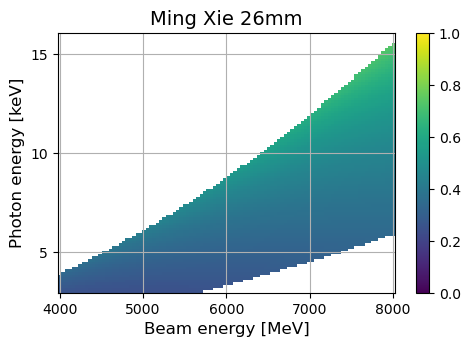

In [2]:
fig = plt.figure(num=1,figsize=[3.375*1.61,3.375])
fig.clf()
ax=plt.subplot(1,1,1)

def Lsat(bmEnergy,phEnergy):
    gamma0=bmEnergy/0.511
    delgamma=1.12/0.511
    current=1.3e3
    emittance=0.27e-6
    plam=1240e-9/phEnergy
    lamU=0.026
    Kgen=np.sqrt(2*gamma0**2*plam/lamU-1)
    Kgen[Kgen>2.44/np.sqrt(2)]=0
    Kgen[Kgen<1/np.sqrt(2)]=0
    Bdz=4; #tesla
    L=4.03;
    Bp=3.336 #per GeV in [T m];
    f=Bp*(gamma0*0.511/1000)/Bdz
    k=2*f/L
    beta1=L*k*(k+1)/np.sqrt(k**2-1)
    beta2=L*k*(k-1)/np.sqrt(k**2-1)
    sigBeam=np.sqrt(np.sqrt(beta1*beta2)*emittance/gamma0)
    MX=analysis.MingXie(Kgen,2*np.pi/lamU,gamma0,delgamma/gamma0,current,sigBeam,emittance,plam,0)
    #print(MX)
    Lsat=MX['Lg']*np.log(MX['Psat']/MX['Pnoise'])
    return Lsat

bm_ens=np.linspace(4000,8000,100);
ph_ens=np.logspace(np.log10(5000),np.log10(20000),100);
ph_ens=np.linspace(3000,16000,100);
[B,P]=np.meshgrid(bm_ens,ph_ens,indexing='ij')
L=Lsat(B,P);
p=ax.pcolormesh(B,P/1000,L/100,vmin=0,vmax=1)
#ax.set_yscale('log')
ax.set_xlabel('Beam energy [MeV]',fontsize=12)
ax.set_ylabel('Photon energy [keV]',fontsize=12)
#for ele,eV in zip(edges,edge_eV):
#    ax.annotate(ele,(8100,(eV)),annotation_clip=False)
#    ax.plot([4000,8000],[eV,eV],'--k',alpha=0.5)
ax.set_title('Ming Xie 26mm',fontsize=14)
ax.grid(which='major')
ax.set_yticks([5,10,15])
ax.set_yticklabels([5,10,15])
plt.colorbar(p)
plt.show()

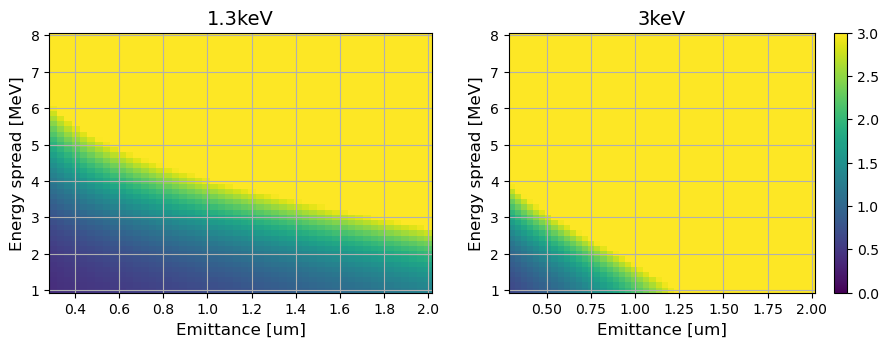

In [89]:
fig = plt.figure(num=1,figsize=[3.375*1.61*2,3.375])
fig.clf()


def Lg(emi,de,i=0.9,pe=1300):
    gamma0=3800/0.511
    delgamma=de/0.511
    current=i*1e3
    emittance=emi*1e-6
    plam=1240e-9/pe
    lamU=0.026
    Kgen=np.sqrt(2*gamma0**2*plam/lamU-1)
    if Kgen>2.54/np.sqrt(2):
        print(Kgen)
        return np.NaN
    Bdz=3; #tesla
    L=4.03;
    Bp=3.336 #per GeV in [T m];
    f=Bp*(gamma0*0.511/1000)/Bdz
    k=2*f/L
    beta1=L*k*(k+1)/np.sqrt(k**2-1)
    beta2=L*k*(k-1)/np.sqrt(k**2-1)
    sigBeam=np.sqrt(np.sqrt(beta1*beta2)*emittance/gamma0)
    MX=analysis.MingXie(Kgen,2*np.pi/lamU,gamma0,delgamma/gamma0,current,sigBeam,emittance,plam,0)
    #print(MX)
    Lg=MX['Lg']
    return Lg/3.4

emis=np.linspace(0.3,2,50);
des=np.linspace(1,8,50);
[X,Y]=np.meshgrid(emis,des,indexing='ij')

ax=plt.subplot(1,2,1)
L=Lg(X,Y);
p=ax.pcolormesh(X,Y,L,vmin=0,vmax=3)
ax.set_xlabel('Emittance [um]',fontsize=12)
ax.set_ylabel('Energy spread [MeV]',fontsize=12)
ax.set_title('1.3keV',fontsize=14)
ax.grid(which='major')

ax=plt.subplot(1,2,2)
L=Lg(X,Y,pe=3000);
p=ax.pcolormesh(X,Y,L,vmin=0,vmax=3)
ax.set_xlabel('Emittance [um]',fontsize=12)
ax.set_ylabel('Energy spread [MeV]',fontsize=12)
ax.set_title('3keV',fontsize=14)
ax.grid(which='major')
#ax.set_yticks([5,10,15])
#ax.set_yticklabels([5,10,15])
plt.colorbar(p)
plt.show()

In [88]:
def LgSXR(emi,de,i=0.9,pe=1300):
    gamma0=3800/0.511
    delgamma=de/0.511
    current=i*1e3
    emittance=emi*1e-6
    plam=1240e-9/pe
    lamU=0.039
    Kgen=np.sqrt(2*gamma0**2*plam/lamU-1)
    if Kgen>5.44/np.sqrt(2):
        return np.NaN
    Bdz=3; #tesla
    L=4.4;
    Bp=3.336 #per GeV in [T m];
    f=Bp*(gamma0*0.511/1000)/Bdz
    k=2*f/L
    beta1=L*k*(k+1)/np.sqrt(k**2-1)
    beta2=L*k*(k-1)/np.sqrt(k**2-1)
    sigBeam=np.sqrt(np.sqrt(beta1*beta2)*emittance/gamma0)
    MX=analysis.MingXie(Kgen,2*np.pi/lamU,gamma0,delgamma/gamma0,current,sigBeam,emittance,plam,0)
    #print(MX)
    Lg=MX['Lg']
    return Lg/3.4
LgSXR(0.25, 4, pe=400)

0.6487994003796808

In [92]:
from scipy.optimize import minimize
def cost(params):
    x, y, z = params
    term1 = (np.abs(Lg(x, y, z, pe=1300) - 1.6))
    term2 = (np.abs(Lg(x, y, z, pe=3000) - 2.3))
    term3 = (np.abs(LgSXR(x, y, pe=400) - 1.0))
    return (term1 + term2 + term3)/3

# Initial guess
x0 = [0.5, 3, 1]

# Run the optimizer
result = minimize(cost, x0, method="Nelder-Mead")  # Nelder-Mead is robust for non-smooth funcs

print("Optimization success:", result.success)
print("Optimal params:", result.x)
print("Cost at optimum:", result.fun)

Optimization success: True
Optimal params: [0.30487086 4.95008487 1.71239507]
Cost at optimum: 0.23451860015728762


1.9111120491867228
1.8141118347151943


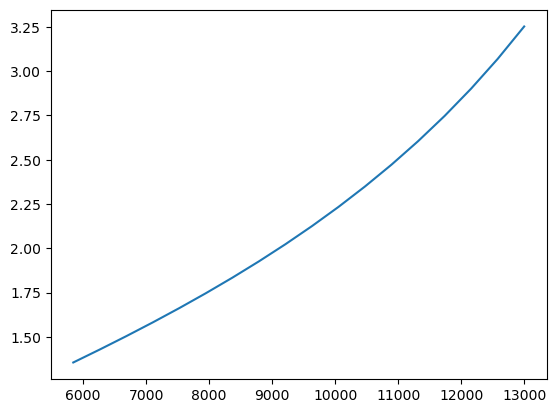

In [47]:
def LgHXR(enscale=1,emi=0.35,de=4.0,i=1.5,pe=1300):
    gamma0=3800/0.511*enscale
    delgamma=de/0.511
    current=i*1e3
    emittance=emi*1e-6
    plam=1240e-9/pe
    lamU=0.026
    Kgen=np.sqrt(2*gamma0**2*plam/lamU-1)
    if Kgen>2.54/np.sqrt(2):
        print(Kgen)
        return np.NaN
    Bdz=3; #tesla
    L=4.03;
    Bp=3.336 #per GeV in [T m];
    f=Bp*(gamma0*0.511/1000)/Bdz
    k=2*f/L
    beta1=L*k*(k+1)/np.sqrt(k**2-1)
    beta2=L*k*(k-1)/np.sqrt(k**2-1)
    sigBeam=np.sqrt(np.sqrt(beta1*beta2)*emittance/gamma0)
    MX=analysis.MingXie(Kgen,2*np.pi/lamU,gamma0,delgamma/gamma0,current,sigBeam,emittance,plam,0)
    #print(MX)
    Lg=MX['Lg']
    return Lg/3.4

ax=plt.gca()
xs=np.linspace(5000,13000,20)
ax.plot(xs,[LgHXR(pe=x,enscale=2.1) for x in xs])
plt.show()

2.067552274740128
1.8855994437130175


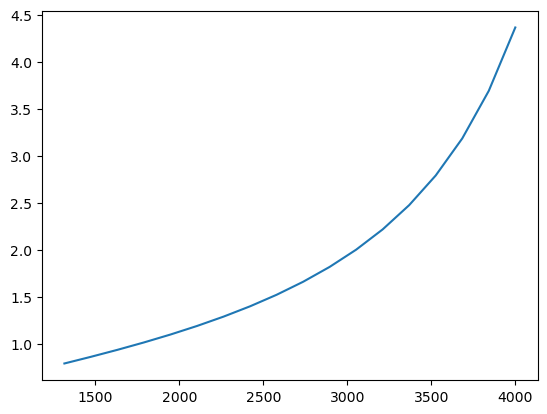

In [48]:
ax=plt.gca()
xs=np.linspace(1000,4000,20)
ax.plot(xs,[LgHXR(pe=x,enscale=1.0) for x in xs])
plt.show()

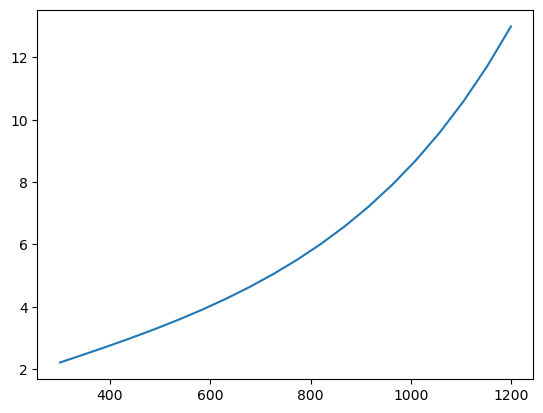

In [49]:
def LgSXR(enscale=1,emi=2,de=4,i=0.75,pe=1300):
    gamma0=3800/0.511*enscale
    delgamma=de/0.511
    current=i*1e3
    emittance=emi*1e-6
    plam=1240e-9/pe
    lamU=0.039
    Kgen=np.sqrt(2*gamma0**2*plam/lamU-1)
    if Kgen>5.44/np.sqrt(2):
        return np.NaN
    Bdz=3; #tesla
    L=4.4;
    Bp=3.336 #per GeV in [T m];
    f=Bp*(gamma0*0.511/1000)/Bdz
    k=2*f/L
    beta1=L*k*(k+1)/np.sqrt(k**2-1)
    beta2=L*k*(k-1)/np.sqrt(k**2-1)
    sigBeam=np.sqrt(np.sqrt(beta1*beta2)*emittance/gamma0)
    MX=analysis.MingXie(Kgen,2*np.pi/lamU,gamma0,delgamma/gamma0,current,sigBeam,emittance,plam,0)
    #print(MX)
    Lg=MX['Lg']
    return Lg/3.4

ax=plt.gca()
xs=np.linspace(300,1200,20)
ax.plot(xs,[LgSXR(pe=x,enscale=1.0) for x in xs])
plt.show()

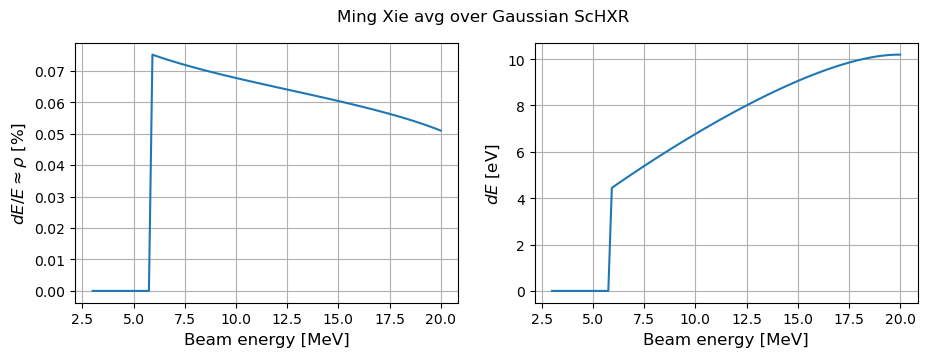

In [29]:
#power function from below, accounts for post sat taper to some extent ...
def int_MX(ts,cur,mxp):
    MX=analysis.MingXie(mxp[0],mxp[1],mxp[2],mxp[3],cur,mxp[5],mxp[6],mxp[7],mxp[8])
    Lgs=MX['Lg']
    psats=MX['Psat']
    bw = np.sqrt(3*np.sqrt(3)*MX['rho']/mxp[1]/24)
    p=np.trapz(power(psats,gl=Lgs/max(Lgs),und_len=24,sat_gl=21,postamp=2.25),ts)
    return np.trapz(bw*power(psats,gl=Lgs/max(Lgs),und_len=24,sat_gl=21,postamp=2.25),ts)/p

fig = plt.figure(num=1,figsize=[3.375*1.61*2,3.375])
fig.clf()

def f(bmEnergy,phEnergy):
    gamma0=bmEnergy/0.511
    delgamma=1.12/0.511
    current=1.3e3
    emittance=0.27e-6
    plam=1240e-9/phEnergy
    lamU=0.026
    Kgen=np.sqrt(2*gamma0**2*plam/lamU-1)
    if Kgen>2.44/np.sqrt(2):
        return 0
    if Kgen<0.4/np.sqrt(2):
        return 0
    Bdz=4; #tesla
    L=4.03;
    Bp=3.336 #per GeV in [T m];
    f=Bp*(gamma0*0.511/1000)/Bdz
    k=2*f/L
    beta1=L*k*(k+1)/np.sqrt(k**2-1)
    beta2=L*k*(k-1)/np.sqrt(k**2-1)
    sigBeam=np.sqrt(np.sqrt(beta1*beta2)*emittance/gamma0)
    #MX=analysis.MingXie(Kgen,2*np.pi/lamU,gamma0,delgamma/gamma0,current,sigBeam,emittance,plam,0)
    #print(MX)
    ts=np.linspace(-100,100,500);
    cur=current*np.exp(-0.5*(ts/20)**2)
    bw=int_MX(ts*1e-15,cur,[Kgen,2*np.pi/lamU,gamma0,delgamma/gamma0,current,sigBeam,emittance,plam,0])
    return bw

#ph_ens=np.logspace(np.log10(5000),np.log10(20000),100);
ph_ens=np.linspace(3000,20000,100);
bw=np.array([f(8000,x) for x in ph_ens]);
ax=plt.subplot(1,2,1)
ax.plot(ph_ens/1000,bw*100)
ax2=plt.subplot(1,2,2,sharex=ax)
ax2.plot(ph_ens/1000,bw*ph_ens)
#ax.set_yscale('log')
ax.set_xlabel('Beam energy [MeV]',fontsize=12)
ax.set_ylabel(r'$dE/E \approx \rho$ [%]',fontsize=12)
ax2.set_xlabel('Beam energy [MeV]',fontsize=12)
ax2.set_ylabel(r'$dE$ [eV]',fontsize=12)

#ax.set_title('Ming Xie ScHXR Flattop',fontsize=14)
ax.grid(which='major')
ax2.grid(which='major')
fig.suptitle('Ming Xie avg over Gaussian ScHXR') 
plt.show()



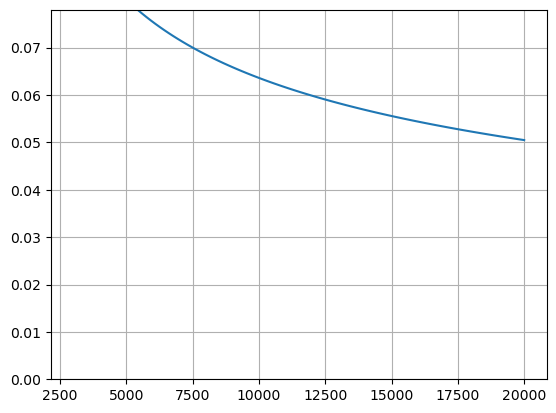

In [37]:
ax=plt.gca()
ax.plot(ph_ens,0.07*(ph_ens/7500)**(-1/3))
ax.set_ylim([0,0.078])
ax.grid(which='both')
plt.show()

## SC SXR

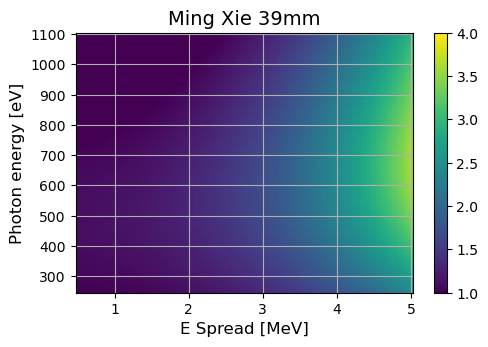

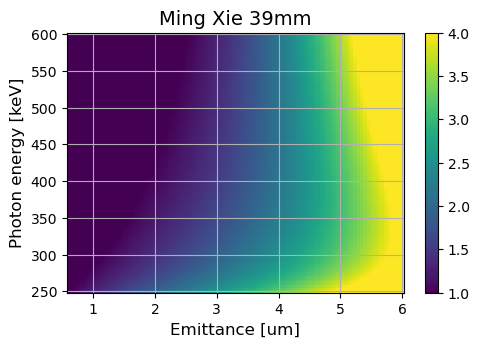

In [2]:
fig = plt.figure(num=1,figsize=[3.375*1.61,3.375])
fig.clf()
ax=plt.subplot(1,1,1)

def Lsat(emi,phEnergy):
    gamma0=3500/0.511
    delgamma=3/0.511
    current=1.25e3
    emittance=emi*1e-6
    plam=1240e-9/phEnergy
    lamU=0.039
    Kgen=np.sqrt(2*gamma0**2*plam/lamU-1)
    Kgen[Kgen>5.44/np.sqrt(2)]=0
    Kgen[Kgen<1/np.sqrt(2)]=0
    Bdz=3; #tesla
    L=4.4;
    Bp=3.336 #per GeV in [T m];
    f=Bp*(gamma0*0.511/1000)/Bdz
    k=2*f/L
    beta1=L*k*(k+1)/np.sqrt(k**2-1)
    beta2=L*k*(k-1)/np.sqrt(k**2-1)
    sigBeam=np.sqrt(np.sqrt(beta1*beta2)*emittance/gamma0)
    MX=analysis.MingXie(Kgen,2*np.pi/lamU,gamma0,delgamma/gamma0,current,sigBeam,emittance,plam,0)
    #print(MX)
    Lsat=MX['Lg']*np.log(MX['Psat']/MX['Pnoise'])
    return Lsat

emis=np.linspace(0.6,6,100);
#ph_ens=np.logspace(np.log10(250),np.log10(1000),100);
ph_ens=np.linspace(250,600,100);
[B,P]=np.meshgrid(emis,ph_ens,indexing='ij')
L=Lsat(B,P);
L=L.reshape(100,100)
p=ax.pcolormesh(B.reshape(100,100),P.reshape(100,100),L/np.min(L,axis=1),vmin=1,vmax=4)
#ax.set_yscale('log')
ax.set_xlabel('Emittance [um]',fontsize=12)
ax.set_ylabel('Photon energy [keV]',fontsize=12)
#for ele,eV in zip(edges,edge_eV):
#    ax.annotate(ele,(8100,(eV)),annotation_clip=False)
#    ax.plot([4000,8000],[eV,eV],'--k',alpha=0.5)
ax.set_title('Ming Xie 39mm',fontsize=14)
ax.grid(which='major')
#ax.set_yticks([5,10,15])
#ax.set_yticklabels([5,10,15])
plt.colorbar(p)
plt.show()

In [27]:
np.min(L,axis=1)

array([ 40.73875718,  42.42512095,  44.04699234,  45.61846753,
        47.15057572,  48.65217813,  50.13055481,  51.59180219,
        53.04111088,  54.48296504,  55.92128877,  57.35955572,
        58.80087268,  60.24804425,  61.70362361,  63.16995289,
        64.64919558,  66.14336288,  67.65433525,  69.18388026,
        70.73366746,  72.30528078,  73.90022914,  75.51995532,
        77.16584367,  78.83922661,  80.54139036,  82.27357986,
        84.03700302,  85.83283453,  87.66221912,  89.5262745 ,
        91.42609392,  93.36274847,  95.33728913,  97.35074856,
        99.40414276, 101.49847256, 103.63472488, 105.81387399,
       108.03688258, 110.3047027 , 112.61827672, 114.97853811,
       117.38641216, 119.84281674, 122.34866285, 124.90485522,
       127.51229287, 130.17186954, 132.8844742 , 135.65099141,
       138.47230176, 141.34928219, 144.28280631, 147.27374478,
       150.3229655 , 153.43133394, 156.59971339, 159.82896514,
       163.11994876, 166.47352226, 169.89054229, 173.37

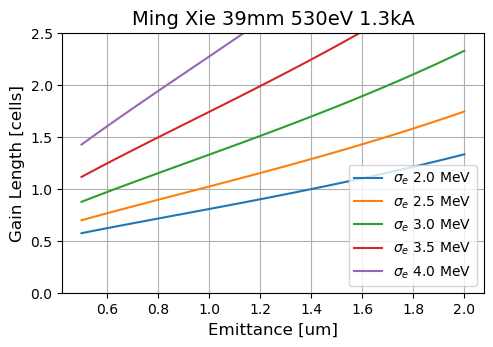

In [36]:
fig = plt.figure(num=1,figsize=[3.375*1.61,3.375])
fig.clf()
ax=plt.subplot(1,1,1)

def Lgain(emi,espr,phEnergy):
    gamma0=3500/0.511
    delgamma=espr/0.511
    current=1.3e3
    emittance=emi*1e-6
    plam=1240e-9/phEnergy
    lamU=0.039
    Kgen=np.sqrt(2*gamma0**2*plam/lamU-1)
    Kgen=np.array([Kgen])
    Kgen[Kgen>5.44/np.sqrt(2)]=0
    Kgen[Kgen<1/np.sqrt(2)]=0
    Bdz=3; #tesla
    L=4.4;
    Bp=3.336 #per GeV in [T m];
    f=Bp*(gamma0*0.511/1000)/Bdz
    k=2*f/L
    beta1=L*k*(k+1)/np.sqrt(k**2-1)
    beta2=L*k*(k-1)/np.sqrt(k**2-1)
    sigBeam=np.sqrt(np.sqrt(beta1*beta2)*emittance/gamma0)
    MX=analysis.MingXie(Kgen,2*np.pi/lamU,gamma0,delgamma/gamma0,current,sigBeam,emittance,plam,0)
    #print(MX)
    Lsat=MX['Lg']
    return Lsat

emis=np.linspace(0.5,2,100);
#ph_ens=np.logspace(np.log10(250),np.log10(1000),100);
ph_en=530
espr=[2,2.5,3,3.5,4]
for es in espr:
    p=ax.plot(emis,Lgain(emis,es,ph_en)/4.0,label=r"$\sigma_e$ {:2.1f} MeV".format(es))
#ax.set_yscale('log')
ax.set_xlabel('Emittance [um]',fontsize=12)
ax.set_ylabel('Gain Length [cells]',fontsize=12)
ax.set_ylim([0,2.5])
#for ele,eV in zip(edges,edge_eV):
#    ax.annotate(ele,(8100,(eV)),annotation_clip=False)
#    ax.plot([4000,8000],[eV,eV],'--k',alpha=0.5)
ax.set_title('Ming Xie 39mm 530eV 1.3kA',fontsize=14)
ax.grid(which='major')
plt.legend()
plt.savefig('SXR_MX_39mm_530eV.png')
plt.show()

In [12]:
import inspect
print(inspect.getsource(analysis.MingXie))

def MingXie(Kgen,ku,gamma,rel_e_spread,I,beam_size,normemittance,wavelength,iwityp):
    IA=17.045e3;
    fc=(jv(0,Kgen**2/2/(1+Kgen**2))-jv(1,Kgen**2/2/(1+Kgen**2))) if iwityp==0 else 1.0
    rho=1/gamma*((Kgen*fc/(4*ku*beam_size))**2*I/IA)**(1/3)
    Lg1d=1/2/ku/rho/np.sqrt(3)
    
    Lr=4*np.pi*beam_size**2/wavelength
    nd=Lg1d/Lr
    
    geoemittance=normemittance/gamma
    beta=beam_size**2/geoemittance
    ne=(Lg1d/beta)*(4*np.pi*geoemittance/wavelength)
    ng=2*(Lg1d*ku)*(rel_e_spread)
    
    a=[0,0.45,0.57,0.55,1.6,3,2,0.35,2.9,2.4,51,0.95,3,5.4,0.7,1.9,1140,2.2,2.9,3.2]
    n=(a[1]*(nd**a[2]) + a[3]*(ne**a[4]) + a[5]*(ng**a[6]) +
       a[7]*(ne**a[8])*(ng**a[9]) + a[10]*(nd**a[11])*(ng**a[12]) +a[13]*(nd**a[14])*(ne**a[15]) +
       a[16]*(nd**a[17])*(ne**a[18])*(ng**a[19]))
    Lg=Lg1d*(n+1)
    Pbeam=gamma*0.511e-3*I*1e-3*1e12 #from Pbeam[TW]=E0[GeV]I[kA]
    Pnoise=gamma*0.511e6*3e8*1.6e-19*rho**2/wavelength
    Psat=1.6*rho*(Lg1d/Lg)**2*Pbeam
    return {"rho":rho,

# 20 vs 100 pc SXR and HXR

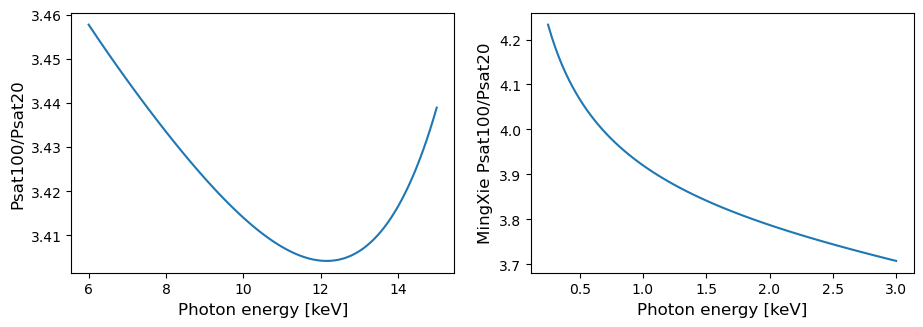

In [24]:
fig = plt.figure(num=1,figsize=[3.375*1.61*2,3.375])
fig.clf()

ax=plt.subplot(1,2,1)
def Psat_100(phEnergy):
    bmEnergy=8000
    gamma0=bmEnergy/0.511
    delgamma=1.12/0.511
    current=1.3e3
    emittance=0.27e-6
    plam=1240e-9/phEnergy
    lamU=0.026
    Kgen=np.sqrt(2*gamma0**2*plam/lamU-1)
    Kgen=np.array([Kgen])
    Kgen[Kgen>2.44/np.sqrt(2)]=0
    Kgen[Kgen<1/np.sqrt(2)]=0
    Bdz=4; #tesla
    L=4.03;
    Bp=3.336 #per GeV in [T m];
    f=Bp*(gamma0*0.511/1000)/Bdz
    k=2*f/L
    beta1=L*k*(k+1)/np.sqrt(k**2-1)
    beta2=L*k*(k-1)/np.sqrt(k**2-1)
    sigBeam=np.sqrt(np.sqrt(beta1*beta2)*emittance/gamma0)
    MX=analysis.MingXie(Kgen,2*np.pi/lamU,gamma0,delgamma/gamma0,current,sigBeam,emittance,plam,0)
    #print(MX)
    return MX['Psat']#MX['rho']*MX['Lg1d']/MX['Lg']

def Psat_20(phEnergy):
    bmEnergy=8000
    gamma0=bmEnergy/0.511
    delgamma=1.0/0.511
    current=0.52e3
    emittance=0.19e-6
    plam=1240e-9/phEnergy
    lamU=0.026
    Kgen=np.sqrt(2*gamma0**2*plam/lamU-1)
    Kgen=np.array([Kgen])
    Kgen[Kgen>2.44/np.sqrt(2)]=0
    Kgen[Kgen<1/np.sqrt(2)]=0
    Bdz=4; #tesla
    L=4.03;
    Bp=3.336 #per GeV in [T m];
    f=Bp*(gamma0*0.511/1000)/Bdz
    k=2*f/L
    beta1=L*k*(k+1)/np.sqrt(k**2-1)
    beta2=L*k*(k-1)/np.sqrt(k**2-1)
    sigBeam=np.sqrt(np.sqrt(beta1*beta2)*emittance/gamma0)
    MX=analysis.MingXie(Kgen,2*np.pi/lamU,gamma0,delgamma/gamma0,current,sigBeam,emittance,plam,0)
    #print(MX)
    return MX['Psat']#MX['rho']*MX['Lg1d']/MX['Lg']

ph_ens=np.logspace(np.log10(5000),np.log10(20000),100);
ph_ens=np.linspace(6000,15000,100);
ax.plot(ph_ens/1000,[Psat_100(x)/Psat_20(x) for x in ph_ens])
#ax.plot(ph_ens/1000,[Psat_20(x) for x in ph_ens])
#ax.set_yscale('log')
ax.set_ylabel('Psat100/Psat20',fontsize=12)
ax.set_xlabel('Photon energy [keV]',fontsize=12)




ax=plt.subplot(1,2,2)
def Psat_100(phEnergy):
    bmEnergy=8000
    gamma0=bmEnergy/0.511
    delgamma=1.12/0.511
    current=1.35e3
    emittance=0.27e-6
    plam=1240e-9/phEnergy
    lamU=0.056
    Kgen=np.sqrt(2*gamma0**2*plam/lamU-1)
    Kgen=np.array([Kgen])
   # Kgen[Kgen>2.44/np.sqrt(2)]=0
    Kgen[Kgen<1/np.sqrt(2)]=0
    Bdz=4; #tesla
    L=4.4;
    Bp=3.336 #per GeV in [T m];
    f=Bp*(gamma0*0.511/1000)/Bdz
    k=2*f/L
    beta1=L*k*(k+1)/np.sqrt(k**2-1)
    beta2=L*k*(k-1)/np.sqrt(k**2-1)
    sigBeam=np.sqrt(np.sqrt(beta1*beta2)*emittance/gamma0)
    MX=analysis.MingXie(Kgen,2*np.pi/lamU,gamma0,delgamma/gamma0,current,sigBeam,emittance,plam,0)
    #print(MX)
    return MX['Psat']#MX['rho']*MX['Lg1d']/MX['Lg']

def Psat_20(phEnergy):
    bmEnergy=8000
    gamma0=bmEnergy/0.511
    delgamma=1.0/0.511
    current=0.52e3
    emittance=0.18e-6
    plam=1240e-9/phEnergy
    lamU=0.056
    Kgen=np.sqrt(2*gamma0**2*plam/lamU-1)
    Kgen=np.array([Kgen])
 #   Kgen[Kgen>2.44/np.sqrt(2)]=0
    Kgen[Kgen<1/np.sqrt(2)]=0
    Bdz=4; #tesla
    L=4.4;
    Bp=3.336 #per GeV in [T m];
    f=Bp*(gamma0*0.511/1000)/Bdz
    k=2*f/L
    beta1=L*k*(k+1)/np.sqrt(k**2-1)
    beta2=L*k*(k-1)/np.sqrt(k**2-1)
    sigBeam=np.sqrt(np.sqrt(beta1*beta2)*emittance/gamma0)
    MX=analysis.MingXie(Kgen,2*np.pi/lamU,gamma0,delgamma/gamma0,current,sigBeam,emittance,plam,0)
    #print(MX)
    return MX['Psat']#MX['rho']*MX['Lg1d']/MX['Lg']

ph_ens=np.logspace(np.log10(5000),np.log10(20000),100);
ph_ens=np.linspace(250,3000,100);
ax.plot(ph_ens/1000,[Psat_100(x)/Psat_20(x) for x in ph_ens])
#ax.plot(ph_ens/1000,[Psat_20(x) for x in ph_ens])
#ax.set_yscale('log')
ax.set_ylabel('MingXie Psat100/Psat20',fontsize=12)
ax.set_xlabel('Photon energy [keV]',fontsize=12)

plt.show()

In [13]:
import inspect
print(inspect.getsource(analysis.MingXie))

def MingXie(Kgen,ku,gamma,rel_e_spread,I,beam_size,normemittance,wavelength,iwityp):
    IA=17.045e3;
    fc=(jv(0,Kgen**2/2/(1+Kgen**2))-jv(1,Kgen**2/2/(1+Kgen**2))) if iwityp==0 else 1.0
    rho=1/gamma*((Kgen*fc/(4*ku*beam_size))**2*I/IA)**(1/3)
    Lg1d=1/2/ku/rho/np.sqrt(3)
    
    Lr=4*np.pi*beam_size**2/wavelength
    nd=Lg1d/Lr
    
    geoemittance=normemittance/gamma
    beta=beam_size**2/geoemittance
    ne=(Lg1d/beta)*(4*np.pi*geoemittance/wavelength)
    ng=2*(Lg1d*ku)*(rel_e_spread)
    
    a=[0,0.45,0.57,0.55,1.6,3,2,0.35,2.9,2.4,51,0.95,3,5.4,0.7,1.9,1140,2.2,2.9,3.2]
    n=(a[1]*(nd**a[2]) + a[3]*(ne**a[4]) + a[5]*(ng**a[6]) +
       a[7]*(ne**a[8])*(ng**a[9]) + a[10]*(nd**a[11])*(ng**a[12]) +a[13]*(nd**a[14])*(ne**a[15]) +
       a[16]*(nd**a[17])*(ne**a[18])*(ng**a[19]))
    Lg=Lg1d*(n+1)
    Pbeam=gamma*0.511e-3*I*1e-3*1e12 #from Pbeam[TW]=E0[GeV]I[kA]
    Pnoise=gamma*0.511e6*3e8*1.6e-19*rho**2/wavelength
    Psat=1.6*rho*(Lg1d/Lg)**2*Pbeam
    return {"rho":rho,

# Green Field, high photon energy

Assumption: Fixed number of meters available. We assume 21 g.l. to saturation, and will scale as we need.

### Hand tune existing copper HXR to scale gain length

We know it's hard for us to make 15keV to saturation. And we have 31 undulators at 3.38 meters of undulator. We will call it 105m of lasing.

In [38]:
def Lg(emittance,phEnergy):
    gamma0=14500/0.511
    delgamma=3/0.511
    current=3.4e3
    #emittance=0.27e-6
    plam=1240e-9/phEnergy
    lamU=0.026
    Kgen=np.sqrt(2*gamma0**2*plam/lamU-1)
    
    Bp=3.336 #per GeV in [T m], 
    L=4.03
    Bdz=3; #tesla
    f=Bp*(gamma0*0.511/1000)/Bdz
    k=2*f/L
    beta1=L*k*(k+1)/np.sqrt(k**2-1)
    beta2=L*k*(k-1)/np.sqrt(k**2-1)
    sigBeam=(np.sqrt(beta1*emittance/gamma0)+np.sqrt(beta2*emittance/gamma0))/2;
    
    MX=analysis.MingXie(Kgen,2*np.pi/lamU,gamma0,delgamma/gamma0,current,sigBeam,emittance,plam,0)
    #print(MX)
    Lg=MX['Lg']
    return Lg
(105)/Lg(0.6e-6,15e3)

15.66680004319392

Check that SXR gets us to saturation in 8ish undulators at 500eV

In [39]:
def Lg(emittance,phEnergy):
    gamma0=4000/0.511
    delgamma=3/0.511
    current=3.4e3
    #emittance=0.27e-6
    plam=1240e-9/phEnergy
    lamU=0.039
    Kgen=np.sqrt(2*gamma0**2*plam/lamU-1)
    
    Bp=3.336 #per GeV in [T m], 
    L=4.4
    Bdz=3; #tesla
    f=Bp*(gamma0*0.511/1000)/Bdz
    k=2*f/L
    beta1=L*k*(k+1)/np.sqrt(k**2-1)
    beta2=L*k*(k-1)/np.sqrt(k**2-1)
    sigBeam=(np.sqrt(beta1*emittance/gamma0)+np.sqrt(beta2*emittance/gamma0))/2;
    
    MX=analysis.MingXie(Kgen,2*np.pi/lamU,gamma0,delgamma/gamma0,current,sigBeam,emittance,plam,0)
    #print(MX)
    Lg=MX['Lg']
    return Lg
(3.4*8)/Lg(0.6e-6,0.5e3)

15.717840927449434

### Arbitrary quadratic function ...

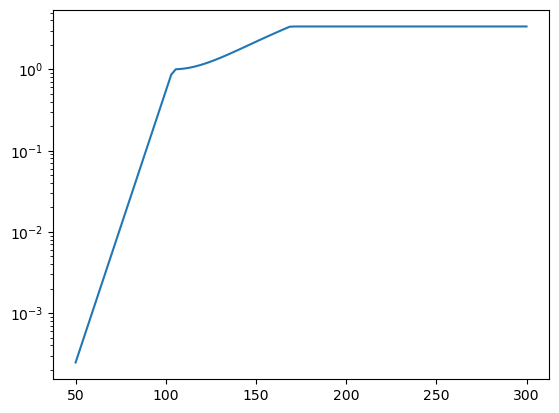

In [126]:
def power(sat_power,gl=6.5,und_len=105,sat_gl=16):
    exp_len=np.min([und_len/gl,sat_gl])
    post_sat_len=np.max([und_len/gl-sat_gl,0])
    post_sat_len=np.min([post_sat_len,10])
    exp_power=sat_power*np.exp(exp_len-sat_gl)
    sat_power=exp_power*(1+(post_sat_len/gl)**2)
    return sat_power
ax=plt.gca()
ul=np.linspace(50,300,100);
ax.semilogy(ul,[power(1,und_len=x) for x in ul])

### Scaling to high photon energy

In [2]:
def mx_power(phEnergy,emittance,gamma0,uLen=105):
    delgamma=3/0.511
    current=3.4e3
    #emittance=0.27e-6
    plam=1240e-9/phEnergy
    lamU=0.026
    if 2*gamma0**2*plam/lamU-1<0:
        return 0
    Kgen=np.sqrt(2*gamma0**2*plam/lamU-1)
    
    Bp=3.336 #per GeV in [T m], 
    L=4.03
    Bdz=3; #tesla
    f=Bp*(gamma0*0.511/1000)/Bdz
    k=2*f/L
    beta1=L*k*(k+1)/np.sqrt(k**2-1)
    beta2=L*k*(k-1)/np.sqrt(k**2-1)
    sigBeam=(np.sqrt(beta1*emittance/gamma0)+np.sqrt(beta2*emittance/gamma0))/2;
    
    MX=analysis.MingXie(Kgen,2*np.pi/lamU,gamma0,delgamma/gamma0,current,sigBeam,emittance,plam,0)
    #print(MX)
    Lg=MX['Lg']
    return power(MX['Psat'],gl=Lg,und_len=105,sat_gl=16)
mx_power(18e3,0.5e-6,14.5e3/0.511)*1e-9

NameError: name 'power' is not defined

In [83]:
mx_power(10e3,0.5e-6,8e3/0.511)*1e-9

3.352044257093609

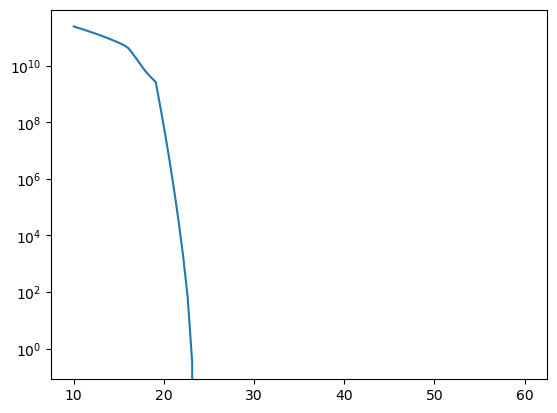

In [128]:
ax=plt.gca()
emis=np.arange(0.1,0.7,0.1)*1e-6
gamma0s=np.arange(8000,28000,4000)/0.511
phEs=np.linspace(10,60,100);
est_powers=np.zeros((len(emis),len(gamma0s),len(phEs)))
for ii,emi in enumerate(emis):
    for jj,gamma0 in enumerate(gamma0s):
        for kk, phE in enumerate(phEs):
            est_powers[ii,jj,kk]= mx_power(phE*1e3,emi,gamma0)
ax.semilogy(phEs,est_powers[0,0,:])
plt.show()

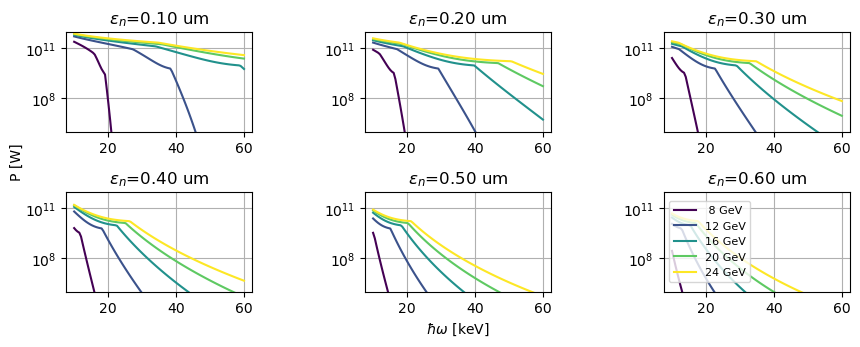

In [153]:
fig = plt.figure(num=1,figsize=[3.375*3,3.375*1])
fig.clf()
nplots=len(emis)
nrows=2
ncols=int(np.ceil(nplots/nrows))
outer_grid=fig.add_gridspec(nrows,ncols,wspace=0.6,hspace=0.6)


ax_bottom = fig.add_subplot(outer_grid[-1, :])
[ax_bottom.spines[x].set_visible(False) for x in ['top','bottom','left','right']]
ax_bottom.set_xticks([])  # Remove x-ticks
ax_bottom.set_yticks([])  # Remove y-ticks
ax_bottom.set_xlabel("$\hbar\omega$ [keV]",labelpad=21)
ax_left = fig.add_subplot(outer_grid[:, 0])
[ax_left.spines[x].set_visible(False) for x in ['top','bottom','left','right']]
ax_left.set_xticks([])  # Remove x-ticks
ax_left.set_yticks([])  # Remove y-ticks
ax_left.set_ylabel("P [W]",labelpad=30)

for ii,emi in enumerate(emis):
    ax=fig.add_subplot(outer_grid[ii])
    ax.set_title('$\epsilon_n$={:0.2f} um'.format(emi*1e6))
    ax.set_ylim([1e6,1e12])
    ax.grid()
    for jj,gamma0 in enumerate(gamma0s):
        color=cm.viridis((gamma0-np.min(gamma0s))/np.ptp(gamma0s))
        ax.semilogy(phEs,est_powers[ii,jj,:],color=color,label='{:2.0f} GeV'.format(gamma0*0.511/1000))
        
    if ii==len(emis)-1:
        plt.legend(fontsize=8,loc=6)
        


plt.show()

# Rough calculator for LCLS-II SXR (and extend to HE unds at 2.5 GeV)

max 3.147882410347909


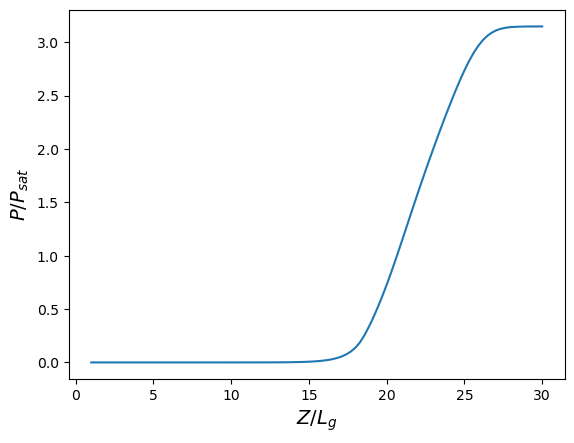

In [3]:
from scipy.special import erf

@np.vectorize
def power(sat_power,gl=6.5,und_len=105,sat_gl=20,postamp=3):
    satz=sat_gl*gl
    z=und_len
    psatlen=6*gl;
    transfer_rate=gl*1.5
    quadrate=sat_power/(9*gl);


    if z<(satz-transfer_rate):
        expz=z
    else:
        dz=z-(satz-transfer_rate)
        expz=(satz-transfer_rate)+(transfer_rate)*(1-np.exp(-dz/transfer_rate))
        
    #transfer=(erf((z-satz)/transfer_rate)-erf((z-satz-6*gl)/transfer_rate))/2
    #lins=(transfer)*(z-satz)*linrate
    #quad=(transfer)*(z-satz)**2*quadrate
    za=(z-satz)/transfer_rate
    zb=(z-satz-psatlen)/transfer_rate
    lins=(0.5*psatlen+((0.5*transfer_rate/np.sqrt(np.pi))*(np.exp(-za**2)-np.exp(-zb**2))+0.5*transfer_rate*((za*erf(za)+zb*erf(-zb)))))/2/np.pi
    
    #postsatfac=lins+quad*0
    
    exp=sat_power*np.exp(expz/gl)*np.exp(-sat_gl)

    return (exp+lins*postamp*sat_power)
ax=plt.gca()
ul=np.linspace(1,30,100);
ys=[power(1,und_len=x,gl=1.0,postamp=2.25) for x in ul]
print('max',max(ys))
ax.plot(ul,ys)
ax.set_xlabel('$Z/L_g$',fontsize=14)
ax.set_ylabel('$P/P_{sat}$',fontsize=14)
plt.show()

from scipy.special import jv

jj=(jv(0,Kgen**2/2/(1+Kgen**2))-jv(1,Kgen**2/2/(1+Kgen**2)))

Lg2=1.2*np.sqrt(17.045e3/current)*(emittance**5*lamU**5/plam**4)**(1/6)*(1+Kgen**2)**(1/3)/(Kgen*np.sqrt(2)*jj)
    Lg2=Lg2*(1+131*17.045e3*current*(emittance**10*lamU**9*plam**1)**(1/8)*delgamma**2*(Kgen*jj)**2*2*(1+Kgen**2)**(1/8))
    
Lg2 from saldin, only applies when lamr<10*pi*epsilon_geo.

https://www.sciencedirect.com/science/article/pii/S0030401804002202

In [4]:
from scipy.special import jv

/sdf/group/ad/beamphysics/dcesar/miniforge3/lib/python3.10/site-packages/genesis/analysis.py:129: RuntimeWarning: divide by zero encountered in scalar divide
  Lg1d=1/2/ku/rho/np.sqrt(3)
/sdf/group/ad/beamphysics/dcesar/miniforge3/lib/python3.10/site-packages/genesis/analysis.py:146: RuntimeWarning: invalid value encountered in scalar divide
  Psat=1.6*rho*(Lg1d/Lg)**2*Pbeam
/sdf/group/ad/beamphysics/dcesar/miniforge3/lib/python3.10/site-packages/genesis/analysis.py:129: RuntimeWarning: divide by zero encountered in divide
  Lg1d=1/2/ku/rho/np.sqrt(3)
/sdf/group/ad/beamphysics/dcesar/miniforge3/lib/python3.10/site-packages/genesis/analysis.py:146: RuntimeWarning: invalid value encountered in divide
  Psat=1.6*rho*(Lg1d/Lg)**2*Pbeam
/lscratch/dcesar/tmp/ipykernel_1075518/2213072693.py:12: RuntimeWarning: invalid value encountered in scalar subtract
  if z<(satz-transfer_rate):
/lscratch/dcesar/tmp/ipykernel_1075518/2213072693.py:15: RuntimeWarning: invalid value encountered in scalar su

array(0.00371747)

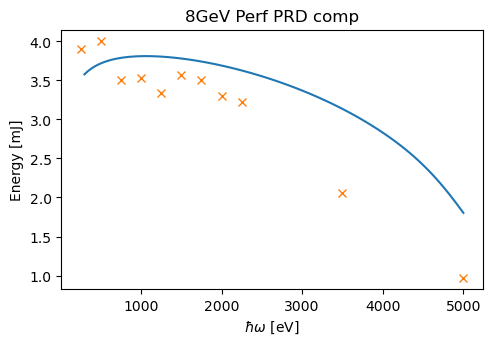

In [5]:
fig = plt.figure(num=1,figsize=[3.375*1.61,3.375])
fig.clf()
ax=plt.subplot(1,1,1)


def int_MX(ts,cur,mxp):
    MX=analysis.MingXie(mxp[0],mxp[1],mxp[2],mxp[3],cur,mxp[5],mxp[6],mxp[7],mxp[8])
    Lgs=MX['Lg']
    psats=MX['Psat']
    return np.trapz(power(psats,gl=Lgs,und_len=3.4*30,sat_gl=21,postamp=2.25),ts)


@np.vectorize
def power_estimate(beamEnergy,phEnergy):
    gamma0=beamEnergy/0.511
    delgamma=1.15/0.511
    current=1.35e3
    emittance=0.27*1e-6
    plam=1240e-9/phEnergy
    lamU=0.056
    if (2*gamma0**2*plam/lamU-1) <=0:
        return 0
    Kgen=np.sqrt(2*gamma0**2*plam/lamU-1)
    if Kgen>9.21/np.sqrt(2):
        Kgen=0
    #if Kgen <0.75/np.sqrt(2):
    #    Kgen=0
    Bdz=4; #tesla
    L=4.4;
    Bp=3.336 #per GeV in [T m];
    f=Bp*(gamma0*0.511/1000)/Bdz
    k=2*f/L
    beta1=L*k*(k+1)/np.sqrt(k**2-1)
    beta2=L*k*(k-1)/np.sqrt(k**2-1)
    sigBeam=np.sqrt(np.sqrt(beta1*beta2)*emittance/gamma0)
    MX=analysis.MingXie(Kgen,2*np.pi/lamU,gamma0,delgamma/gamma0,current,sigBeam,emittance,plam,0)
    Lg=MX['Lg']
    #return power(MX['Psat'],gl=Lg,und_len=3.4*30,sat_gl=21,postamp=2.75)

    ts=np.linspace(-100,100,500);
    cur=current*np.exp(-0.5*(ts/20)**2)
    return int_MX(ts*1e-15,cur,[Kgen,2*np.pi/lamU,gamma0,delgamma/gamma0,current,sigBeam,emittance,plam,0])
    
ph_ens=np.linspace(250,5000,100);
P=power_estimate(8000*np.ones(ph_ens.shape[0]),ph_ens);
ax=plt.gca()
ax.plot(ph_ens,P*1e3)#*50e-15

pcalc=[250,500,750,1000,1250,1500,1750,2000,2250,3500,5000]
pvals=[585,600,525,530,500,535,525,495,483,308,146]
pvals=np.array(pvals)/150e3*1e3;

ax.plot(pcalc,pvals,'x')
ax.set_xlabel('$\hbar \omega$ [eV]')
ax.set_ylabel('Energy [mJ]')
ax.set_title('8GeV Perf PRD comp')
power_estimate(8000,500)

Text(0.5, 1.0, '8GeV Perf PRD comp')

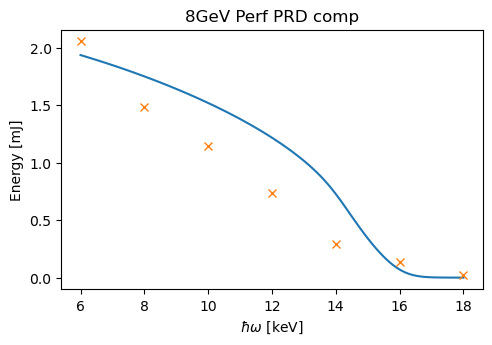

In [6]:
fig = plt.figure(num=1,figsize=[3.375*1.61,3.375])
fig.clf()
ax=plt.subplot(1,1,1)

def int_MX(ts,cur,mxp):
    MX=analysis.MingXie(mxp[0],mxp[1],mxp[2],mxp[3],cur,mxp[5],mxp[6],mxp[7],mxp[8])
    Lgs=MX['Lg']
    psats=MX['Psat']
    return np.trapz(power(psats,gl=Lgs,und_len=3.38*32,sat_gl=21,postamp=2.25),ts)


@np.vectorize
def power_estimate(beamEnergy,phEnergy):
    gamma0=beamEnergy/0.511
    delgamma=1.12/0.511
    current=1.35e3
    emittance=0.26*1e-6
    plam=1240e-9/phEnergy
    lamU=0.026
    if (2*gamma0**2*plam/lamU-1) <=0:
        return 0
    Kgen=np.sqrt(2*gamma0**2*plam/lamU-1)
    if Kgen>2.44/np.sqrt(2):
        Kgen=0
    #if Kgen <0.75/np.sqrt(2):
    #    Kgen=0
    Bdz=4; #tesla
    L=4.01;
    Bp=3.336 #per GeV in [T m];
    f=Bp*(gamma0*0.511/1000)/Bdz
    k=2*f/L
    beta1=L*k*(k+1)/np.sqrt(k**2-1)
    beta2=L*k*(k-1)/np.sqrt(k**2-1)
    sigBeam=np.sqrt(np.sqrt(beta1*beta2)*emittance/gamma0)
    MX=analysis.MingXie(Kgen,2*np.pi/lamU,gamma0,delgamma/gamma0,current,sigBeam,emittance,plam,0)
    Lg=MX['Lg']
    #return power(MX['Psat'],gl=Lg,und_len=3.38*32,sat_gl=21,postamp=2.75)
    ts=np.linspace(-100,100,500);
    cur=current*np.exp(-0.5*(ts/20)**2)
    return int_MX(ts*1e-15,cur,[Kgen,2*np.pi/lamU,gamma0,delgamma/gamma0,current,sigBeam,emittance,plam,0])
    
ph_ens=np.linspace(6000,18000,100);
P=power_estimate(8000*np.ones(ph_ens.shape[0]),ph_ens);
ax=plt.gca()
ax.plot(ph_ens/1e3,P*1e3)#*50e-15

pcalc=np.array([6,8,10,12,14,16,18])
pvals=[308,222,172,110,44,20,3]
pvals=np.array(pvals)/150e3*1e3;

ax.plot(pcalc,pvals,'x')
#ax.set_yscale('log')
#ax.set_ylim([1e-2,2])
ax.set_xlabel('$\hbar \omega$ [keV]')
ax.set_ylabel('Energy [mJ]')
ax.set_title('8GeV Perf PRD comp')

In [56]:
gamma0=4000/0.511
delgamma=1.15/0.511
current=1.35e3
emittance=0.27*1e-6
plam=1240e-9/400
lamU=0.056
Kgen=np.sqrt(2*gamma0**2*plam/lamU-1)

#if Kgen <0.75/np.sqrt(2):
#    Kgen=0
Bdz=4; #tesla
L=4.4;
Bp=3.336 #per GeV in [T m];
f=Bp*(gamma0*0.511/1000)/Bdz
k=2*f/L
beta1=L*k*(k+1)/np.sqrt(k**2-1)
beta2=L*k*(k-1)/np.sqrt(k**2-1)
sigBeam=np.sqrt(np.sqrt(beta1*beta2)*emittance/gamma0)
MX=analysis.MingXie(Kgen,2*np.pi/lamU,gamma0,delgamma/gamma0,current,sigBeam,emittance,plam,0)
MX

{'rho': 0.0028429892350866418,
 'Lg': 1.3268567417333503,
 'Lg1d': 0.9049869577000422,
 'Pbeam': 5399999999999.999,
 'Pnoise': 500.5989857539217,
 'Psat': 11426823719.978085}

/lscratch/dcesar/tmp/ipykernel_2226334/2213072693.py:12: RuntimeWarning: invalid value encountered in scalar subtract
  if z<(satz-transfer_rate):
/lscratch/dcesar/tmp/ipykernel_2226334/2213072693.py:15: RuntimeWarning: invalid value encountered in scalar subtract
  dz=z-(satz-transfer_rate)
/lscratch/dcesar/tmp/ipykernel_2226334/2213072693.py:16: RuntimeWarning: invalid value encountered in scalar subtract
  expz=(satz-transfer_rate)+(transfer_rate)*(1-np.exp(-dz/transfer_rate))
/lscratch/dcesar/tmp/ipykernel_2226334/2213072693.py:21: RuntimeWarning: invalid value encountered in scalar divide
  za=(z-satz)/transfer_rate
/lscratch/dcesar/tmp/ipykernel_2226334/2213072693.py:22: RuntimeWarning: invalid value encountered in scalar divide
  zb=(z-satz-psatlen)/transfer_rate


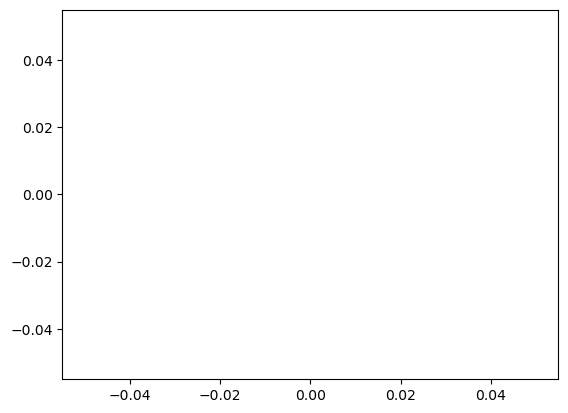

In [57]:
ph_ens=np.linspace(250,5000,100);
P=power_estimate(8000*np.ones(ph_ens.shape[0]),ph_ens);
ax=plt.gca()
ax.plot(ph_ens,P*50e-15*1e3)#

pcalc=[250,500,750,1000,1250,1500,1750,2000,2250,3500,5000]
pvals=[585,600,525,530,500,535,525,495,483,308,146]
pvals=np.array(pvals)/150e3*1e3;

/lscratch/dcesar/tmp/ipykernel_2768096/2213072693.py:12: RuntimeWarning: invalid value encountered in scalar subtract
  if z<(satz-transfer_rate):
/lscratch/dcesar/tmp/ipykernel_2768096/2213072693.py:15: RuntimeWarning: invalid value encountered in scalar subtract
  dz=z-(satz-transfer_rate)
/lscratch/dcesar/tmp/ipykernel_2768096/2213072693.py:16: RuntimeWarning: invalid value encountered in scalar subtract
  expz=(satz-transfer_rate)+(transfer_rate)*(1-np.exp(-dz/transfer_rate))
/lscratch/dcesar/tmp/ipykernel_2768096/2213072693.py:21: RuntimeWarning: invalid value encountered in scalar divide
  za=(z-satz)/transfer_rate
/lscratch/dcesar/tmp/ipykernel_2768096/2213072693.py:22: RuntimeWarning: invalid value encountered in scalar divide
  zb=(z-satz-psatlen)/transfer_rate


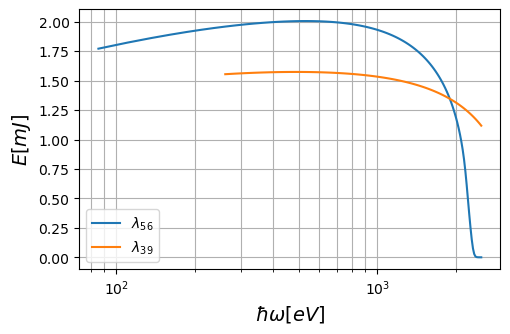

In [8]:
fig = plt.figure(num=1,figsize=[3.375*1.61,3.375])
fig.clf()
ax=plt.subplot(1,1,1)

def int_MX(ts,cur,mxp):
    MX=analysis.MingXie(mxp[0],mxp[1],mxp[2],mxp[3],cur,mxp[5],mxp[6],mxp[7],mxp[8])
    Lgs=MX['Lg']
    psats=MX['Psat']
    return np.trapz(power(psats,gl=Lgs,und_len=3.4*30,sat_gl=21,postamp=2.25),ts)

@np.vectorize
def power_estimate(beamEnergy,phEnergy):
    gamma0=beamEnergy/0.511
    delgamma=1.15/0.511
    current=1.35e3
    emittance=0.27*1e-6
    plam=1240e-9/phEnergy
    lamU=0.056
    if (2*gamma0**2*plam/lamU-1) <=0:
        return 0
    Kgen=np.sqrt(2*gamma0**2*plam/lamU-1)
    if Kgen>9.21/np.sqrt(2):
        Kgen=0
    #if Kgen <0.75/np.sqrt(2):
    #    Kgen=0
    Bdz=4; #tesla
    L=4.4;
    Bp=3.336 #per GeV in [T m];
    f=Bp*(gamma0*0.511/1000)/Bdz
    k=2*f/L
    beta1=L*k*(k+1)/np.sqrt(k**2-1)
    beta2=L*k*(k-1)/np.sqrt(k**2-1)
    sigBeam=np.sqrt(np.sqrt(beta1*beta2)*emittance/gamma0)
    ts=np.linspace(-100,100,500);
    cur=current*np.exp(-0.5*(ts/20)**2)
    return int_MX(ts*1e-15,cur,[Kgen,2*np.pi/lamU,gamma0,delgamma/gamma0,current,sigBeam,emittance,plam,0])

@np.vectorize
def power_estimate2(beamEnergy,phEnergy):
    gamma0=beamEnergy/0.511
    delgamma=1.1/0.511
    current=1.35e3
    emittance=0.27*1e-6
    plam=1240e-9/phEnergy
    lamU=0.039
    Kgen=np.sqrt(2*gamma0**2*plam/lamU-1)
    if Kgen>5.44/np.sqrt(2):
        Kgen=0
    #if Kgen <0.75/np.sqrt(2):
    #    Kgen=0
    Bdz=4; #tesla
    L=4.4;
    Bp=3.336 #per GeV in [T m];
    f=Bp*(gamma0*0.511/1000)/Bdz
    k=2*f/L
    beta1=L*k*(k+1)/np.sqrt(k**2-1)
    beta2=L*k*(k-1)/np.sqrt(k**2-1)
    sigBeam=np.sqrt(np.sqrt(beta1*beta2)*emittance/gamma0)
    ts=np.linspace(-100,100,500);
    cur=current*np.exp(-0.5*(ts/20)**2)
    return int_MX(ts*1e-15,cur,[Kgen,2*np.pi/lamU,gamma0,delgamma/gamma0,current,sigBeam,emittance,plam,0])
    
ph_ens=np.linspace(10,2500,100);
P=power_estimate(4000*np.ones(ph_ens.shape[0]),ph_ens);
P2=power_estimate2(4000*np.ones(ph_ens.shape[0]),ph_ens);
ax=plt.gca()
ax.semilogx(ph_ens,P*1e3,label=r'$\lambda_{56}$')#
ax.semilogx(ph_ens,P2*1e3,label=r'$\lambda_{39}$')#
plt.legend()
ax.set_xlabel('$\hbar\omega [eV]$',fontsize=14)
ax.set_ylabel('$E [mJ]$',fontsize=14)
ax.grid(which='both')
plt.show()

/lscratch/dcesar/tmp/ipykernel_2768096/2213072693.py:12: RuntimeWarning: invalid value encountered in scalar subtract
  if z<(satz-transfer_rate):
/lscratch/dcesar/tmp/ipykernel_2768096/2213072693.py:15: RuntimeWarning: invalid value encountered in scalar subtract
  dz=z-(satz-transfer_rate)
/lscratch/dcesar/tmp/ipykernel_2768096/2213072693.py:16: RuntimeWarning: invalid value encountered in scalar subtract
  expz=(satz-transfer_rate)+(transfer_rate)*(1-np.exp(-dz/transfer_rate))
/lscratch/dcesar/tmp/ipykernel_2768096/2213072693.py:21: RuntimeWarning: invalid value encountered in scalar divide
  za=(z-satz)/transfer_rate
/lscratch/dcesar/tmp/ipykernel_2768096/2213072693.py:22: RuntimeWarning: invalid value encountered in scalar divide
  zb=(z-satz-psatlen)/transfer_rate


Text(0.5, 1.0, 'LCLS-II w/ 30 56 mm undulators')

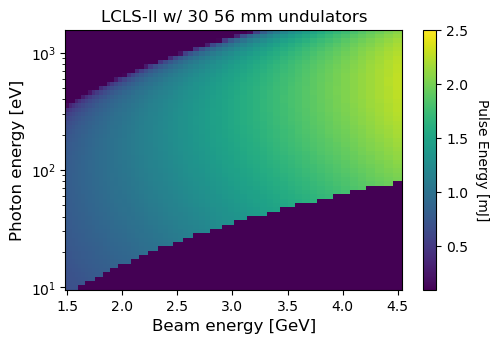

In [9]:
fig = plt.figure(num=1,figsize=[3.375*1.61,3.375])
fig.clf()
ax=plt.subplot(1,1,1)

def int_MX(ts,cur,mxp):
    MX=analysis.MingXie(mxp[0],mxp[1],mxp[2],mxp[3],cur,mxp[5],mxp[6],mxp[7],mxp[8])
    Lgs=MX['Lg']
    psats=MX['Psat']
    return np.trapz(power(psats,gl=Lgs,und_len=3.4*30,sat_gl=21,postamp=2.25),ts)

def power_estimate56(beamEnergy,phEnergy):
    gamma0=beamEnergy/0.511
    delgamma=1.15/0.511
    current=1.35e3
    emittance=0.27*1e-6
    plam=1240e-9/phEnergy
    lamU=0.056
    if (2*gamma0**2*plam/lamU-1) <=0:
        return 0
    Kgen=np.sqrt(2*gamma0**2*plam/lamU-1)
    if Kgen>9.21/np.sqrt(2):
        Kgen=0
    L=4.4;
    Bp=3.336 #per GeV in [T m];
    Bdz=np.min([3,Bp*(gamma0*0.511/1000)*2/L-0.1]);
    f=Bp*(gamma0*0.511/1000)/Bdz
    k=2*f/L
    if (k**2-1)<=0:
        return 0
    beta1=L*k*(k+1)/np.sqrt(k**2-1)
    beta2=L*k*(k-1)/np.sqrt(k**2-1)
    sigBeam=np.sqrt(np.sqrt(beta1*beta2)*emittance/gamma0)
    ts=np.linspace(-100,100,500);
    cur=current*np.exp(-0.5*(ts/20)**2)
    p=int_MX(ts*1e-15,cur,[Kgen,2*np.pi/lamU,gamma0,delgamma/gamma0,current,sigBeam,emittance,plam,0])
    if np.isnan(p):
        return 0
    return p
    

ax=plt.gca()
ph_ens=np.logspace(np.log10(10),np.log10(1500),60)
beam_ens=np.logspace(np.log10(1500),np.log10(4500),60);
[B,P]=np.meshgrid(beam_ens,ph_ens,indexing='ij')
En = np.empty(B.shape)
for i in range(B.shape[0]):
    for j in range(B.shape[1]):
        En[i, j] = power_estimate56(B[i, j], P[i, j]) * 1e3
p=ax.pcolormesh(B/1000,P,En,vmin=0.1,vmax=2.5)
cbar=plt.colorbar(p)
cbar.set_label('Pulse Energy [mJ]', rotation=270, labelpad=15)
ax.set_yscale('log')
#ax.set_xscale('log')
ax.set_xlabel('Beam energy [GeV]',fontsize=12)
ax.set_ylabel('Photon energy [eV]',fontsize=12)
ax.set_title('LCLS-II w/ 30 56 mm undulators')

/lscratch/dcesar/tmp/ipykernel_2768096/1163867987.py:12: RuntimeWarning: invalid value encountered in sqrt
  Kgen=np.sqrt(2*gamma0**2*plam/lamU-1)


Text(0.5, 1.0, 'LCLS-II w/ 21 39 mm undulators')

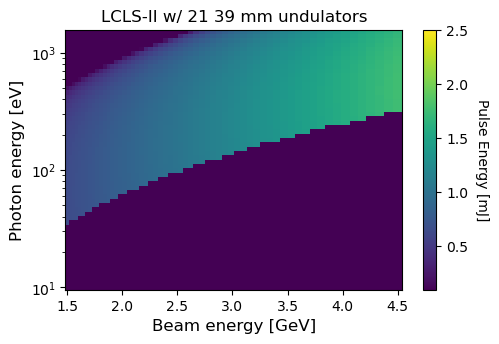

In [10]:
fig = plt.figure(num=1,figsize=[3.375*1.61,3.375])
fig.clf()
ax=plt.subplot(1,1,1)

def power_estimate39(beamEnergy,phEnergy):
    gamma0=beamEnergy/0.511
    delgamma=1.1/0.511
    current=1.35e3
    emittance=0.27*1e-6
    plam=1240e-9/phEnergy
    lamU=0.039
    Kgen=np.sqrt(2*gamma0**2*plam/lamU-1)
    if Kgen>5.44/np.sqrt(2):
        return 0
    if Kgen <0.25/np.sqrt(2):
        return 0
    
    L=4.4;
    Bp=3.336 #per GeV in [T m];
    Bdz=np.min([3,Bp*(gamma0*0.511/1000)*2/L-0.1]);
    f=Bp*(gamma0*0.511/1000)/Bdz
    k=2*f/L
    if (k**2-1)<=0:
        return 0
    beta1=L*k*(k+1)/np.sqrt(k**2-1)
    beta2=L*k*(k-1)/np.sqrt(k**2-1)
    sigBeam=np.sqrt(np.sqrt(beta1*beta2)*emittance/gamma0)
    ts=np.linspace(-100,100,500);
    cur=current*np.exp(-0.5*(ts/20)**2)
    p=int_MX(ts*1e-15,cur,[Kgen,2*np.pi/lamU,gamma0,delgamma/gamma0,current,sigBeam,emittance,plam,0])
    if np.isnan(p):
        return 0
    return p
    

ax=plt.gca()
ph_ens=np.logspace(np.log10(10),np.log10(1500),60)
beam_ens=np.logspace(np.log10(1500),np.log10(4500),60);
[B,P]=np.meshgrid(beam_ens,ph_ens,indexing='ij')
En = np.empty(B.shape)
for i in range(B.shape[0]):
    for j in range(B.shape[1]):
        En[i, j] = power_estimate39(B[i, j], P[i, j]) * 1e3
p=ax.pcolormesh(B/1000,P,En,vmin=0.1,vmax=2.5)
cbar=plt.colorbar(p)
cbar.set_label('Pulse Energy [mJ]', rotation=270, labelpad=15)
ax.set_yscale('log')
#ax.set_xscale('log')
ax.set_xlabel('Beam energy [GeV]',fontsize=12)
ax.set_ylabel('Photon energy [eV]',fontsize=12)
ax.set_title('LCLS-II w/ 21 39 mm undulators')

/lscratch/dcesar/tmp/ipykernel_2768096/3757377678.py:34: RuntimeWarning: invalid value encountered in sqrt
  Kgen=np.sqrt(2*gamma0**2*plam/lamU-1)
/lscratch/dcesar/tmp/ipykernel_2768096/3757377678.py:51: RuntimeWarning: invalid value encountered in sqrt
  Kgen2=np.sqrt(2*gamma0**2*plam/lamU2-1)


Text(0.5, 1.0, 'LCLS-II w/9 56mm + 21 39 mm undulators')

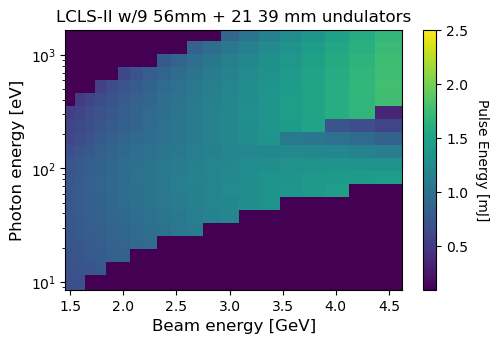

In [11]:
fig = plt.figure(num=1,figsize=[3.375*1.61,3.375])
fig.clf()
ax=plt.subplot(1,1,1)

def int_mixed_MX(ts,cur,mxp1,mxp2,stage1only=False):
    mxp=mxp1
    MX1=analysis.MingXie(mxp[0],mxp[1],mxp[2],mxp[3],cur,mxp[5],mxp[6],mxp[7],mxp[8])
    Lgs1=MX1['Lg']
    psats1=MX1['Psat']

    p1=np.trapz(power(psats1,gl=Lgs1,und_len=3.4*9,sat_gl=21,postamp=2.25),ts)
    if stage1only:
        return p1

    mxp=mxp2
    MX2=analysis.MingXie(mxp[0],mxp[1],mxp[2],mxp[3],cur,mxp[5],mxp[6],mxp[7],mxp[8])
    Lgs2=MX2['Lg']
    psats2=MX2['Psat']

    # Ok. If stage 1 is only in exp regime, then we need only add a coresponding number of undulators
    lens=(3.4*9)/Lgs1*Lgs2 
    p=np.trapz(power(psats2,gl=Lgs2,und_len=3.4*30+lens,sat_gl=21,postamp=2.25),ts)
    # return max of p and single stage
    return max([p,p1])


def mixed_power_estimate(beamEnergy,phEnergy):
    gamma0=beamEnergy/0.511
    delgamma=1.1/0.511
    current=1.35e3
    emittance=0.27*1e-6
    plam=1240e-9/phEnergy
    lamU=0.056
    Kgen=np.sqrt(2*gamma0**2*plam/lamU-1)
    if Kgen>9.21/np.sqrt(2):
        return 0
    L=4.4;
    Bp=3.336 #per GeV in [T m];
    Bdz=np.min([3,Bp*(gamma0*0.511/1000)*2/L-0.1]);
    f=Bp*(gamma0*0.511/1000)/Bdz
    k=2*f/L
    if (k**2-1)<=0:
        return 0
    beta1=L*k*(k+1)/np.sqrt(k**2-1)
    beta2=L*k*(k-1)/np.sqrt(k**2-1)
    sigBeam=np.sqrt(np.sqrt(beta1*beta2)*emittance/gamma0)
    ts=np.linspace(-100,100,500);
    cur=current*np.exp(-0.5*(ts/20)**2)

    lamU2=0.039
    Kgen2=np.sqrt(2*gamma0**2*plam/lamU2-1)
    if Kgen2>5.44/np.sqrt(2):
        p=int_mixed_MX(ts*1e-15,cur,[Kgen,2*np.pi/lamU,gamma0,delgamma/gamma0,current,sigBeam,emittance,plam,0],[Kgen2,2*np.pi/lamU2,gamma0,delgamma/gamma0,current,sigBeam,emittance,plam,0],stage1only=True)
    else:
        p=int_mixed_MX(ts*1e-15,cur,[Kgen,2*np.pi/lamU,gamma0,delgamma/gamma0,current,sigBeam,emittance,plam,0],[Kgen2,2*np.pi/lamU2,gamma0,delgamma/gamma0,current,sigBeam,emittance,plam,0])

    if np.isnan(p):
        return 0
    return p
    

ax=plt.gca()
ph_ens=np.logspace(np.log10(10),np.log10(1500),20)
beam_ens=np.logspace(np.log10(1500),np.log10(4500),20);
[B,P]=np.meshgrid(beam_ens,ph_ens,indexing='ij')
En = np.empty(B.shape)
for i in range(B.shape[0]):
    for j in range(B.shape[1]):
        En[i, j] = mixed_power_estimate(B[i, j], P[i, j]) * 1e3
p=ax.pcolormesh(B/1000,P,En,vmin=0.1,vmax=2.5)
cbar=plt.colorbar(p)
cbar.set_label('Pulse Energy [mJ]', rotation=270, labelpad=15)
ax.set_yscale('log')
#ax.set_xscale('log')
ax.set_xlabel('Beam energy [GeV]',fontsize=12)
ax.set_ylabel('Photon energy [eV]',fontsize=12)
ax.set_title('LCLS-II w/9 56mm + 21 39 mm undulators')

/lscratch/dcesar/tmp/ipykernel_3136133/3757377678.py:34: RuntimeWarning: invalid value encountered in sqrt
  Kgen=np.sqrt(2*gamma0**2*plam/lamU-1)
/lscratch/dcesar/tmp/ipykernel_3136133/3757377678.py:51: RuntimeWarning: invalid value encountered in sqrt
  Kgen2=np.sqrt(2*gamma0**2*plam/lamU2-1)


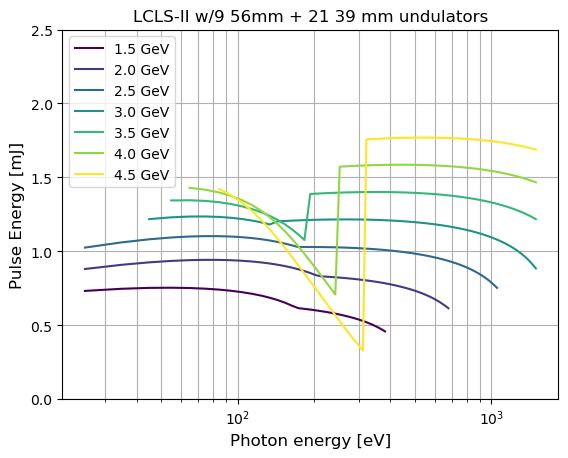

In [21]:
ax=plt.gca()

ph_ens=np.linspace(25,1500,150)
beam_ens=np.arange(1500,5000,500)#np.logspace(np.log10(1500),np.log10(4500),5);
[B,P]=np.meshgrid(beam_ens,ph_ens,indexing='ij')
En = np.empty(B.shape)
for i in range(B.shape[0]):
    for j in range(B.shape[1]):
        En[i, j] = mixed_power_estimate(B[i, j], P[i, j]) * 1e3
        
for ii in range(B.shape[0]):
    mask=En[ii,:]!=0;
    p=ax.plot(ph_ens[mask],(En[ii,mask]),color=cm.viridis((beam_ens[ii]-1500)/3000),label='{:2.1f} GeV'.format(beam_ens[ii]/1000))

#sm = plt.cm.ScalarMappable(cmap=cm.viridis, norm=cm.viridis.N)
#sm.set_array([])  # Only needed for the colorbar
#cbar = fig.colorbar(sm, ax=ax, boundaries=levels, ticks=levels, spacing='proportional')
#cbar.set_label('Beam Energy Bands')

#ax.set_yscale('log')
ax.set_xscale('log')
ax.set_ylabel('Pulse Energy [mJ]',fontsize=12)
ax.set_xlabel('Photon energy [eV]',fontsize=12)
ax.set_title('LCLS-II w/9 56mm + 21 39 mm undulators')
ax.grid(which='both')
ax.set_ylim([0,2.5])
plt.legend()

plt.show()

/lscratch/dcesar/tmp/ipykernel_3587069/2523138021.py:19: RuntimeWarning: invalid value encountered in sqrt
  Kgen=np.sqrt(2*gamma0**2*plam/lamU-1)
/lscratch/dcesar/tmp/ipykernel_3587069/2523138021.py:88: RuntimeWarning: invalid value encountered in sqrt
  Kgen=np.sqrt(2*gamma0**2*plam/lamU-1)


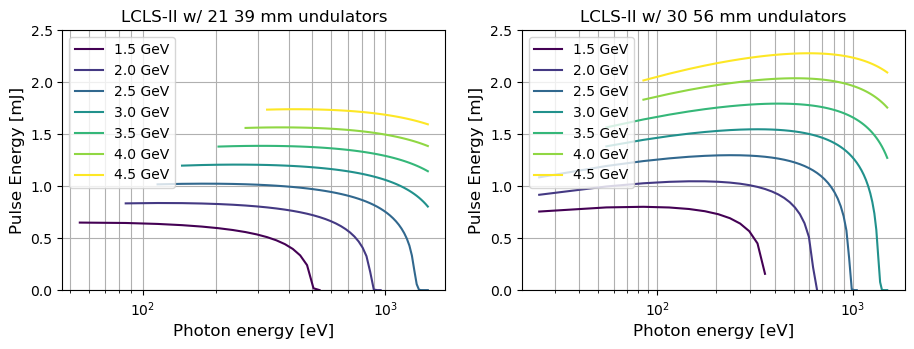

In [653]:
fig = plt.figure(num=1,figsize=[3.375*1.61*2,3.375])
fig.clf()
ax=plt.subplot(1,2,1)

def int_MX(ts,cur,mxp):
    MX=analysis.MingXie(mxp[0],mxp[1],mxp[2],mxp[3],cur,mxp[5],mxp[6],mxp[7],mxp[8])
    Lgs=MX['Lg']
    psats=MX['Psat']
    return np.trapz(power(psats,gl=Lgs,und_len=3.4*21,sat_gl=21,postamp=2.25),ts)

@np.vectorize
def div_estimate(beamEnergy,phEnergy):
    gamma0=beamEnergy/0.511
    delgamma=1.1/0.511
    current=1.35e3
    emittance=0.27*1e-6
    plam=1240e-9/phEnergy
    lamU=0.039
    Kgen=np.sqrt(2*gamma0**2*plam/lamU-1)
    if Kgen>5.44/np.sqrt(2):
        return 0
    
    L=4.4;
    Bp=3.336 #per GeV in [T m];
    Bdz=np.min([3,Bp*(gamma0*0.511/1000)*2/L-0.1]);
    f=Bp*(gamma0*0.511/1000)/Bdz
    k=2*f/L
    if (k**2-1)<=0:
        return 0
    beta1=L*k*(k+1)/np.sqrt(k**2-1)
    beta2=L*k*(k-1)/np.sqrt(k**2-1)
    sigBeam=np.sqrt(np.sqrt(beta1*beta2)*emittance/gamma0)
    ts=np.linspace(-100,100,500);
    cur=current*np.exp(-0.5*(ts/20)**2)

    p=int_MX(ts*1e-15,cur,[Kgen,2*np.pi/lamU,gamma0,delgamma/gamma0,current,sigBeam,emittance,plam,0])
    if np.isnan(p):
        p=0
    return p
    

ax=plt.gca()
ph_ens=np.linspace(25,1500,50)
beam_ens=np.arange(1500,5000,500)#np.logspace(np.log10(1500),np.log10(4500),5);
[B,P]=np.meshgrid(beam_ens,ph_ens,indexing='ij')
En = np.empty(B.shape)
for i in range(B.shape[0]):
    for j in range(B.shape[1]):
        En[i, j] = div_estimate(B[i, j], P[i, j]) * 1e3
for ii in range(B.shape[0]):
    mask=En[ii,:]!=0;
    p=ax.plot(ph_ens[mask],(En[ii,mask]),color=cm.viridis((beam_ens[ii]-1500)/3000),label='{:2.1f} GeV'.format(beam_ens[ii]/1000))

#sm = plt.cm.ScalarMappable(cmap=cm.viridis, norm=cm.viridis.N)
#sm.set_array([])  # Only needed for the colorbar
#cbar = fig.colorbar(sm, ax=ax, boundaries=levels, ticks=levels, spacing='proportional')
#cbar.set_label('Beam Energy Bands')

#ax.set_yscale('log')
ax.set_xscale('log')
ax.set_ylabel('Pulse Energy [mJ]',fontsize=12)
ax.set_xlabel('Photon energy [eV]',fontsize=12)
ax.set_title('LCLS-II w/ 21 39 mm undulators')
ax.grid(which='both')
ax.set_ylim([0,2.5])
plt.legend()




def int_MX(ts,cur,mxp):
    MX=analysis.MingXie(mxp[0],mxp[1],mxp[2],mxp[3],cur,mxp[5],mxp[6],mxp[7],mxp[8])
    Lgs=MX['Lg']
    psats=MX['Psat']
    return np.trapz(power(psats,gl=Lgs,und_len=3.4*30,sat_gl=21,postamp=2.25),ts)


ax=plt.subplot(1,2,2)

@np.vectorize
def pow_estimate(beamEnergy,phEnergy):
    gamma0=beamEnergy/0.511
    delgamma=1.1/0.511
    current=1.35e3
    emittance=0.27*1e-6
    plam=1240e-9/phEnergy
    lamU=0.056
    Kgen=np.sqrt(2*gamma0**2*plam/lamU-1)
    if Kgen>9.22/np.sqrt(2):
        return 0
    
    L=4.4;
    Bp=3.336 #per GeV in [T m];
    Bdz=np.min([3,Bp*(gamma0*0.511/1000)*2/L-0.1]);
    f=Bp*(gamma0*0.511/1000)/Bdz
    k=2*f/L
    if (k**2-1)<=0:
        return 0
    beta1=L*k*(k+1)/np.sqrt(k**2-1)
    beta2=L*k*(k-1)/np.sqrt(k**2-1)
    sigBeam=np.sqrt(np.sqrt(beta1*beta2)*emittance/gamma0)
    ts=np.linspace(-100,100,500);
    cur=current*np.exp(-0.5*(ts/20)**2)

    p=int_MX(ts*1e-15,cur,[Kgen,2*np.pi/lamU,gamma0,delgamma/gamma0,current,sigBeam,emittance,plam,0])
    if np.isnan(p):
        p=0
    return p
    

ax=plt.gca()
ph_ens=np.linspace(25,1500,50)
beam_ens=np.arange(1500,5000,500)#np.logspace(np.log10(1500),np.log10(4500),5);
[B,P]=np.meshgrid(beam_ens,ph_ens,indexing='ij')
En = np.empty(B.shape)
for i in range(B.shape[0]):
    for j in range(B.shape[1]):
        En[i, j] = pow_estimate(B[i, j], P[i, j]) * 1e3
for ii in range(B.shape[0]):
    mask=En[ii,:]!=0;
    p=ax.plot(ph_ens[mask],(En[ii,mask]),color=cm.viridis((beam_ens[ii]-1500)/3000),label='{:2.1f} GeV'.format(beam_ens[ii]/1000))

#sm = plt.cm.ScalarMappable(cmap=cm.viridis, norm=cm.viridis.N)
#sm.set_array([])  # Only needed for the colorbar
#cbar = fig.colorbar(sm, ax=ax, boundaries=levels, ticks=levels, spacing='proportional')
#cbar.set_label('Beam Energy Bands')

#ax.set_yscale('log')
ax.set_xscale('log')
ax.set_ylabel('Pulse Energy [mJ]',fontsize=12)
ax.set_xlabel('Photon energy [eV]',fontsize=12)
ax.set_title('LCLS-II w/ 30 56 mm undulators')
ax.grid(which='both')
ax.set_ylim([0,2.5])
plt.legend()

plt.show()

## Fitting pulse energy for LCLS-II

In [11]:
def int_mixed_MX(ts,cur,mxp1,mxp2,stage1only=False, postamp=2.75):
    mxp=mxp1
    MX1=analysis.MingXie(mxp[0],mxp[1],mxp[2],mxp[3],cur,mxp[5],mxp[6],mxp[7],mxp[8])
    Lgs1=MX1['Lg']
    psats1=MX1['Psat']

    p1=np.trapz(power(psats1,gl=Lgs1,und_len=3.4*14,sat_gl=21,postamp=postamp),ts)
    if stage1only:
        return p1

    mxp=mxp2
    MX2=analysis.MingXie(mxp[0],mxp[1],mxp[2],mxp[3],cur,mxp[5],mxp[6],mxp[7],mxp[8])
    Lgs2=MX2['Lg']
    psats2=MX2['Psat']

    # Ok. If stage 1 is only in exp regime, then we need only add a coresponding number of undulators
    lens=(3.4*14)/Lgs1*Lgs2 
    p=np.trapz(power(psats2,gl=Lgs2,und_len=3.4*26+lens,sat_gl=21,postamp=postamp),ts)
    # return max of p and single stage
    return max([p,p1])


def mixed_power_estimate(phEnergy,dg,emi,postamp=2.75, i0=1.3e3,sigt=20, verbose=False):
    gamma0=3800/0.511
    delgamma=dg/0.511*i0/1.3e3
    current=i0
    emittance=emi*1e-6
    plam=1240e-9/phEnergy
    lamU=0.056
    Kgen=np.sqrt(2*gamma0**2*plam/lamU-1)
    if Kgen>9.21/np.sqrt(2):
        return 0
    L=4.4;
    Bp=3.336 #per GeV in [T m];
    Bdz=3#np.min([3,Bp*(gamma0*0.511/1000)*2/L-0.1]);
    f=Bp*(gamma0*0.511/1000)/Bdz
    k=2*f/L
    if (k**2-1)<=0:
        return 0
    beta1=L*k*(k+1)/np.sqrt(k**2-1)
    beta2=L*k*(k-1)/np.sqrt(k**2-1)
    sigBeam=np.sqrt(np.sqrt(beta1*beta2)*emittance/gamma0)
    ts=np.linspace(-100,100,500);
    sigt=sigt/i0*1.3e3;
    cur=current*np.exp(-0.5*(ts/sigt)**2)

    lamU2=0.039
    Kgen2=np.sqrt(2*gamma0**2*plam/lamU2-1)
    if Kgen2>5.44/np.sqrt(2):
        p=int_mixed_MX(ts*1e-15,cur,[Kgen,2*np.pi/lamU,gamma0,delgamma/gamma0,current,sigBeam,emittance,plam,0],[Kgen2,2*np.pi/lamU2,gamma0,delgamma/gamma0,current,sigBeam,emittance,plam,0],stage1only=True,postamp=postamp)
    else:
        p=int_mixed_MX(ts*1e-15,cur,[Kgen,2*np.pi/lamU,gamma0,delgamma/gamma0,current,sigBeam,emittance,plam,0],[Kgen2,2*np.pi/lamU2,gamma0,delgamma/gamma0,current,sigBeam,emittance,plam,0],postamp=postamp)

    if np.isnan(p):
        return 0
    if verbose:
        mx=analysis.MingXie(Kgen,2*np.pi/lamU,gamma0,delgamma/gamma0,current,sigBeam,emittance,plam,0)
        print(mx['rho'],mx['Lg']/mx['Lg1d'],mx['Lg']/3.4,mx['Lg']/3.4*19)
    return p
    

mixed_power_estimate(500,1.0*1.3/1.0,1.5,verbose=True,i0=1.0e3)*1e3

0.0012384355262385258 1.4750282667143375 0.9012920902815894 17.1245497153502


1.3399492462921025

In [37]:
mixed_power_estimate(500,1.5,1.6,verbose=True,i0=1.1e3)*1e3

0.0012512038028988583 1.5275920795387679 0.9238850951742461 17.553816808310675


1.2458447815637157

In [79]:
1.3e3*20e-15*2.355*1e12

61.230000000000004

In [103]:
pulse_energy_model(np.array([400, 800, 1200]), 5, 0.4)

array([547.05838778, 296.12954783,   7.44908467])

5/16/2025

750eV: 440uJ

500eV: 620uJ

930eV: 340uJ

5/25/2025

1100eV: 230uJ

1300eV: 100uJ

In [43]:
from scipy.optimize import curve_fit
@np.vectorize()
def pulse_energy_model(photon_energy, energy_spread, emittance):
    return mixed_power_estimate(photon_energy, energy_spread, emittance, postamp=3.5) * 1e6

# Data
ph = np.array([500, 750, 930, 1100, 1300])
res = np.array([620, 440, 340, 230, 100])

# Initial guesses for parameters (you can tweak)
p0 = [4, 0.4]

# Fit
params, cov = curve_fit(pulse_energy_model, ph, res, p0=p0)

# Extract fitted parameters
energy_spread_fit, emittance_fit = params
print(f"Fitted energy_spread = {energy_spread_fit:.4f}")
print(f"Fitted emittance = {emittance_fit:.4f}")
#print(f"scale = {scale:.4f}")

Fitted energy_spread = 4.8341
Fitted emittance = 0.3195


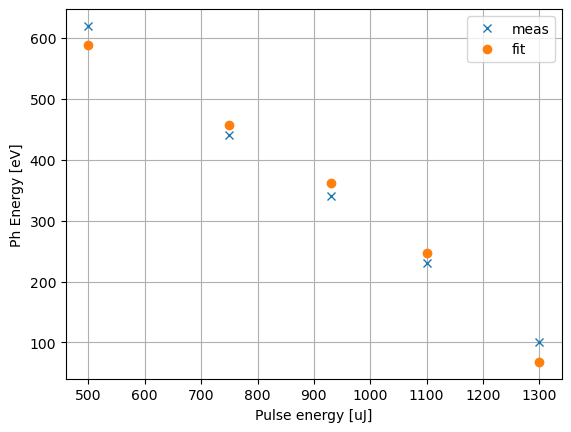

In [44]:
fits=[mixed_power_estimate(p, energy_spread_fit, emittance_fit, postamp=3.5)*1e6 for p in ph] 
ax=plt.gca() 
ax.plot(ph,res,'x', label='meas') 
ax.plot(ph,fits,'o', label='fit') 
ax.grid(which='both') 
ax.set_xlabel('Pulse energy [uJ]')
ax.set_ylabel('Ph Energy [eV]')
plt.legend()
plt.show()

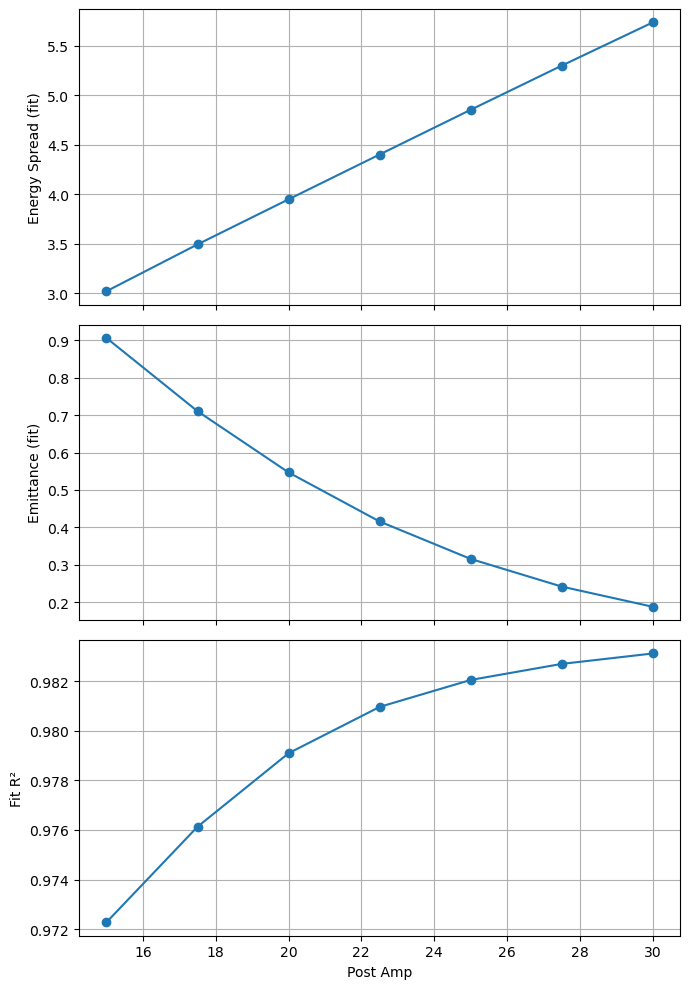

In [48]:
from functools import partial

@np.vectorize
def pulse_energy_model(photon_energy, energy_spread, emittance, s):
    return mixed_power_estimate(photon_energy, energy_spread, emittance, sigt=s) * 1e6

# Range of post_amp values to scan
scan_values = np.linspace(15,30, 7)

# Containers
fit_emittance = []
fit_energy_spread = []
fit_goodness = []

for s in scan_values:
    model = partial(pulse_energy_model, s=s)
    try:
        # curve_fit will treat `ph` as xdata, and extra args after p0 come via `args`
        params, cov = curve_fit(
            model, ph, res, p0=[4, 0.4]
        )
        energy_spread_fit, emittance_fit = params

        # Compute residuals and R²
        pred = pulse_energy_model(ph, *params, s=s)
        residuals = res - pred
        ss_res = np.sum(residuals**2)
        ss_tot = np.sum((res - np.mean(res))**2)
        r2 = 1 - (ss_res / ss_tot)

        fit_energy_spread.append(energy_spread_fit)
        fit_emittance.append(emittance_fit)
        fit_goodness.append(r2)

    except RuntimeError:
        fit_energy_spread.append(np.nan)
        fit_emittance.append(np.nan)
        fit_goodness.append(np.nan)

# Convert to arrays for plotting
fit_energy_spread = np.array(fit_energy_spread)
fit_emittance = np.array(fit_emittance)
fit_goodness = np.array(fit_goodness)

# --- Plot results ---
fig, ax = plt.subplots(3, 1, figsize=(7, 10), sharex=True)

ax[0].plot(scan_values, fit_energy_spread, 'o-')
ax[0].set_ylabel('Energy Spread (fit)')
ax[0].grid(True)

ax[1].plot(scan_values, fit_emittance, 'o-')
ax[1].set_ylabel('Emittance (fit)')
ax[1].grid(True)

ax[2].plot(scan_values, fit_goodness, 'o-')
ax[2].set_xlabel('Post Amp')
ax[2].set_ylabel('Fit R²')
ax[2].grid(True)

plt.tight_layout()
plt.show()


## Divergence

In [5]:
def divsimple(plam,lg,sigr):
    w0=2*np.sqrt(sigr*np.sqrt(2*plam*lg/4/np.pi))
    return plam/np.pi/w0/2 #/2 for intensity

In [5]:
import numpy as np
from scipy.integrate import quad

def integrand(t, w=1, mu=1, seta=0.01, kb=1, sx=1):
    # Compute the complex integrand value
    g = np.exp(-seta**2 * t**2 / 2 - 1j * mu * t)
    denom = (1 + 1j * kb**2 * sx**2 * t + 2 * w)**2 - 4 * w**2 * np.cos(kb * t)**2
    integrand_value = t * g / denom
    
    # Return the real and imaginary parts separately
    return np.real(integrand_value), np.imag(integrand_value)

def integrate_complex(w, mu=1, seta=0.01, kb=1, sx=1):
    # Define the integrands for the real and imaginary parts
    def real_integrand(t):
        return integrand(t, w, mu, seta, kb, sx)[0]
    
    def imag_integrand(t):
        return integrand(t, w, mu, seta, kb, sx)[1]
    
    # Perform the integration for real and imaginary parts
    real_part, real_err = quad(real_integrand, -np.inf, 0, limit=1500)
    imag_part, imag_err = quad(imag_integrand, -np.inf, 0, limit=1500)
    
    # Combine results into a complex number
    return real_part + 1j * imag_part

# Example usage
w = 1
result = integrate_complex(w)
print("Integral result:", result)

Integral result: (0.01708806751618284-0.01081391674505174j)


In [420]:
import numpy as np
from scipy.integrate import quad

def integrand2(t, w=1, mu=1, seta=0.01, kb=1, sx=1):
    # Compute the complex integrand value
    g = np.exp(-seta**2 * t**2 / 2 - 1j * mu * t)
    denom = (1 + 1j * kb**2 * sx**2 * t + 2 * w)**2 - 4 * w**2 * np.cos(kb * t)**2
    num=(4 + 4j * kb**2 * sx**2 * t) - 8 * w * np.cos(kb * t)**2
    integrand_value = num*t * g / denom**2
    
    # Return the real and imaginary parts separately
    return np.real(integrand_value), np.imag(integrand_value)

def integrate_complex2(w, mu=1, seta=0.01, kb=1, sx=1):
    # Define the integrands for the real and imaginary parts
    def real_integrand(t):
        return integrand2(t, w, mu, seta, kb, sx)[0]
    
    def imag_integrand(t):
        return integrand2(t, w, mu, seta, kb, sx)[1]
    
    # Perform the integration for real and imaginary parts
    real_part, real_err = quad(real_integrand, -np.inf, 0, limit=1500)
    imag_part, imag_err = quad(imag_integrand, -np.inf, 0, limit=1500)
    
    # Combine results into a complex number
    return real_part + 1j * imag_part

# Example usage
w = 1
result = integrate_complex2(w)
print("Integral result:", result)

Integral result: (0.04123648679860432+0.017374376152297102j)


In [11]:
from scipy.optimize import minimize
def costfun(w_real_imag, mu=np.sqrt(3)/2*1j-1/2, seta=0.001, kb=0.1, sx=0.5):
    w = w_real_imag[0] + 1j * w_real_imag[1]  # Convert real and imaginary parts to complex
    I = (mu + 1) / (4 * w) - 1 / (4 * sx**2) - integrate_complex(w, mu, seta, kb, sx)
    return np.abs(I)  # Objective is the magnitude of the complex result

def costfun2(w_real_imag, mu=np.sqrt(3)/2*1j-1/2, seta=0.001, kb=0.1, sx=0.5):
    w = w_real_imag[0] + 1j * w_real_imag[1]  # Convert real and imaginary parts to complex
    I = (mu + 1) / (4 * w**2) - integrate_complex2(w, mu, seta, kb, sx)
    return np.abs(I)  # Objective is the magnitude of the complex result

print(minimize(costfun,x0=[0.2,0.1]))
print(minimize(costfun2,x0=[0.2,0.1]))

  message: Desired error not necessarily achieved due to precision loss.
  success: False
   status: 2
      fun: 4.1772218125310546e-08
        x: [ 2.171e-01  1.258e-01]
      nit: 26
      jac: [ 4.405e-02  1.730e-01]
 hess_inv: [[ 2.491e-09  1.235e-10]
            [ 1.235e-10  2.587e-09]]
     nfev: 180
     njev: 56


NameError: name 'integrate_complex2' is not defined

In [ ]:
import numpy as np
from scipy.integrate import quad

def integrandmx(t, w=1, q=1, seta=0.01, kb=1, sx=1):
    ne=2/np.sqrt(3)*kb**2*sx**2;
    ng=seta/np.sqrt(3);
    nd=1/(2*np.sqrt(3))/sx**2;
    nw=-2/np.sqrt(3) #related to detuning
    h=(2/np.sqrt(3))**3
    
    # Compute the complex integrand value
    f1 = (q-1j*nw)*t-2*ng**2*t**2
    f2 = (1+1j*ne*t)**2+4*w*(1+1j*ne*t)+4*w**2*np.sin(2*np.sqrt(nd*ne)*t)**2
    integrand_value = t*h*np.exp(f1)/f2
    
    # Return the real and imaginary parts separately
    return np.real(integrand_value), np.imag(integrand_value)

def integrate_complexmx(w, q=(1+1j/np.sqrt(3)), seta=0.01, kb=1, sx=1):
    # Define the integrands for the real and imaginary parts
    def real_integrand(t):
        return integrandmx(t, w, q, seta, kb, sx)[0]
    
    def imag_integrand(t):
        return integrandmx(t, w, q, seta, kb, sx)[1]
    
    # Perform the integration for real and imaginary parts
    real_part, real_err = quad(real_integrand, -np.inf, 0, limit=1500,epsrel=1e-3)
    imag_part, imag_err = quad(imag_integrand, -np.inf, 0, limit=1500,epsrel=1e-3)
    
    # Combine results into a complex number
    return real_part + 1j * imag_part

def costfunmx(w_real_imag, q=(1+1j/np.sqrt(3)), seta=0.001, kb=0.1, sx=0.5):
    w = w_real_imag[0] + 1j * w_real_imag[1]  # Convert real and imaginary parts to complex
    nd=1/(2*np.sqrt(3))/sx**2;
    I = (q) / (4 * w)-nd -integrate_complexmx(w, q, seta, kb, sx)
    return np.abs(I)  # Objective is t
# Example usage
w = 0.2
result = integrate_complexmx(w)
print("Integral result:", result)

In [468]:
-2/np.sqrt(3)

-1.1547005383792517

In [568]:
gamma0=8000/0.511
delgamma=1.1/0.511
current=1.35e3
emittance=0.1*1e-6
plam=1240e-9/1000
lamU=0.056
Kgen=np.sqrt(2*gamma0**2*plam/lamU-1)

L=4.4;
Bp=3.336 #per GeV in [T m];
Bdz=np.min([3,Bp*(gamma0*0.511/1000)*2/L-0.1]);
Bdz=2
f=Bp*(gamma0*0.511/1000)/Bdz
k=2*f/L
beta1=L*k*(k+1)/np.sqrt(k**2-1)
beta2=L*k*(k-1)/np.sqrt(k**2-1)
sigBeam=np.sqrt(np.sqrt(beta1*beta2)*emittance/gamma0)

MX=analysis.MingXie(Kgen,2*np.pi/lamU,gamma0,delgamma/gamma0,current,sigBeam,emittance,plam,0);
mu=(MX['Lg']/MX['Lg1d'])*np.sqrt(3)/2*1j-1/2
q=(MX['Lg1d']/MX['Lg'])+1j/np.sqrt(3)
seta=delgamma/gamma0/MX['rho']
kb=(emittance/gamma0/sigBeam**2)/(2*2*np.pi/lamU*MX['rho']) #kb=1/beta, then normed by 2*ku*rho
sx=sigBeam*np.sqrt(2*2*np.pi*2*np.pi/lamU/plam*MX['rho'])
#sol=minimize(costfun,x0=[1/sx,0],args=(mu, seta, kb, sx))
sol=minimize(costfunmx,x0=[1/sx,0],args=(q, seta, kb, sx))
sol

  message: Desired error not necessarily achieved due to precision loss.
  success: False
   status: 2
      fun: 4.402601497777584e-08
        x: [ 1.886e-01  1.192e-01]
      nit: 33
      jac: [-2.970e-03  3.537e-02]
 hess_inv: [[ 2.579e-09  4.975e-12]
            [ 4.975e-12  2.505e-09]]
     nfev: 222
     njev: 70

In [575]:
(sigBeam/(2*np.sqrt(sigBeam*np.sqrt(2*plam*MX['Lg']/4/np.pi))))**2

0.16584905787175727

In [569]:
#xideal=(0.5*(sx**2+1j*np.sqrt(3)*sx**2))
#print(xideal)
#sol['x'][0]=np.real(xideal)
#sol['x'][1]=np.imag(xideal)
wz=sigBeam/np.sqrt(sol['x'][0])
Rz=np.pi/plam*sigBeam**2/sol['x'][1]

w0=Rz*wz*plam/np.sqrt(np.pi**2*wz**4+Rz**2*plam**2)
z=np.pi**2*Rz*wz**4/(np.pi**2*wz**4+Rz**2*plam**2)
print(w0,wz,z,plam/np.pi/w0/2)
print(np.sqrt(sol['x'][0]*(1+(sol['x'][1]/sol['x'][0])**2))*(plam/np.pi/sigBeam)/2)

2.541635164544794e-05 3.006612047619616e-05 1.0342725078527608 7.764770183658358e-06
7.764770183658358e-06


In [453]:
2*np.sqrt(sigBeam*np.sqrt(2*plam*MX['Lg']/4/np.pi))

3.206025458230496e-05

In [454]:
plam/np.pi/(2*np.sqrt(sigBeam*np.sqrt(2*plam*MX['Lg']/4/np.pi)))*1e6/2

6.155663203712517

In [576]:
gamma0=4000/0.511
delgamma=1.1/0.511
current=1.0e3
emittance=0.3*1e-6
plam=1240e-9/750
lamU=0.039
Kgen=np.sqrt(2*gamma0**2*plam/lamU-1)

L=4.4;
Bp=3.336 #per GeV in [T m];
Bdz=np.min([3,Bp*(gamma0*0.511/1000)*2/L-0.1]);
Bdz=2
f=Bp*(gamma0*0.511/1000)/Bdz
k=2*f/L
beta1=L*k*(k+1)/np.sqrt(k**2-1)
beta2=L*k*(k-1)/np.sqrt(k**2-1)
sigBeam=np.sqrt(np.sqrt(beta1*beta2)*emittance/gamma0)

MX=analysis.MingXie(Kgen,2*np.pi/lamU,gamma0,delgamma/gamma0,current,sigBeam,emittance,plam,0);
mu=(MX['Lg']/MX['Lg1d'])*np.sqrt(3)/2*1j-1/2
q=(MX['Lg1d']/MX['Lg'])+1j/np.sqrt(3)
seta=delgamma/gamma0/MX['rho']
kb=(emittance/gamma0/sigBeam**2)/(2*2*np.pi/lamU*MX['rho']) #kb=1/beta, then normed by 2*ku*rho
sx=sigBeam*np.sqrt(2*2*np.pi*2*np.pi/lamU/plam*MX['rho'])
#sol=minimize(costfun,x0=[1/sx,0],args=(mu, seta, kb, sx))
sol=minimize(costfunmx,x0=[1/sx,0],args=(q, seta, kb, sx))
sol

  message: Desired error not necessarily achieved due to precision loss.
  success: False
   status: 2
      fun: 4.1512179035363e-09
        x: [ 4.668e-01  2.313e-01]
      nit: 30
      jac: [ 3.960e-01  1.812e-01]
 hess_inv: [[ 4.130e-08  8.848e-09]
            [ 8.848e-09  1.903e-08]]
     nfev: 210
     njev: 66

In [500]:
#xideal=(0.5*(sx**2+1j*np.sqrt(3)*sx**2))
#print(xideal)
#sol['x'][0]=np.real(xideal)
#sol['x'][1]=np.imag(xideal)
wz=sigBeam/np.sqrt(sol['x'][0])
Rz=np.pi/plam*sigBeam**2/sol['x'][1]

w0=Rz*wz*plam/np.sqrt(np.pi**2*wz**4+Rz**2*plam**2)
z=np.pi**2*Rz*wz**4/(np.pi**2*wz**4+Rz**2*plam**2)
print(w0,wz,z,plam/np.pi/w0/2)
print(np.sqrt(sol['x'][0]*(1+(sol['x'][1]/sol['x'][0])**2))*(plam/np.pi/sigBeam)/2)

2.9658158168398178e-05 3.310057780365735e-05 0.8283285433184082 8.872303232200751e-06
8.87230323220075e-06


In [477]:
print(2*np.sqrt(sigBeam*np.sqrt(2*plam*MX['Lg']/4/np.pi)))
print(plam/np.pi/(2*np.sqrt(sigBeam*np.sqrt(2*plam*MX['Lg']/4/np.pi)))*1e6/2)

4.34726401693521e-05
6.052914466513341


In [399]:
(MX['Lg']/MX['Lg1d'])

1.3967158197315725

In [577]:
fig = plt.figure(num=1,figsize=[3.375*1.61,3.375])
fig.clf()

def div_estimate(beamEnergy,phEnergy):
    gamma0=beamEnergy/0.511
    delgamma=1.1/0.511
    current=1.35e3
    emittance=0.27*1e-6
    plam=1240e-9/phEnergy
    lamU=0.039
    Kgen=np.sqrt(2*gamma0**2*plam/lamU-1)
    if Kgen>5.44/np.sqrt(2):
        return 0
    if Kgen <0.25/np.sqrt(2):
        return 0
    
    L=4.4;
    Bp=3.336 #per GeV in [T m];
    Bdz=np.min([3,Bp*(gamma0*0.511/1000)*2/L-0.1]);
    f=Bp*(gamma0*0.511/1000)/Bdz
    k=2*f/L
    if (k**2-1)<=0:
        return 0
    beta1=L*k*(k+1)/np.sqrt(k**2-1)
    beta2=L*k*(k-1)/np.sqrt(k**2-1)
    sigBeam=np.sqrt(np.sqrt(beta1*beta2)*emittance/gamma0)
    ts=np.linspace(-100,100,500);
    cur=current*np.exp(-0.5*(ts/20)**2)

    MX=analysis.MingXie(Kgen,2*np.pi/lamU,gamma0,delgamma/gamma0,current,sigBeam,emittance,plam,0);
    mu=(MX['Lg']/MX['Lg1d'])*np.sqrt(3)/2*1j-1/2
    q=(MX['Lg1d']/MX['Lg'])+1j/np.sqrt(3)
    seta=delgamma/gamma0/MX['rho']
    kb=(emittance/gamma0/sigBeam**2)/(2*2*np.pi/lamU*MX['rho']) #kb=1/beta, then normed by 2*ku*rho
    sx=sigBeam*np.sqrt(2*2*np.pi*2*np.pi/lamU/plam*MX['rho'])
    #sol=minimize(costfun,x0=[1/sx,0],args=(mu, seta, kb, sx))
    sol=minimize(costfunmx,x0=[2*np.sqrt(sigBeam*np.sqrt(2*plam*MX['Lg']/4/np.pi)),2*np.sqrt(sigBeam*np.sqrt(2*plam*MX['Lg']/4/np.pi))],args=(q, seta, kb, sx))
    p=np.sqrt(sol['x'][0]*(1+(sol['x'][1]/sol['x'][0])**2))*(plam/np.pi/sigBeam)/2;
    print(p)
    if np.isnan(p):
        return 0
    return p
    


ph_ens=np.linspace(25,1500,30)
beam_ens=[2000,3000,4000]#np.logspace(np.log10(1500),np.log10(4500),5);
[B,P]=np.meshgrid(beam_ens,ph_ens,indexing='ij')
En = np.empty(B.shape)
for i in range(B.shape[0]):
    for j in range(B.shape[1]):
        En[i, j] = div_estimate(B[i, j], P[i, j]) * 1e3

5.710805005057727e-05
3.967262840348216e-05
3.115842505654323e-05
2.5959013607331922e-05
2.2383905493438872e-05
1.9733920599617777e-05
1.766291378659031e-05
1.5977726488082857e-05
1.4560629294708644e-05
1.3334639421704305e-05
1.2246236942784655e-05
1.1255650203902212e-05
1.0329759687671743e-05
9.433224395554573e-06
8.509618864082582e-06
7.439767922027619e-06
6.077572181916215e-06
4.690486273631574e-06
nan
nan


/lscratch/dcesar/tmp/ipykernel_3587069/696195136.py:11: RuntimeWarning: invalid value encountered in sqrt
  Kgen=np.sqrt(2*gamma0**2*plam/lamU-1)
/lscratch/dcesar/tmp/ipykernel_3587069/243708579.py:37: RuntimeWarning: invalid value encountered in scalar divide
  I = (q) / (4 * w)-nd -integrate_complexmx(w, q, seta, kb, sx)
/lscratch/dcesar/tmp/ipykernel_3587069/243708579.py:14: RuntimeWarning: invalid value encountered in scalar divide
  integrand_value = t*h*np.exp(f1)/f2
/lscratch/dcesar/tmp/ipykernel_3587069/243708579.py:28: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  real_part, real_err = quad(real_integrand, -np.inf, 0, limit=1500,epsrel=1e-3)
/lscratch/dcesar/tmp/ipykernel_3587069/243708579.py:29: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimate

nan
nan
nan
nan
nan
nan
nan
nan
nan
2.9741969174258885e-05
2.489526657533382e-05
2.1591358764995746e-05
1.9169843106210615e-05
1.7304655287394502e-05
1.581488835344585e-05
1.4591502597489958e-05
1.3564563079795736e-05
1.2686988667352212e-05
1.1925822647971728e-05
1.1257241560757465e-05
1.0663551128817713e-05
1.0131299231700147e-05
9.650048778810071e-06
9.21155582414203e-06
8.809203534019826e-06
8.437606187893951e-06
8.092325131258047e-06
7.769662519068132e-06
7.46650754757439e-06
7.180219833477643e-06
6.908536285965121e-06
6.649492213658402e-06
6.401348031472019e-06
6.162512632560581e-06
5.93145476043548e-06
5.70659027552504e-06
2.0781241714965724e-05
1.8475765001443535e-05
1.6703780818242968e-05
1.5291957639258355e-05
1.4135844879120508e-05
1.3168471599594159e-05
1.2344772854990508e-05
1.1633226651636626e-05
1.1011071383882395e-05
1.0461428524711523e-05
9.971497249728258e-06
9.531378355157005e-06
9.133286933812412e-06
8.771009261038775e-06
8.439520208969717e-06
8.134707849928203e-06
7

<Figure size 543.375x337.5 with 0 Axes>

In [546]:
fig = plt.figure(num=1,figsize=[3.375*1.61,3.375])
fig.clf()

def div_estimate(beamEnergy,phEnergy):
    gamma0=beamEnergy/0.511
    delgamma=1.1/0.511
    current=1.35e3
    emittance=0.27*1e-6
    plam=1240e-9/phEnergy
    lamU=0.039
    Kgen=np.sqrt(2*gamma0**2*plam/lamU-1)
    if Kgen>5.44/np.sqrt(2):
        return 0
    
    L=4.4;
    Bp=3.336 #per GeV in [T m];
    Bdz=np.min([3,Bp*(gamma0*0.511/1000)*2/L-0.1]);
    f=Bp*(gamma0*0.511/1000)/Bdz
    k=2*f/L
    if (k**2-1)<=0:
        return 0
    beta1=L*k*(k+1)/np.sqrt(k**2-1)
    beta2=L*k*(k-1)/np.sqrt(k**2-1)
    sigBeam=np.sqrt(np.sqrt(beta1*beta2)*emittance/gamma0)
    ts=np.linspace(-100,100,500);
    cur=current*np.exp(-0.5*(ts/20)**2)

    MX=analysis.MingXie(Kgen,2*np.pi/lamU,gamma0,delgamma/gamma0,current,sigBeam,emittance,plam,0)
    Lg=MX['Lg']
    p=divsimple(plam,Lg,sigBeam)
    if np.isnan(p):
        return 0
    return p
    


En2 = np.empty(B.shape)
for i in range(B.shape[0]):
    for j in range(B.shape[1]):
        En2[i, j] = div_estimate(B[i, j], P[i, j]) * 1e3

/lscratch/dcesar/tmp/ipykernel_3587069/1174865789.py:11: RuntimeWarning: invalid value encountered in sqrt
  Kgen=np.sqrt(2*gamma0**2*plam/lamU-1)


<Figure size 543.375x337.5 with 0 Axes>

In [547]:
fig = plt.figure(num=1,figsize=[3.375*1.61,3.375])
fig.clf()
from scipy.special import jv

def div_estimate(beamEnergy,phEnergy):
    gamma0=beamEnergy/0.511
    delgamma=1.1/0.511
    current=1.35e3
    emittance=0.27*1e-6
    plam=1240e-9/phEnergy
    lamU=0.039
    Kgen=np.sqrt(2*gamma0**2*plam/lamU-1)
    if Kgen>5.44/np.sqrt(2):
        return 0
    if Kgen <0.25/np.sqrt(2):
        return 0
    
    L=4.4;
    Bp=3.336 #per GeV in [T m];
    Bdz=np.min([3,Bp*(gamma0*0.511/1000)*2/L-0.1]);
    f=Bp*(gamma0*0.511/1000)/Bdz
    k=2*f/L
    if (k**2-1)<=0:
        return 0
    beta1=L*k*(k+1)/np.sqrt(k**2-1)
    beta2=L*k*(k-1)/np.sqrt(k**2-1)
    sigBeam=np.sqrt(np.sqrt(beta1*beta2)*emittance/gamma0)
    ts=np.linspace(-100,100,500);
    cur=current*np.exp(-0.5*(ts/20)**2)
    jj=jj=(jv(0,Kgen**2/2/(1+Kgen**2))-jv(1,Kgen**2/2/(1+Kgen**2)))
    Lg=lamU/4/np.pi*np.sqrt(gamma0*17e3/current*(1+Kgen**2)/(Kgen**2*2*jj**2))
    sigr=np.sqrt(plam/4/np.pi*2*Lg)
    p=plam/np.pi/(sigr*2)/2
    if np.isnan(p):
        return 0
    return p
    


En3 = np.empty(B.shape)
for i in range(B.shape[0]):
    for j in range(B.shape[1]):
        En3[i, j] = div_estimate(B[i, j], P[i, j]) * 1e3

/lscratch/dcesar/tmp/ipykernel_3587069/761496395.py:12: RuntimeWarning: invalid value encountered in sqrt
  Kgen=np.sqrt(2*gamma0**2*plam/lamU-1)


<Figure size 543.375x337.5 with 0 Axes>

Text(0.5, 1.0, 'LCLS-II w/ 21 39 mm undulators')

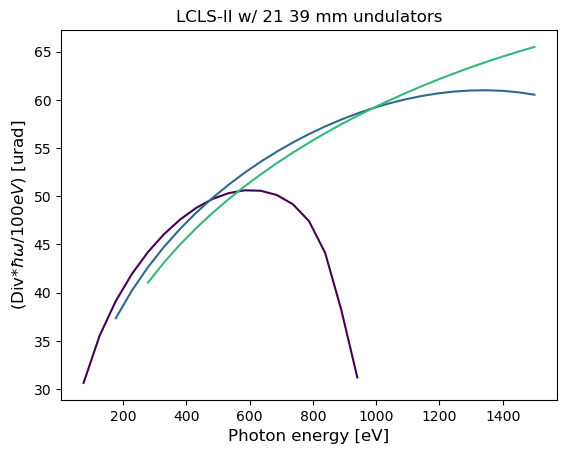

In [578]:
ax=plt.gca()
for ii in range(B.shape[0]):
    mask=En[ii,:]!=0;
    p=ax.plot(ph_ens[mask],1e3*(En[ii,mask]*ph_ens[mask]/100/np.sqrt(2)),color=cm.viridis(ii/3))
    #p=ax.plot(ph_ens[mask],1e3*(En2[ii,mask]*ph_ens[mask]/100),'--',color=cm.viridis(ii/3))
    #p=ax.plot(ph_ens[mask],1e3*(En3[ii,mask]*ph_ens[mask]/100),'-.',color=cm.viridis(ii/3))
#ax.set_yscale('log')
#ax.set_xscale('log')
ax.set_ylabel('(Div$*\hbar\omega/100eV$) [urad]',fontsize=12)
ax.set_xlabel('Photon energy [eV]',fontsize=12)
ax.set_title('LCLS-II w/ 21 39 mm undulators')

Text(0.5, 1.0, 'LCLS-II w/ 21 39 mm undulators')

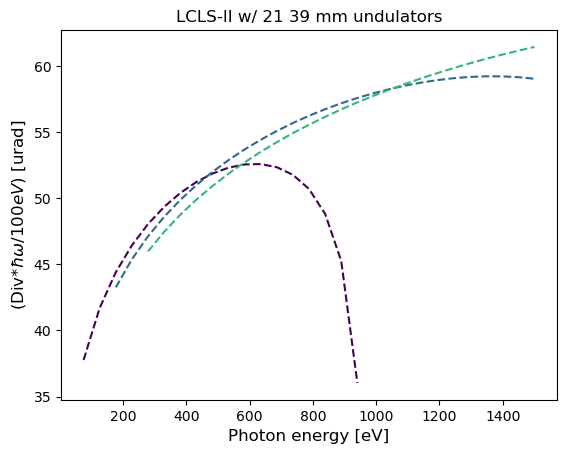

In [596]:
ax=plt.gca()
for ii in range(B.shape[0]):
    mask=En[ii,:]!=0;
    #p=ax.plot(ph_ens[mask],1e3*(En[ii,mask]*ph_ens[mask]/100/np.sqrt(2)),color=cm.viridis(ii/3))
    p=ax.plot(ph_ens[mask],1e3*(En2[ii,mask]*ph_ens[mask]/100),'--',color=cm.viridis(ii/3))
    #p=ax.plot(ph_ens[mask],1e3*(En3[ii,mask]*ph_ens[mask]/100),'-.',color=cm.viridis(ii/3))
#ax.set_yscale('log')
#ax.set_xscale('log')
ax.set_ylabel('(Div$*\hbar\omega/100eV$) [urad]',fontsize=12)
ax.set_xlabel('Photon energy [eV]',fontsize=12)
ax.set_title('LCLS-II w/ 21 39 mm undulators')

## simpler div

In [579]:
# Let's try averaging over the beam size, but including some average of the two extreme estimates

/lscratch/dcesar/tmp/ipykernel_3136133/1703590041.py:19: RuntimeWarning: invalid value encountered in sqrt
  Kgen=np.sqrt(2*gamma0**2*plam/lamU-1)
/lscratch/dcesar/tmp/ipykernel_3136133/1703590041.py:97: RuntimeWarning: invalid value encountered in sqrt
  Kgen=np.sqrt(2*gamma0**2*plam/lamU-1)


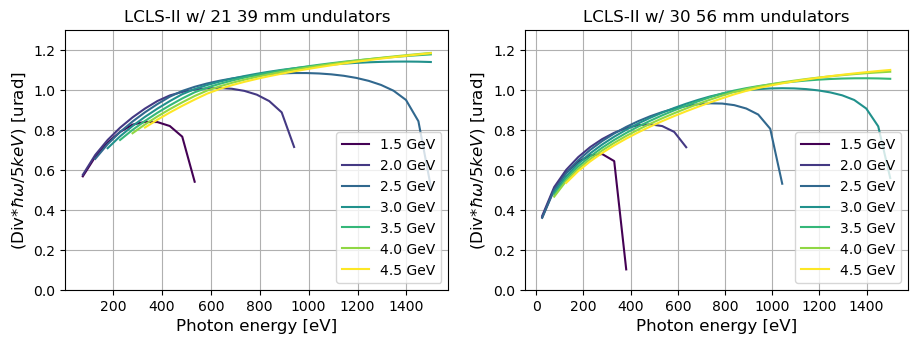

In [10]:
fig = plt.figure(num=1,figsize=[3.375*1.61*2,3.375])
fig.clf()
ax=plt.subplot(1,2,1)

def int_MX(ts,cur,mxp):
    MX=analysis.MingXie(mxp[0],mxp[1],mxp[2],mxp[3],cur,mxp[5],mxp[6],mxp[7],mxp[8])
    Lgs=MX['Lg']
    psats=MX['Psat']
    return np.trapz(power(psats,gl=Lgs,und_len=3.4*21,sat_gl=21,postamp=2.25),ts)

@np.vectorize
def div_estimate(beamEnergy,phEnergy):
    gamma0=beamEnergy/0.511
    delgamma=1.1/0.511
    current=1.35e3
    emittance=0.27*1e-6
    plam=1240e-9/phEnergy
    lamU=0.039
    Kgen=np.sqrt(2*gamma0**2*plam/lamU-1)
    if Kgen>5.44/np.sqrt(2):
        return 0
    
    L=4.4;
    Bp=3.336 #per GeV in [T m];
    Bdz=np.min([3,Bp*(gamma0*0.511/1000)*2/L-0.1]);
    f=Bp*(gamma0*0.511/1000)/Bdz
    k=2*f/L
    if (k**2-1)<=0:
        return 0
    beta1=L*k*(k+1)/np.sqrt(k**2-1)
    beta2=L*k*(k-1)/np.sqrt(k**2-1)
    sigBeam=np.sqrt(np.sqrt(beta1*beta2)*emittance/gamma0)
    ts=np.linspace(-100,100,500);
    cur=current*np.exp(-0.5*(ts/20)**2)

    MX=analysis.MingXie(Kgen,2*np.pi/lamU,gamma0,delgamma/gamma0,cur,sigBeam,emittance,plam,0)
    Lgs=MX['Lg']
    Psats=MX['Psat']
    ps=divsimple(plam,Lgs,sigBeam)
    jj=jv(0,Kgen**2/2/(1+Kgen**2))-jv(1,Kgen**2/2/(1+Kgen**2))
    Lg=lamU/4/np.pi*np.sqrt(gamma0*17e3/cur*(1+Kgen**2)/(Kgen**2*2*jj**2))
    sigr=np.sqrt(plam/4/np.pi*2*Lg)
    p2=plam/np.pi/(sigr*2)/2
    ps[p2<ps]=(ps[p2<ps]+p2[p2<ps])/2
    p=np.trapz(ps*power(Psats,gl=Lgs,und_len=3.4*30,sat_gl=21,postamp=2.25),ts)/np.trapz(power(Psats,gl=Lgs,und_len=3.4*30,sat_gl=21,postamp=2.25),ts)
    if np.isnan(p):
        p=0
    return p
    

ax=plt.gca()
ph_ens=np.linspace(25,1500,30)
beam_ens=np.arange(1500,5000,500)#np.logspace(np.log10(1500),np.log10(4500),5);
[B,P]=np.meshgrid(beam_ens,ph_ens,indexing='ij')
En = np.empty(B.shape)
for i in range(B.shape[0]):
    for j in range(B.shape[1]):
        En[i, j] = div_estimate(B[i, j], P[i, j]) * 1e3
for ii in range(B.shape[0]):
    mask=En[ii,:]!=0;
    p=ax.plot(ph_ens[mask],1e3*(En[ii,mask]*ph_ens[mask]/5000),color=cm.viridis((beam_ens[ii]-1500)/3000),label='{:2.1f} GeV'.format(beam_ens[ii]/1000))

#sm = plt.cm.ScalarMappable(cmap=cm.viridis, norm=cm.viridis.N)
#sm.set_array([])  # Only needed for the colorbar
#cbar = fig.colorbar(sm, ax=ax, boundaries=levels, ticks=levels, spacing='proportional')
#cbar.set_label('Beam Energy Bands')

#ax.set_yscale('log')
#ax.set_xscale('log')
ax.set_ylabel('(Div$*\hbar\omega/5keV$) [urad]',fontsize=12)
ax.set_xlabel('Photon energy [eV]',fontsize=12)
ax.set_title('LCLS-II w/ 21 39 mm undulators')
ax.grid(which='both')
ax.set_ylim([0,1.3])
plt.legend()




def int_MX(ts,cur,mxp):
    MX=analysis.MingXie(mxp[0],mxp[1],mxp[2],mxp[3],cur,mxp[5],mxp[6],mxp[7],mxp[8])
    Lgs=MX['Lg']
    psats=MX['Psat']
    return np.trapz(power(psats,gl=Lgs,und_len=3.4*30,sat_gl=21,postamp=2.25),ts)


ax=plt.subplot(1,2,2)

@np.vectorize
def div_estimate(beamEnergy,phEnergy):
    gamma0=beamEnergy/0.511
    delgamma=1.1/0.511
    current=1.35e3
    emittance=0.27*1e-6
    plam=1240e-9/phEnergy
    lamU=0.056
    Kgen=np.sqrt(2*gamma0**2*plam/lamU-1)
    if Kgen>9.21/np.sqrt(2):
        return 0
    
    L=4.4;
    Bp=3.336 #per GeV in [T m];
    Bdz=np.min([3,Bp*(gamma0*0.511/1000)*2/L-0.1]);
    f=Bp*(gamma0*0.511/1000)/Bdz
    k=2*f/L
    if (k**2-1)<=0:
        return 0
    beta1=L*k*(k+1)/np.sqrt(k**2-1)
    beta2=L*k*(k-1)/np.sqrt(k**2-1)
    sigBeam=np.sqrt(np.sqrt(beta1*beta2)*emittance/gamma0)
    ts=np.linspace(-100,100,500);
    cur=current*np.exp(-0.5*(ts/20)**2)

    MX=analysis.MingXie(Kgen,2*np.pi/lamU,gamma0,delgamma/gamma0,cur,sigBeam,emittance,plam,0)
    Lgs=MX['Lg']
    Psats=MX['Psat']
    ps=divsimple(plam,Lgs,sigBeam)
    jj=jv(0,Kgen**2/2/(1+Kgen**2))-jv(1,Kgen**2/2/(1+Kgen**2))
    Lg=lamU/4/np.pi*np.sqrt(gamma0*17e3/cur*(1+Kgen**2)/(Kgen**2*2*jj**2))
    sigr=np.sqrt(plam/4/np.pi*2*Lg)
    p2=plam/np.pi/(sigr*2)/2
    ps[p2<ps]=(ps[p2<ps]+p2[p2<ps])/2
    p=np.trapz(ps*power(Psats,gl=Lgs,und_len=3.4*30,sat_gl=21,postamp=2.25),ts)/np.trapz(power(Psats,gl=Lgs,und_len=3.4*30,sat_gl=21,postamp=2.25),ts)
    if np.isnan(p):
        p=0
    return p
    

ax=plt.gca()
ph_ens=np.linspace(25,1500,30)
beam_ens=np.arange(1500,5000,500)#np.logspace(np.log10(1500),np.log10(4500),5);
[B,P]=np.meshgrid(beam_ens,ph_ens,indexing='ij')
En = np.empty(B.shape)
for i in range(B.shape[0]):
    for j in range(B.shape[1]):
        En[i, j] = div_estimate(B[i, j], P[i, j]) * 1e3
for ii in range(B.shape[0]):
    mask=En[ii,:]!=0;
    p=ax.plot(ph_ens[mask],1e3*(En[ii,mask]*ph_ens[mask]/5000),color=cm.viridis((beam_ens[ii]-1500)/3000),label='{:2.1f} GeV'.format(beam_ens[ii]/1000))

#sm = plt.cm.ScalarMappable(cmap=cm.viridis, norm=cm.viridis.N)
#sm.set_array([])  # Only needed for the colorbar
#cbar = fig.colorbar(sm, ax=ax, boundaries=levels, ticks=levels, spacing='proportional')
#cbar.set_label('Beam Energy Bands')

#ax.set_yscale('log')
#ax.set_xscale('log')
ax.set_ylabel('(Div$*\hbar\omega/5keV$) [urad]',fontsize=12)
ax.set_xlabel('Photon energy [eV]',fontsize=12)
ax.set_title('LCLS-II w/ 30 56 mm undulators')
ax.grid(which='both')
ax.set_ylim([0,1.3])
plt.legend()

plt.show()

/lscratch/dcesar/tmp/ipykernel_3587069/1459440600.py:19: RuntimeWarning: invalid value encountered in sqrt
  Kgen=np.sqrt(2*gamma0**2*plam/lamU-1)
/lscratch/dcesar/tmp/ipykernel_3587069/1459440600.py:97: RuntimeWarning: invalid value encountered in sqrt
  Kgen=np.sqrt(2*gamma0**2*plam/lamU-1)


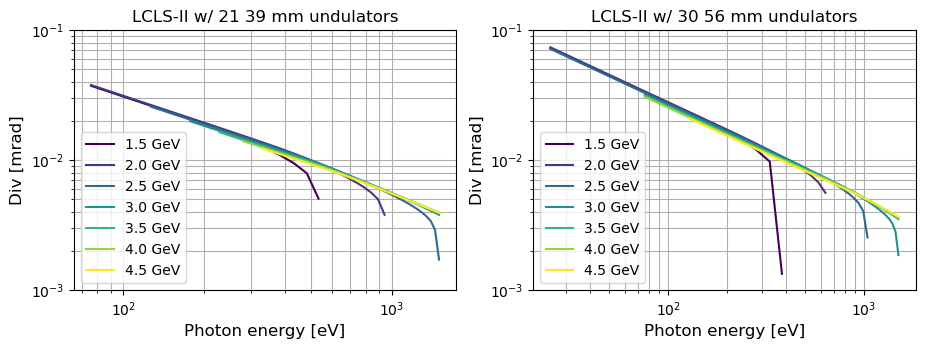

In [633]:
fig = plt.figure(num=1,figsize=[3.375*1.61*2,3.375])
fig.clf()
ax=plt.subplot(1,2,1)

def int_MX(ts,cur,mxp):
    MX=analysis.MingXie(mxp[0],mxp[1],mxp[2],mxp[3],cur,mxp[5],mxp[6],mxp[7],mxp[8])
    Lgs=MX['Lg']
    psats=MX['Psat']
    return np.trapz(power(psats,gl=Lgs,und_len=3.4*21,sat_gl=21,postamp=2.25),ts)

@np.vectorize
def div_estimate(beamEnergy,phEnergy):
    gamma0=beamEnergy/0.511
    delgamma=1.1/0.511
    current=1.35e3
    emittance=0.27*1e-6
    plam=1240e-9/phEnergy
    lamU=0.039
    Kgen=np.sqrt(2*gamma0**2*plam/lamU-1)
    if Kgen>5.44/np.sqrt(2):
        return 0
    
    L=4.4;
    Bp=3.336 #per GeV in [T m];
    Bdz=np.min([3,Bp*(gamma0*0.511/1000)*2/L-0.1]);
    f=Bp*(gamma0*0.511/1000)/Bdz
    k=2*f/L
    if (k**2-1)<=0:
        return 0
    beta1=L*k*(k+1)/np.sqrt(k**2-1)
    beta2=L*k*(k-1)/np.sqrt(k**2-1)
    sigBeam=np.sqrt(np.sqrt(beta1*beta2)*emittance/gamma0)
    ts=np.linspace(-100,100,500);
    cur=current*np.exp(-0.5*(ts/20)**2)

    MX=analysis.MingXie(Kgen,2*np.pi/lamU,gamma0,delgamma/gamma0,cur,sigBeam,emittance,plam,0)
    Lgs=MX['Lg']
    Psats=MX['Psat']
    ps=divsimple(plam,Lgs,sigBeam)
    jj=jv(0,Kgen**2/2/(1+Kgen**2))-jv(1,Kgen**2/2/(1+Kgen**2))
    Lg=lamU/4/np.pi*np.sqrt(gamma0*17e3/cur*(1+Kgen**2)/(Kgen**2*2*jj**2))
    sigr=np.sqrt(plam/4/np.pi*2*Lg)
    p2=plam/np.pi/(sigr*2)/2
    ps[p2<ps]=(ps[p2<ps]+p2[p2<ps])/2
    p=np.trapz(ps*power(Psats,gl=Lgs,und_len=3.4*30,sat_gl=21,postamp=2.25),ts)/np.trapz(power(Psats,gl=Lgs,und_len=3.4*30,sat_gl=21,postamp=2.25),ts)
    if np.isnan(p):
        p=0
    return p
    

ax=plt.gca()
ph_ens=np.linspace(25,1500,30)
beam_ens=np.arange(1500,5000,500)#np.logspace(np.log10(1500),np.log10(4500),5);
[B,P]=np.meshgrid(beam_ens,ph_ens,indexing='ij')
En = np.empty(B.shape)
for i in range(B.shape[0]):
    for j in range(B.shape[1]):
        En[i, j] = div_estimate(B[i, j], P[i, j]) * 1e3
for ii in range(B.shape[0]):
    mask=En[ii,:]!=0;
    p=ax.plot(ph_ens[mask],(En[ii,mask]),color=cm.viridis((beam_ens[ii]-1500)/3000),label='{:2.1f} GeV'.format(beam_ens[ii]/1000))

#sm = plt.cm.ScalarMappable(cmap=cm.viridis, norm=cm.viridis.N)
#sm.set_array([])  # Only needed for the colorbar
#cbar = fig.colorbar(sm, ax=ax, boundaries=levels, ticks=levels, spacing='proportional')
#cbar.set_label('Beam Energy Bands')

ax.set_yscale('log')
ax.set_xscale('log')
ax.set_ylabel('Div [mrad]',fontsize=12)
ax.set_xlabel('Photon energy [eV]',fontsize=12)
ax.set_title('LCLS-II w/ 21 39 mm undulators')
ax.grid(which='both')
ax.set_ylim([1e-3,0.1])
plt.legend()




def int_MX(ts,cur,mxp):
    MX=analysis.MingXie(mxp[0],mxp[1],mxp[2],mxp[3],cur,mxp[5],mxp[6],mxp[7],mxp[8])
    Lgs=MX['Lg']
    psats=MX['Psat']
    return np.trapz(power(psats,gl=Lgs,und_len=3.4*30,sat_gl=21,postamp=2.25),ts)


ax=plt.subplot(1,2,2)

@np.vectorize
def div_estimate(beamEnergy,phEnergy):
    gamma0=beamEnergy/0.511
    delgamma=1.1/0.511
    current=1.35e3
    emittance=0.27*1e-6
    plam=1240e-9/phEnergy
    lamU=0.056
    Kgen=np.sqrt(2*gamma0**2*plam/lamU-1)
    if Kgen>9.23/np.sqrt(2):
        return 0
    
    L=4.4;
    Bp=3.336 #per GeV in [T m];
    Bdz=np.min([3,Bp*(gamma0*0.511/1000)*2/L-0.1]);
    f=Bp*(gamma0*0.511/1000)/Bdz
    k=2*f/L
    if (k**2-1)<=0:
        return 0
    beta1=L*k*(k+1)/np.sqrt(k**2-1)
    beta2=L*k*(k-1)/np.sqrt(k**2-1)
    sigBeam=np.sqrt(np.sqrt(beta1*beta2)*emittance/gamma0)
    ts=np.linspace(-100,100,500);
    cur=current*np.exp(-0.5*(ts/20)**2)

    MX=analysis.MingXie(Kgen,2*np.pi/lamU,gamma0,delgamma/gamma0,cur,sigBeam,emittance,plam,0)
    Lgs=MX['Lg']
    Psats=MX['Psat']
    ps=divsimple(plam,Lgs,sigBeam)
    jj=jv(0,Kgen**2/2/(1+Kgen**2))-jv(1,Kgen**2/2/(1+Kgen**2))
    Lg=lamU/4/np.pi*np.sqrt(gamma0*17e3/cur*(1+Kgen**2)/(Kgen**2*2*jj**2))
    sigr=np.sqrt(plam/4/np.pi*2*Lg)
    p2=plam/np.pi/(sigr*2)/2
    ps[p2<ps]=(ps[p2<ps]+p2[p2<ps])/2
    p=np.trapz(ps*power(Psats,gl=Lgs,und_len=3.4*30,sat_gl=21,postamp=2.25),ts)/np.trapz(power(Psats,gl=Lgs,und_len=3.4*30,sat_gl=21,postamp=2.25),ts)
    if np.isnan(p):
        p=0
    return p
    

ax=plt.gca()
ph_ens=np.linspace(25,1500,30)
beam_ens=np.arange(1500,5000,500)#np.logspace(np.log10(1500),np.log10(4500),5);
[B,P]=np.meshgrid(beam_ens,ph_ens,indexing='ij')
En = np.empty(B.shape)
for i in range(B.shape[0]):
    for j in range(B.shape[1]):
        En[i, j] = div_estimate(B[i, j], P[i, j]) * 1e3
for ii in range(B.shape[0]):
    mask=En[ii,:]!=0;
    p=ax.plot(ph_ens[mask],(En[ii,mask]),color=cm.viridis((beam_ens[ii]-1500)/3000),label='{:2.1f} GeV'.format(beam_ens[ii]/1000))

#sm = plt.cm.ScalarMappable(cmap=cm.viridis, norm=cm.viridis.N)
#sm.set_array([])  # Only needed for the colorbar
#cbar = fig.colorbar(sm, ax=ax, boundaries=levels, ticks=levels, spacing='proportional')
#cbar.set_label('Beam Energy Bands')

ax.set_yscale('log')
ax.set_xscale('log')
ax.set_ylabel('Div [mrad]',fontsize=12)
ax.set_xlabel('Photon energy [eV]',fontsize=12)
ax.set_title('LCLS-II w/ 30 56 mm undulators')
ax.grid(which='both')
ax.set_ylim([1e-3,0.1])
plt.legend()

plt.show()

105.09131194483118


(0.0, 200.0)

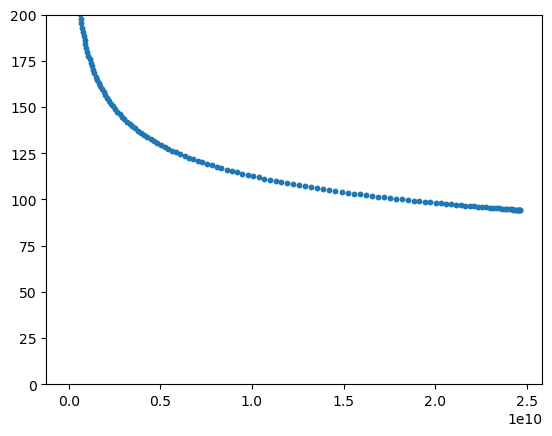

In [15]:
beamEnergy=2500
phEnergy=25

gamma0=beamEnergy/0.511
delgamma=1.1/0.511*beamEnergy/8000
current=1.35e3
emittance=0.27*1e-6
plam=1240e-9/phEnergy
lamU=0.056
Kgen=np.sqrt(2*gamma0**2*plam/lamU-1)

L=4.4;
Bp=3.336 #per GeV in [T m];
Bdz=np.min([3,Bp*(gamma0*0.511/1000)*2/L-0.1]);
f=Bp*(gamma0*0.511/1000)/Bdz
k=2*f/L
beta1=L*k*(k+1)/np.sqrt(k**2-1)
beta2=L*k*(k-1)/np.sqrt(k**2-1)
sigBeam=np.sqrt(np.sqrt(beta1*beta2)*emittance/gamma0)
ts=np.linspace(-100,100,500);
cur=current*np.exp(-0.5*(ts/20)**2)

MX=analysis.MingXie(Kgen,2*np.pi/lamU,gamma0,delgamma/gamma0,cur,sigBeam,emittance,plam,0)
Lgs=MX['Lg']
Psats=MX['Psat']
ps=divsimple(plam,Lgs,sigBeam)
jj=jv(0,Kgen**2/2/(1+Kgen**2))-jv(1,Kgen**2/2/(1+Kgen**2))
Lg=lamU/4/np.pi*np.sqrt(gamma0*17e3/cur*(1+Kgen**2)/(Kgen**2*2*jj**2))
sigr=np.sqrt(plam/4/np.pi*2*Lg)
print(np.trapz(sigr*power(Psats,gl=Lgs,und_len=3.4*30,sat_gl=21,postamp=2.25),ts)/np.trapz(power(Psats,gl=Lgs,und_len=3.4*30,sat_gl=21,postamp=2.25),ts)*1e6)
ax=plt.gca()
ax.plot(power(Psats,gl=Lgs,und_len=3.4*30,sat_gl=21,postamp=2.25),sigr*1e6,'.')
ax.set_ylim([0,200])

In [28]:
print(plam/np.pi/(200e-6*2)/2*1e6)
print(np.trapz(ps*power(Psats,gl=Lgs,und_len=3.4*30,sat_gl=21,postamp=2.25),ts)/np.trapz(power(Psats,gl=Lgs,und_len=3.4*30,sat_gl=21,postamp=2.25),ts)*1e6)
print(np.trapz((plam/np.pi/(sigr*2)/2)*power(Psats,gl=Lgs,und_len=3.4*30,sat_gl=21,postamp=2.25),ts)/np.trapz(power(Psats,gl=Lgs,und_len=3.4*30,sat_gl=21,postamp=2.25),ts)*1e6)

19.73521294339502
105.5466145667757
38.27513079051306


In [30]:
print(1240e-9/250/np.pi/(80e-6*2)/2*1e6)

4.933803235848755


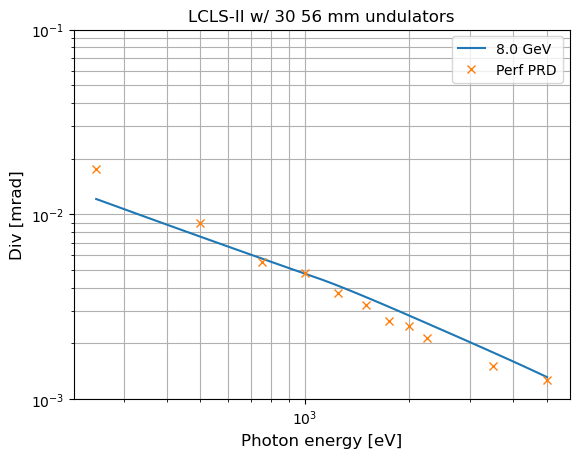

In [638]:
ph_ens=np.linspace(250,5000,50)
beam_ens=[8000]#np.logspace(np.log10(1500),np.log10(4500),5);
[B,P]=np.meshgrid(beam_ens,ph_ens,indexing='ij')
En = np.empty(B.shape)
for i in range(B.shape[0]):
    for j in range(B.shape[1]):
        En[i, j] = div_estimate(B[i, j], P[i, j]) * 1e3

ax=plt.gca()
for ii in range(B.shape[0]):
    mask=En[ii,:]!=0;
    p=ax.plot(ph_ens[mask],(En[ii,mask]),label='{:2.1f} GeV'.format(beam_ens[ii]/1000))

#sm = plt.cm.ScalarMappable(cmap=cm.viridis, norm=cm.viridis.N)
#sm.set_array([])  # Only needed for the colorbar
#cbar = fig.colorbar(sm, ax=ax, boundaries=levels, ticks=levels, spacing='proportional')
#cbar.set_label('Beam Energy Bands')

x=[250,500,750,1000,1250,1500,1750,2000,2250,3500,5000]
y=np.array([17.5,9,5.5,4.8,3.77,3.25,2.65,2.5,2.13,1.51,1.27])*1e-3
ax.plot(x,y,'x',label='Perf PRD')

ax.set_yscale('log')
ax.set_xscale('log')
ax.set_ylabel('Div [mrad]',fontsize=12)
ax.set_xlabel('Photon energy [eV]',fontsize=12)
ax.set_title('LCLS-II w/ 30 56 mm undulators')
ax.grid(which='both')
ax.set_ylim([1e-3,0.1])
plt.legend()

/lscratch/dcesar/tmp/ipykernel_3255985/3970320708.py:13: RuntimeWarning: invalid value encountered in sqrt
  Kgen=np.sqrt(2*gamma0**2*plam/lamU-1)


0.159

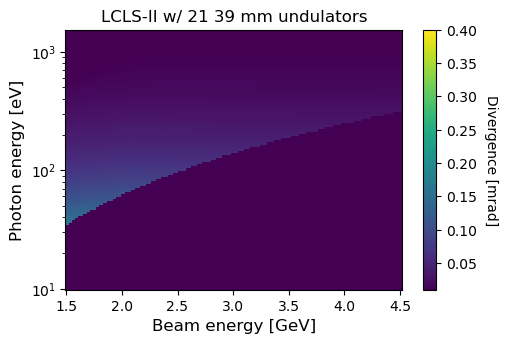

In [122]:
fig = plt.figure(num=1,figsize=[3.375*1.61,3.375])
fig.clf()
ax=plt.subplot(1,1,1)

@np.vectorize
def power_estimate(beamEnergy,phEnergy):
    gamma0=beamEnergy/0.511
    delgamma=1.1/0.511
    current=1.35e3
    emittance=0.27*1e-6
    plam=1240e-9/phEnergy
    lamU=0.039
    Kgen=np.sqrt(2*gamma0**2*plam/lamU-1)
    if Kgen>5.44/np.sqrt(2):
        return 0
    if Kgen <0.25/np.sqrt(2):
        return 0
    
    L=4.4;
    Bp=3.336 #per GeV in [T m];
    Bdz=np.min([3,Bp*(gamma0*0.511/1000)*2/L-0.1]); #tesla
    f=Bp*(gamma0*0.511/1000)/Bdz
    k=2*f/L
    beta1=L*k*(k+1)/np.sqrt(k**2-1)
    beta2=L*k*(k-1)/np.sqrt(k**2-1)
    sigBeam=np.sqrt(np.sqrt(beta1*beta2)*emittance/gamma0)
    MX=analysis.MingXie(Kgen,2*np.pi/lamU,gamma0,delgamma/gamma0,current,sigBeam,emittance,plam,0)
    Lg=MX['Lg']
    p=div(plam,Lg,sigBeam)*1e6
    if np.isnan(p):
        p=0
    return p
    

ax=plt.gca()
ph_ens=np.logspace(np.log10(10),np.log10(1500),120)
beam_ens=np.logspace(np.log10(1500),np.log10(4500),120);
[B,P]=np.meshgrid(beam_ens,ph_ens,indexing='ij')
E=power_estimate(B,P)*1.0e-3;
p=ax.pcolormesh(B/1000,P,E,vmin=0.01,vmax=0.4)
cbar=plt.colorbar(p)
cbar.set_label('Divergence [mrad]', rotation=270, labelpad=15)
ax.set_yscale('log')
#ax.set_xscale('log')
ax.set_xlabel('Beam energy [GeV]',fontsize=12)
ax.set_ylabel('Photon energy [eV]',fontsize=12)
ax.set_title('LCLS-II w/ 21 39 mm undulators')
np.max(E)

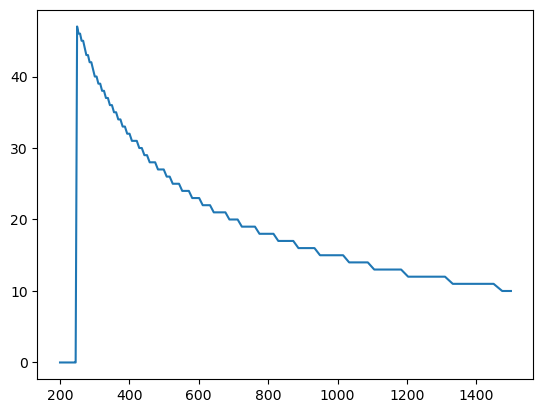

In [116]:
ax=plt.gca()
P=np.logspace(np.log10(200),np.log10(1500),120)
E=power_estimate(4000*np.ones(np.shape(P)),P)*1.0e-3;
ax.plot(P,E*1e3)
plt.show()

In [76]:
power_estimate(beam_ens[-20],ph_ens[-30])

array(2.997546e-05)

442.3675943094923

## energy density

/lscratch/dcesar/tmp/ipykernel_3255985/1863306586.py:13: RuntimeWarning: invalid value encountered in sqrt
  Kgen=np.sqrt(2*gamma0**2*plam/lamU-1)


Text(0.5, 1.0, 'LCLS-II w/ 30 56 mm undulators')

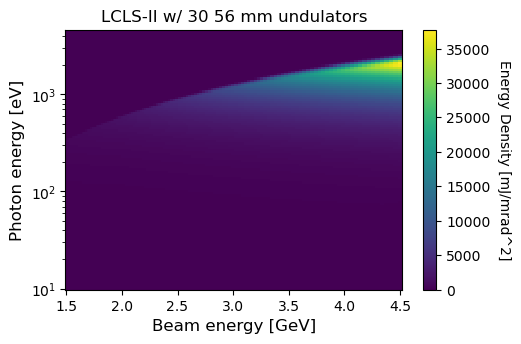

In [108]:
fig = plt.figure(num=1,figsize=[3.375*1.61,3.375])
fig.clf()
ax=plt.subplot(1,1,1)

@np.vectorize
def power_estimate(beamEnergy,phEnergy):
    gamma0=beamEnergy/0.511
    delgamma=1.1/0.511
    current=1.35e3
    emittance=0.27*1e-6
    plam=1240e-9/phEnergy
    lamU=0.056
    Kgen=np.sqrt(2*gamma0**2*plam/lamU-1)
    if Kgen>9.21/np.sqrt(2):
        return 0
    if Kgen <0.025/np.sqrt(2):
        return 0
    
    L=4.4;
    Bp=3.336 #per GeV in [T m];
    Bdz=np.min([3,Bp*(gamma0*0.511/1000)*2/L-0.1]); #tesla
    f=Bp*(gamma0*0.511/1000)/Bdz
    k=2*f/L
    beta1=L*k*(k+1)/np.sqrt(k**2-1)
    beta2=L*k*(k-1)/np.sqrt(k**2-1)
    sigBeam=np.sqrt(np.sqrt(beta1*beta2)*emittance/gamma0)
    MX=analysis.MingXie(Kgen,2*np.pi/lamU,gamma0,delgamma/gamma0,current,sigBeam,emittance,plam,0)
    Lg=MX['Lg']
    p=power(MX['Psat'],gl=Lg,und_len=3.4*30,sat_gl=20,postamp=2.5)/(div(plam,Lg,sigBeam))**2
    if np.isnan(p):
        p=0
    return p
    

ax=plt.gca()
ph_ens=np.logspace(np.log10(10),np.log10(4500),120)
beam_ens=np.logspace(np.log10(1500),np.log10(4500),120);
[B,P]=np.meshgrid(beam_ens,ph_ens,indexing='ij')
E=power_estimate(B,P)*50e-15*1e3*(1e-6);
p=ax.pcolormesh(B/1000,P,E)
cbar=plt.colorbar(p)
cbar.set_label('Energy Density [mJ/mrad^2]', rotation=270, labelpad=15)
ax.set_yscale('log')
#ax.set_xscale('log')
ax.set_xlabel('Beam energy [GeV]',fontsize=12)
ax.set_ylabel('Photon energy [eV]',fontsize=12)
ax.set_title('LCLS-II w/ 30 56 mm undulators')

In [39]:
np.max(E)

2.4722295802898646

/lscratch/dcesar/tmp/ipykernel_3255985/2615415659.py:13: RuntimeWarning: invalid value encountered in sqrt
  Kgen=np.sqrt(2*gamma0**2*plam/lamU-1)


Text(0.5, 1.0, 'LCLS-II w/ 21 39 mm undulators')

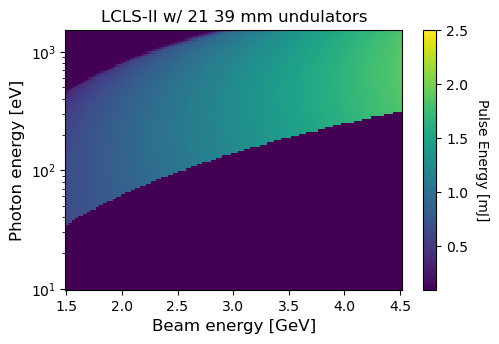

In [42]:
fig = plt.figure(num=1,figsize=[3.375*1.61,3.375])
fig.clf()
ax=plt.subplot(1,1,1)

@np.vectorize
def power_estimate(beamEnergy,phEnergy):
    gamma0=beamEnergy/0.511
    delgamma=1.1/0.511
    current=1.35e3
    emittance=0.27*1e-6
    plam=1240e-9/phEnergy
    lamU=0.039
    Kgen=np.sqrt(2*gamma0**2*plam/lamU-1)
    if Kgen>5.44/np.sqrt(2):
        return 0
    if Kgen <0.25/np.sqrt(2):
        return 0
    
    L=4.4;
    Bp=3.336 #per GeV in [T m];
    Bdz=np.min([3,Bp*(gamma0*0.511/1000)*2/L-0.1]); #tesla
    f=Bp*(gamma0*0.511/1000)/Bdz
    k=2*f/L
    beta1=L*k*(k+1)/np.sqrt(k**2-1)
    beta2=L*k*(k-1)/np.sqrt(k**2-1)
    sigBeam=np.sqrt(np.sqrt(beta1*beta2)*emittance/gamma0)
    MX=analysis.MingXie(Kgen,2*np.pi/lamU,gamma0,delgamma/gamma0,current,sigBeam,emittance,plam,0)
    Lg=MX['Lg']
    p=power(MX['Psat'],gl=Lg,und_len=3.4*21,sat_gl=20,postamp=2.5)
    if np.isnan(p):
        p=0
    return p
    

ax=plt.gca()
ph_ens=np.logspace(np.log10(10),np.log10(1500),120)
beam_ens=np.logspace(np.log10(1500),np.log10(4500),120);
[B,P]=np.meshgrid(beam_ens,ph_ens,indexing='ij')
E=power_estimate(B,P)*50e-15*1e3;
p=ax.pcolormesh(B/1000,P,E,vmin=0.1,vmax=2.5)
cbar=plt.colorbar(p)
cbar.set_label('Pulse Energy [mJ]', rotation=270, labelpad=15)
ax.set_yscale('log')
#ax.set_xscale('log')
ax.set_xlabel('Beam energy [GeV]',fontsize=12)
ax.set_ylabel('Photon energy [eV]',fontsize=12)
ax.set_title('LCLS-II w/ 21 39 mm undulators')

## Normal Conducting

/lscratch/dcesar/tmp/ipykernel_3587069/1324047290.py:19: RuntimeWarning: invalid value encountered in sqrt
  Kgen=np.sqrt(2*gamma0**2*plam/lamU-1)
/lscratch/dcesar/tmp/ipykernel_3587069/1324047290.py:88: RuntimeWarning: invalid value encountered in sqrt
  Kgen=np.sqrt(2*gamma0**2*plam/lamU-1)


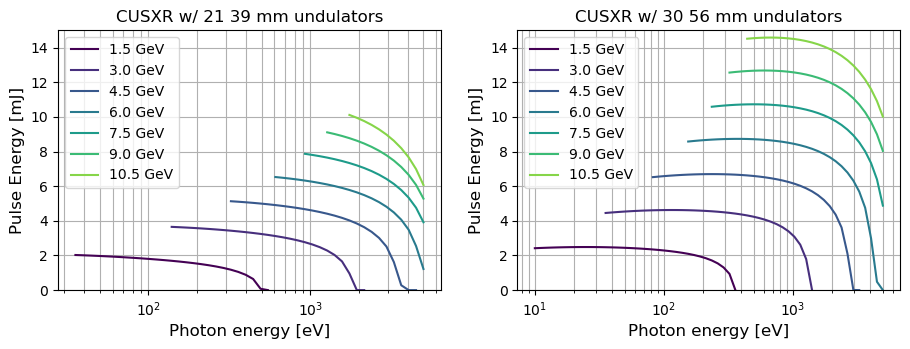

In [667]:
fig = plt.figure(num=1,figsize=[3.375*1.61*2,3.375])
fig.clf()
ax=plt.subplot(1,2,1)

def int_MX(ts,cur,mxp):
    MX=analysis.MingXie(mxp[0],mxp[1],mxp[2],mxp[3],cur,mxp[5],mxp[6],mxp[7],mxp[8])
    Lgs=MX['Lg']
    psats=MX['Psat']
    return np.trapz(power(psats,gl=Lgs,und_len=3.4*21,sat_gl=21,postamp=2.25),ts)

@np.vectorize
def pow_estimate(beamEnergy,phEnergy):
    gamma0=beamEnergy/0.511
    delgamma=2/0.511
    current=3.5e3
    emittance=0.45*1e-6
    plam=1240e-9/phEnergy
    lamU=0.039
    Kgen=np.sqrt(2*gamma0**2*plam/lamU-1)
    if Kgen>5.44/np.sqrt(2):
        return 0
    
    L=4.4;
    Bp=3.336 #per GeV in [T m];
    Bdz=np.min([3,Bp*(gamma0*0.511/1000)*2/L-0.1]);
    f=Bp*(gamma0*0.511/1000)/Bdz
    k=2*f/L
    if (k**2-1)<=0:
        return 0
    beta1=L*k*(k+1)/np.sqrt(k**2-1)
    beta2=L*k*(k-1)/np.sqrt(k**2-1)
    sigBeam=np.sqrt(np.sqrt(beta1*beta2)*emittance/gamma0)
    ts=np.linspace(-100,100,500);
    cur=current*np.exp(-0.5*(ts/20)**2)

    p=int_MX(ts*1e-15,cur,[Kgen,2*np.pi/lamU,gamma0,delgamma/gamma0,current,sigBeam,emittance,plam,0])
    if np.isnan(p):
        p=0
    return p
    

ax=plt.gca()
ph_ens=np.logspace(np.log10(10),np.log10(5000),60)
beam_ens=np.arange(1500,10600,1500)#np.logspace(np.log10(1500),np.log10(4500),5);
[B,P]=np.meshgrid(beam_ens,ph_ens,indexing='ij')
En = np.empty(B.shape)
for i in range(B.shape[0]):
    for j in range(B.shape[1]):
        En[i, j] = pow_estimate(B[i, j], P[i, j]) * 1e3
for ii in range(B.shape[0]):
    mask=En[ii,:]!=0;
    p=ax.plot(ph_ens[mask],(En[ii,mask]),color=cm.viridis((beam_ens[ii]-1500)/11000),label='{:2.1f} GeV'.format(beam_ens[ii]/1000))

#sm = plt.cm.ScalarMappable(cmap=cm.viridis, norm=cm.viridis.N)
#sm.set_array([])  # Only needed for the colorbar
#cbar = fig.colorbar(sm, ax=ax, boundaries=levels, ticks=levels, spacing='proportional')
#cbar.set_label('Beam Energy Bands')

#ax.set_yscale('log')
ax.set_xscale('log')
ax.set_ylabel('Pulse Energy [mJ]',fontsize=12)
ax.set_xlabel('Photon energy [eV]',fontsize=12)
ax.set_title('CUSXR w/ 21 39 mm undulators')
ax.grid(which='both')
ax.set_ylim([0,15])
plt.legend()




def int_MX(ts,cur,mxp):
    MX=analysis.MingXie(mxp[0],mxp[1],mxp[2],mxp[3],cur,mxp[5],mxp[6],mxp[7],mxp[8])
    Lgs=MX['Lg']
    psats=MX['Psat']
    return np.trapz(power(psats,gl=Lgs,und_len=3.4*30,sat_gl=21,postamp=2.25),ts)


ax=plt.subplot(1,2,2)

@np.vectorize
def pow_estimate(beamEnergy,phEnergy):
    gamma0=beamEnergy/0.511
    delgamma=2/0.511
    current=3.5e3
    emittance=0.45*1e-6
    plam=1240e-9/phEnergy
    lamU=0.056
    Kgen=np.sqrt(2*gamma0**2*plam/lamU-1)
    if Kgen>9.22/np.sqrt(2):
        return 0
    
    L=4.4;
    Bp=3.336 #per GeV in [T m];
    Bdz=np.min([3,Bp*(gamma0*0.511/1000)*2/L-0.1]);
    f=Bp*(gamma0*0.511/1000)/Bdz
    k=2*f/L
    if (k**2-1)<=0:
        return 0
    beta1=L*k*(k+1)/np.sqrt(k**2-1)
    beta2=L*k*(k-1)/np.sqrt(k**2-1)
    sigBeam=np.sqrt(np.sqrt(beta1*beta2)*emittance/gamma0)
    ts=np.linspace(-100,100,500);
    cur=current*np.exp(-0.5*(ts/20)**2)

    p=int_MX(ts*1e-15,cur,[Kgen,2*np.pi/lamU,gamma0,delgamma/gamma0,current,sigBeam,emittance,plam,0])
    if np.isnan(p):
        p=0
    return p
    

ax=plt.gca()
En = np.empty(B.shape)
for i in range(B.shape[0]):
    for j in range(B.shape[1]):
        En[i, j] = pow_estimate(B[i, j], P[i, j]) * 1e3
for ii in range(B.shape[0]):
    mask=En[ii,:]!=0;
    p=ax.plot(ph_ens[mask],(En[ii,mask]),color=cm.viridis((beam_ens[ii]-1500)/11000),label='{:2.1f} GeV'.format(beam_ens[ii]/1000))

#sm = plt.cm.ScalarMappable(cmap=cm.viridis, norm=cm.viridis.N)
#sm.set_array([])  # Only needed for the colorbar
#cbar = fig.colorbar(sm, ax=ax, boundaries=levels, ticks=levels, spacing='proportional')
#cbar.set_label('Beam Energy Bands')

#ax.set_yscale('log')
ax.set_xscale('log')
ax.set_ylabel('Pulse Energy [mJ]',fontsize=12)
ax.set_xlabel('Photon energy [eV]',fontsize=12)
ax.set_title('CUSXR w/ 30 56 mm undulators')
ax.grid(which='both')
ax.set_ylim([0,15])
plt.legend()

plt.show()

/lscratch/dcesar/tmp/ipykernel_3587069/3079886906.py:19: RuntimeWarning: invalid value encountered in sqrt
  Kgen=np.sqrt(2*gamma0**2*plam/lamU-1)
/lscratch/dcesar/tmp/ipykernel_3587069/3079886906.py:97: RuntimeWarning: invalid value encountered in sqrt
  Kgen=np.sqrt(2*gamma0**2*plam/lamU-1)


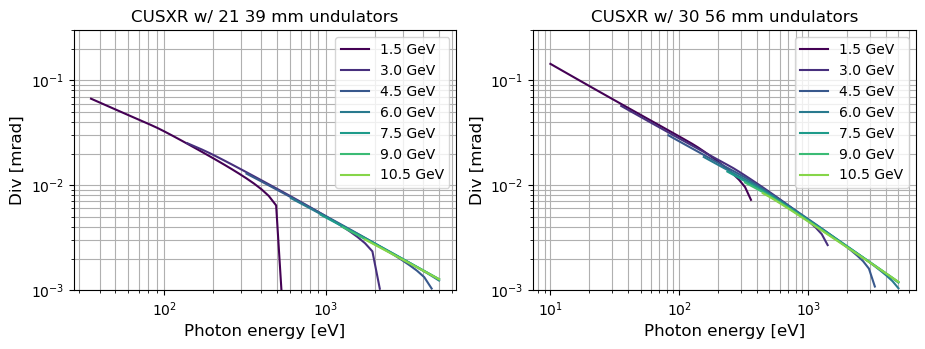

In [668]:
fig = plt.figure(num=1,figsize=[3.375*1.61*2,3.375])
fig.clf()
ax=plt.subplot(1,2,1)

def int_MX(ts,cur,mxp):
    MX=analysis.MingXie(mxp[0],mxp[1],mxp[2],mxp[3],cur,mxp[5],mxp[6],mxp[7],mxp[8])
    Lgs=MX['Lg']
    psats=MX['Psat']
    return np.trapz(power(psats,gl=Lgs,und_len=3.4*21,sat_gl=21,postamp=2.25),ts)

@np.vectorize
def div_estimate(beamEnergy,phEnergy):
    gamma0=beamEnergy/0.511
    delgamma=2/0.511
    current=3.5e3
    emittance=0.45*1e-6
    plam=1240e-9/phEnergy
    lamU=0.039
    Kgen=np.sqrt(2*gamma0**2*plam/lamU-1)
    if Kgen>5.44/np.sqrt(2):
        return 0
    
    L=4.4;
    Bp=3.336 #per GeV in [T m];
    Bdz=np.min([3,Bp*(gamma0*0.511/1000)*2/L-0.1]);
    f=Bp*(gamma0*0.511/1000)/Bdz
    k=2*f/L
    if (k**2-1)<=0:
        return 0
    beta1=L*k*(k+1)/np.sqrt(k**2-1)
    beta2=L*k*(k-1)/np.sqrt(k**2-1)
    sigBeam=np.sqrt(np.sqrt(beta1*beta2)*emittance/gamma0)
    ts=np.linspace(-100,100,500);
    cur=current*np.exp(-0.5*(ts/20)**2)

    MX=analysis.MingXie(Kgen,2*np.pi/lamU,gamma0,delgamma/gamma0,cur,sigBeam,emittance,plam,0)
    Lgs=MX['Lg']
    Psats=MX['Psat']
    ps=divsimple(plam,Lgs,sigBeam)
    jj=jv(0,Kgen**2/2/(1+Kgen**2))-jv(1,Kgen**2/2/(1+Kgen**2))
    Lg=lamU/4/np.pi*np.sqrt(gamma0*17e3/cur*(1+Kgen**2)/(Kgen**2*2*jj**2))
    sigr=np.sqrt(plam/4/np.pi*2*Lg)
    p2=plam/np.pi/(sigr*2)/2
    ps[p2<ps]=(ps[p2<ps]+p2[p2<ps])/2
    p=np.trapz(ps*power(Psats,gl=Lgs,und_len=3.4*30,sat_gl=21,postamp=2.25),ts)/np.trapz(power(Psats,gl=Lgs,und_len=3.4*30,sat_gl=21,postamp=2.25),ts)
    if np.isnan(p):
        p=0
    return p
    

ax=plt.gca()
ph_ens=np.logspace(np.log10(10),np.log10(5000),60)
beam_ens=np.arange(1500,10600,1500)#np.logspace(np.log10(1500),np.log10(4500),5);
[B,P]=np.meshgrid(beam_ens,ph_ens,indexing='ij')
En = np.empty(B.shape)
for i in range(B.shape[0]):
    for j in range(B.shape[1]):
        En[i, j] = div_estimate(B[i, j], P[i, j]) * 1e3
for ii in range(B.shape[0]):
    mask=En[ii,:]!=0;
    p=ax.plot(ph_ens[mask],(En[ii,mask]),color=cm.viridis((beam_ens[ii]-1500)/11000),label='{:2.1f} GeV'.format(beam_ens[ii]/1000))

#sm = plt.cm.ScalarMappable(cmap=cm.viridis, norm=cm.viridis.N)
#sm.set_array([])  # Only needed for the colorbar
#cbar = fig.colorbar(sm, ax=ax, boundaries=levels, ticks=levels, spacing='proportional')
#cbar.set_label('Beam Energy Bands')

ax.set_yscale('log')
ax.set_xscale('log')
ax.set_ylabel('Div [mrad]',fontsize=12)
ax.set_xlabel('Photon energy [eV]',fontsize=12)
ax.set_title('CUSXR w/ 21 39 mm undulators')
ax.grid(which='both')
ax.set_ylim([1e-3,0.3])
plt.legend()




def int_MX(ts,cur,mxp):
    MX=analysis.MingXie(mxp[0],mxp[1],mxp[2],mxp[3],cur,mxp[5],mxp[6],mxp[7],mxp[8])
    Lgs=MX['Lg']
    psats=MX['Psat']
    return np.trapz(power(psats,gl=Lgs,und_len=3.4*30,sat_gl=21,postamp=2.25),ts)


ax=plt.subplot(1,2,2)

@np.vectorize
def div_estimate(beamEnergy,phEnergy):
    gamma0=beamEnergy/0.511
    delgamma=2/0.511
    current=3.5e3
    emittance=0.45*1e-6
    plam=1240e-9/phEnergy
    lamU=0.056
    Kgen=np.sqrt(2*gamma0**2*plam/lamU-1)
    if Kgen>9.23/np.sqrt(2):
        return 0
    
    L=4.4;
    Bp=3.336 #per GeV in [T m];
    Bdz=np.min([3,Bp*(gamma0*0.511/1000)*2/L-0.1]);
    f=Bp*(gamma0*0.511/1000)/Bdz
    k=2*f/L
    if (k**2-1)<=0:
        return 0
    beta1=L*k*(k+1)/np.sqrt(k**2-1)
    beta2=L*k*(k-1)/np.sqrt(k**2-1)
    sigBeam=np.sqrt(np.sqrt(beta1*beta2)*emittance/gamma0)
    ts=np.linspace(-100,100,500);
    cur=current*np.exp(-0.5*(ts/20)**2)

    MX=analysis.MingXie(Kgen,2*np.pi/lamU,gamma0,delgamma/gamma0,cur,sigBeam,emittance,plam,0)
    Lgs=MX['Lg']
    Psats=MX['Psat']
    ps=divsimple(plam,Lgs,sigBeam)
    jj=jv(0,Kgen**2/2/(1+Kgen**2))-jv(1,Kgen**2/2/(1+Kgen**2))
    Lg=lamU/4/np.pi*np.sqrt(gamma0*17e3/cur*(1+Kgen**2)/(Kgen**2*2*jj**2))
    sigr=np.sqrt(plam/4/np.pi*2*Lg)
    p2=plam/np.pi/(sigr*2)/2
    ps[p2<ps]=(ps[p2<ps]+p2[p2<ps])/2
    p=np.trapz(ps*power(Psats,gl=Lgs,und_len=3.4*30,sat_gl=21,postamp=2.25),ts)/np.trapz(power(Psats,gl=Lgs,und_len=3.4*30,sat_gl=21,postamp=2.25),ts)
    if np.isnan(p):
        p=0
    return p
    

ax=plt.gca()
En = np.empty(B.shape)
for i in range(B.shape[0]):
    for j in range(B.shape[1]):
        En[i, j] = div_estimate(B[i, j], P[i, j]) * 1e3
for ii in range(B.shape[0]):
    mask=En[ii,:]!=0;
    p=ax.plot(ph_ens[mask],(En[ii,mask]),color=cm.viridis((beam_ens[ii]-1500)/11000),label='{:2.1f} GeV'.format(beam_ens[ii]/1000))

#sm = plt.cm.ScalarMappable(cmap=cm.viridis, norm=cm.viridis.N)
#sm.set_array([])  # Only needed for the colorbar
#cbar = fig.colorbar(sm, ax=ax, boundaries=levels, ticks=levels, spacing='proportional')
#cbar.set_label('Beam Energy Bands')

ax.set_yscale('log')
ax.set_xscale('log')
ax.set_ylabel('Div [mrad]',fontsize=12)
ax.set_xlabel('Photon energy [eV]',fontsize=12)
ax.set_title('CUSXR w/ 30 56 mm undulators')
ax.grid(which='both')
ax.set_ylim([1e-3,0.3])
plt.legend()

plt.show()

/lscratch/dcesar/tmp/ipykernel_3136133/1523642268.py:19: RuntimeWarning: invalid value encountered in sqrt
  Kgen=np.sqrt(2*gamma0**2*plam/lamU-1)
/lscratch/dcesar/tmp/ipykernel_3136133/1523642268.py:95: RuntimeWarning: invalid value encountered in sqrt
  Kgen=np.sqrt(2*gamma0**2*plam/lamU-1)


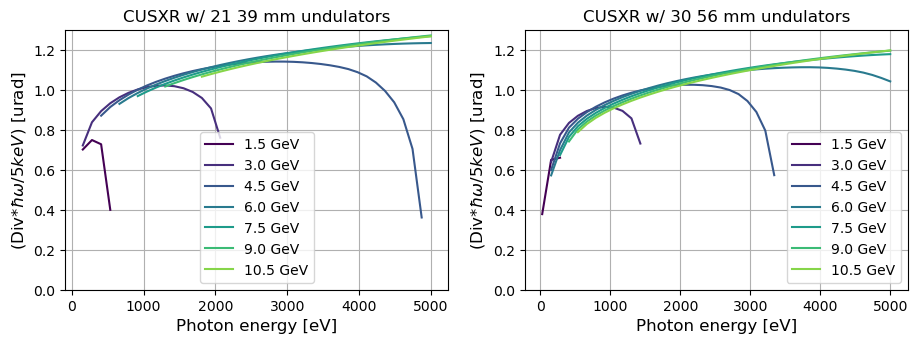

In [16]:
fig = plt.figure(num=1,figsize=[3.375*1.61*2,3.375])
fig.clf()
ax=plt.subplot(1,2,1)

def int_MX(ts,cur,mxp):
    MX=analysis.MingXie(mxp[0],mxp[1],mxp[2],mxp[3],cur,mxp[5],mxp[6],mxp[7],mxp[8])
    Lgs=MX['Lg']
    psats=MX['Psat']
    return np.trapz(power(psats,gl=Lgs,und_len=3.4*21,sat_gl=21,postamp=2.25),ts)

@np.vectorize
def div_estimate(beamEnergy,phEnergy):
    gamma0=beamEnergy/0.511
    delgamma=2/0.511
    current=3.5e3
    emittance=0.45*1e-6
    plam=1240e-9/phEnergy
    lamU=0.039
    Kgen=np.sqrt(2*gamma0**2*plam/lamU-1)
    if Kgen>5.44/np.sqrt(2):
        return 0
    
    L=4.4;
    Bp=3.336 #per GeV in [T m];
    Bdz=np.min([3,Bp*(gamma0*0.511/1000)*2/L-0.1]);
    f=Bp*(gamma0*0.511/1000)/Bdz
    k=2*f/L
    if (k**2-1)<=0:
        return 0
    beta1=L*k*(k+1)/np.sqrt(k**2-1)
    beta2=L*k*(k-1)/np.sqrt(k**2-1)
    sigBeam=np.sqrt(np.sqrt(beta1*beta2)*emittance/gamma0)
    ts=np.linspace(-100,100,500);
    cur=current*np.exp(-0.5*(ts/20)**2)

    MX=analysis.MingXie(Kgen,2*np.pi/lamU,gamma0,delgamma/gamma0,cur,sigBeam,emittance,plam,0)
    Lgs=MX['Lg']
    Psats=MX['Psat']
    ps=divsimple(plam,Lgs,sigBeam)
    jj=jv(0,Kgen**2/2/(1+Kgen**2))-jv(1,Kgen**2/2/(1+Kgen**2))
    Lg=lamU/4/np.pi*np.sqrt(gamma0*17e3/cur*(1+Kgen**2)/(Kgen**2*2*jj**2))
    sigr=np.sqrt(plam/4/np.pi*2*Lg)
    p2=plam/np.pi/(sigr*2)/2
    ps[p2<ps]=(ps[p2<ps]+p2[p2<ps])/2
    p=np.trapz(ps*power(Psats,gl=Lgs,und_len=3.4*30,sat_gl=21,postamp=2.25),ts)/np.trapz(power(Psats,gl=Lgs,und_len=3.4*30,sat_gl=21,postamp=2.25),ts)
    if np.isnan(p):
        p=0
    return p
    

ax=plt.gca()
ph_ens=np.linspace(25,5000,40)
beam_ens=np.arange(1500,10600,1500)#np.logspace(np.log10(1500),np.log10(4500),5);
[B,P]=np.meshgrid(beam_ens,ph_ens,indexing='ij')
En = np.empty(B.shape)
for i in range(B.shape[0]):
    for j in range(B.shape[1]):
        En[i, j] = div_estimate(B[i, j], P[i, j]) * 1e3
for ii in range(B.shape[0]):
    mask=En[ii,:]!=0;
    p=ax.plot(ph_ens[mask],1e3*(En[ii,mask]*ph_ens[mask]/5000),color=cm.viridis((beam_ens[ii]-1500)/11000),label='{:2.1f} GeV'.format(beam_ens[ii]/1000))

#sm = plt.cm.ScalarMappable(cmap=cm.viridis, norm=cm.viridis.N)
#sm.set_array([])  # Only needed for the colorbar
#cbar = fig.colorbar(sm, ax=ax, boundaries=levels, ticks=levels, spacing='proportional')
#cbar.set_label('Beam Energy Bands')

ax.set_ylabel('(Div$*\hbar\omega/5keV$) [urad]',fontsize=12)
ax.set_xlabel('Photon energy [eV]',fontsize=12)
ax.set_title('CUSXR w/ 21 39 mm undulators')
ax.grid(which='both')
ax.set_ylim([0,1.3])
plt.legend()




def int_MX(ts,cur,mxp):
    MX=analysis.MingXie(mxp[0],mxp[1],mxp[2],mxp[3],cur,mxp[5],mxp[6],mxp[7],mxp[8])
    Lgs=MX['Lg']
    psats=MX['Psat']
    return np.trapz(power(psats,gl=Lgs,und_len=3.4*30,sat_gl=21,postamp=2.25),ts)


ax=plt.subplot(1,2,2)

@np.vectorize
def div_estimate(beamEnergy,phEnergy):
    gamma0=beamEnergy/0.511
    delgamma=2/0.511
    current=3.5e3
    emittance=0.45*1e-6
    plam=1240e-9/phEnergy
    lamU=0.056
    Kgen=np.sqrt(2*gamma0**2*plam/lamU-1)
    if Kgen>9.23/np.sqrt(2):
        return 0
    
    L=4.4;
    Bp=3.336 #per GeV in [T m];
    Bdz=np.min([3,Bp*(gamma0*0.511/1000)*2/L-0.1]);
    f=Bp*(gamma0*0.511/1000)/Bdz
    k=2*f/L
    if (k**2-1)<=0:
        return 0
    beta1=L*k*(k+1)/np.sqrt(k**2-1)
    beta2=L*k*(k-1)/np.sqrt(k**2-1)
    sigBeam=np.sqrt(np.sqrt(beta1*beta2)*emittance/gamma0)
    ts=np.linspace(-100,100,500);
    cur=current*np.exp(-0.5*(ts/20)**2)

    MX=analysis.MingXie(Kgen,2*np.pi/lamU,gamma0,delgamma/gamma0,cur,sigBeam,emittance,plam,0)
    Lgs=MX['Lg']
    Psats=MX['Psat']
    ps=divsimple(plam,Lgs,sigBeam)
    jj=jv(0,Kgen**2/2/(1+Kgen**2))-jv(1,Kgen**2/2/(1+Kgen**2))
    Lg=lamU/4/np.pi*np.sqrt(gamma0*17e3/cur*(1+Kgen**2)/(Kgen**2*2*jj**2))
    sigr=np.sqrt(plam/4/np.pi*2*Lg)
    p2=plam/np.pi/(sigr*2)/2
    ps[p2<ps]=(ps[p2<ps]+p2[p2<ps])/2
    p=np.trapz(ps*power(Psats,gl=Lgs,und_len=3.4*30,sat_gl=21,postamp=2.25),ts)/np.trapz(power(Psats,gl=Lgs,und_len=3.4*30,sat_gl=21,postamp=2.25),ts)
    if np.isnan(p):
        p=0
    return p
    

ax=plt.gca()
En = np.empty(B.shape)
for i in range(B.shape[0]):
    for j in range(B.shape[1]):
        En[i, j] = div_estimate(B[i, j], P[i, j]) * 1e3
for ii in range(B.shape[0]):
    mask=En[ii,:]!=0;
    p=ax.plot(ph_ens[mask],1e3*(En[ii,mask]*ph_ens[mask]/5000),color=cm.viridis((beam_ens[ii]-1500)/11000),label='{:2.1f} GeV'.format(beam_ens[ii]/1000))

#sm = plt.cm.ScalarMappable(cmap=cm.viridis, norm=cm.viridis.N)
#sm.set_array([])  # Only needed for the colorbar
#cbar = fig.colorbar(sm, ax=ax, boundaries=levels, ticks=levels, spacing='proportional')
#cbar.set_label('Beam Energy Bands')


ax.set_ylabel('(Div$*\hbar\omega/5keV$) [urad]',fontsize=12)
ax.set_xlabel('Photon energy [eV]',fontsize=12)
ax.set_title('CUSXR w/ 30 56 mm undulators')
ax.grid(which='both')
ax.set_ylim([0,1.3])
plt.legend()

plt.show()

/lscratch/dcesar/tmp/ipykernel_3136133/4051888089.py:34: RuntimeWarning: invalid value encountered in sqrt
  Kgen=np.sqrt(2*gamma0**2*plam/lamU-1)
/lscratch/dcesar/tmp/ipykernel_3136133/4051888089.py:51: RuntimeWarning: invalid value encountered in sqrt
  Kgen2=np.sqrt(2*gamma0**2*plam/lamU2-1)


Text(0.5, 1.0, 'Normal Conducting w/9 56mm + 21 39 mm undulators')

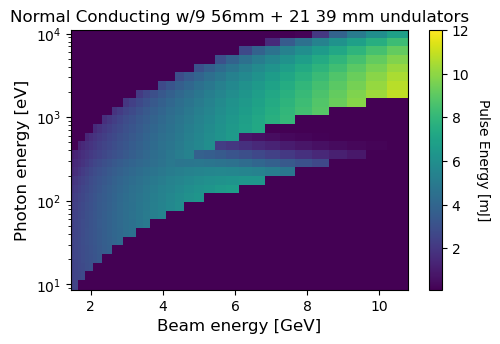

In [61]:
fig = plt.figure(num=1,figsize=[3.375*1.61,3.375])
fig.clf()
ax=plt.subplot(1,1,1)

def int_mixed_MX(ts,cur,mxp1,mxp2,stage1only=False):
    mxp=mxp1
    MX1=analysis.MingXie(mxp[0],mxp[1],mxp[2],mxp[3],cur,mxp[5],mxp[6],mxp[7],mxp[8])
    Lgs1=MX1['Lg']
    psats1=MX1['Psat']

    p1=np.trapz(power(psats1,gl=Lgs1,und_len=3.4*9,sat_gl=21,postamp=2.25),ts)
    if stage1only:
        return p1

    mxp=mxp2
    MX2=analysis.MingXie(mxp[0],mxp[1],mxp[2],mxp[3],cur,mxp[5],mxp[6],mxp[7],mxp[8])
    Lgs2=MX2['Lg']
    psats2=MX2['Psat']

    # Ok. If stage 1 is only in exp regime, then we need only add a coresponding number of undulators
    lens=(3.4*9)/Lgs1*Lgs2 
    p=np.trapz(power(psats2,gl=Lgs2,und_len=3.4*30+lens,sat_gl=21,postamp=2.25),ts)
    # return max of p and single stage
    return max([p,p1])


def mixed_power_estimate(beamEnergy,phEnergy):
    gamma0=beamEnergy/0.511
    delgamma=2/0.511
    current=3.5e3
    emittance=0.45*1e-6
    plam=1240e-9/phEnergy
    lamU=0.056
    Kgen=np.sqrt(2*gamma0**2*plam/lamU-1)
    if Kgen>9.21/np.sqrt(2):
        return 0
    L=4.4;
    Bp=3.336 #per GeV in [T m];
    Bdz=np.min([3,Bp*(gamma0*0.511/1000)*2/L-0.1]);
    f=Bp*(gamma0*0.511/1000)/Bdz
    k=2*f/L
    if (k**2-1)<=0:
        return 0
    beta1=L*k*(k+1)/np.sqrt(k**2-1)
    beta2=L*k*(k-1)/np.sqrt(k**2-1)
    sigBeam=np.sqrt(np.sqrt(beta1*beta2)*emittance/gamma0)
    ts=np.linspace(-100,100,500);
    cur=current*np.exp(-0.5*(ts/20)**2)

    lamU2=0.039
    Kgen2=np.sqrt(2*gamma0**2*plam/lamU2-1)
    if Kgen2>5.44/np.sqrt(2):
        p=int_mixed_MX(ts*1e-15,cur,[Kgen,2*np.pi/lamU,gamma0,delgamma/gamma0,current,sigBeam,emittance,plam,0],[Kgen2,2*np.pi/lamU2,gamma0,delgamma/gamma0,current,sigBeam,emittance,plam,0],stage1only=True)
    else:
        p=int_mixed_MX(ts*1e-15,cur,[Kgen,2*np.pi/lamU,gamma0,delgamma/gamma0,current,sigBeam,emittance,plam,0],[Kgen2,2*np.pi/lamU2,gamma0,delgamma/gamma0,current,sigBeam,emittance,plam,0])

    if np.isnan(p):
        return 0
    return p
    

ax=plt.gca()
ph_ens=np.logspace(np.log10(10),np.log10(10000),30)
beam_ens=np.logspace(np.log10(1500),np.log10(10500),35);
[B,P]=np.meshgrid(beam_ens,ph_ens,indexing='ij')
En = np.empty(B.shape)
for i in range(B.shape[0]):
    for j in range(B.shape[1]):
        En[i, j] = mixed_power_estimate(B[i, j], P[i, j]) * 1e3
p=ax.pcolormesh(B/1000,P,En,vmin=0.1,vmax=12)
cbar=plt.colorbar(p)
cbar.set_label('Pulse Energy [mJ]', rotation=270, labelpad=15)
ax.set_yscale('log')
#ax.set_xscale('log')
ax.set_xlabel('Beam energy [GeV]',fontsize=12)
ax.set_ylabel('Photon energy [eV]',fontsize=12)
ax.set_title('Normal Conducting w/9 56mm + 21 39 mm undulators')

In [58]:
np.max(En)

2.4543503575264345

/lscratch/dcesar/tmp/ipykernel_3136133/4051888089.py:34: RuntimeWarning: invalid value encountered in sqrt
  Kgen=np.sqrt(2*gamma0**2*plam/lamU-1)
/lscratch/dcesar/tmp/ipykernel_3136133/4051888089.py:51: RuntimeWarning: invalid value encountered in sqrt
  Kgen2=np.sqrt(2*gamma0**2*plam/lamU2-1)


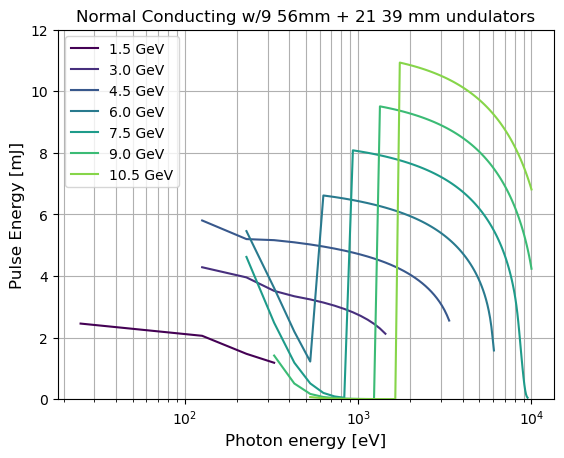

In [62]:
ax=plt.gca()

ph_ens=np.linspace(25,10000,100)
beam_ens=np.arange(1500,10600,1500)#np.logspace(np.log10(1500),np.log10(4500),5);
[B,P]=np.meshgrid(beam_ens,ph_ens,indexing='ij')
En = np.empty(B.shape)
for i in range(B.shape[0]):
    for j in range(B.shape[1]):
        En[i, j] = mixed_power_estimate(B[i, j], P[i, j]) * 1e3
        
for ii in range(B.shape[0]):
    mask=En[ii,:]!=0;
    p=ax.plot(ph_ens[mask],(En[ii,mask]),color=cm.viridis((beam_ens[ii]-1500)/11000),label='{:2.1f} GeV'.format(beam_ens[ii]/1000))

#sm = plt.cm.ScalarMappable(cmap=cm.viridis, norm=cm.viridis.N)
#sm.set_array([])  # Only needed for the colorbar
#cbar = fig.colorbar(sm, ax=ax, boundaries=levels, ticks=levels, spacing='proportional')
#cbar.set_label('Beam Energy Bands')

#ax.set_yscale('log')
ax.set_xscale('log')
ax.set_ylabel('Pulse Energy [mJ]',fontsize=12)
ax.set_xlabel('Photon energy [eV]',fontsize=12)
ax.set_title('Normal Conducting w/9 56mm + 21 39 mm undulators')
ax.grid(which='both')
ax.set_ylim([0,12])
plt.legend()

plt.show()

In [60]:
np.max(En)

10.902064564398039

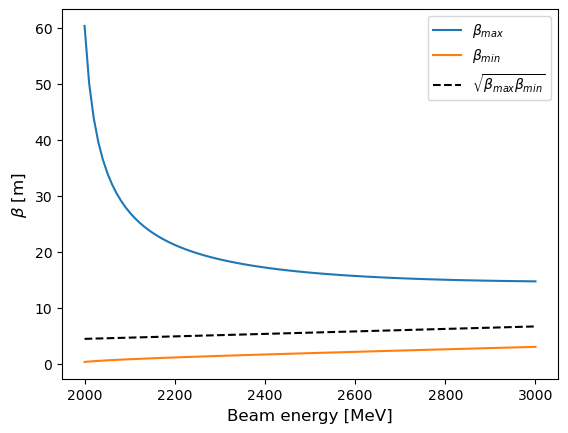

In [44]:
ax=plt.gca()
ens=np.linspace(2,3,100)
beta1s=[]
beta2s=[]
for e in ens:
    gamma0=e*1000/0.511
    L=4.4;
    Bp=3.336 #per GeV in [T m];
    Bdz=3
    f=Bp*(gamma0*0.511/1000)/Bdz
    k=2*f/L
    if (k**2-1)<=0:
        continue
    beta1=L*k*(k+1)/np.sqrt(k**2-1)
    beta2=L*k*(k-1)/np.sqrt(k**2-1)
    beta1s.append(beta1)
    beta2s.append(beta2)
beta1s=np.array(beta1s)
beta2s=np.array(beta2s)
ax.plot(ens*1000,beta1s,label='$\\beta_{max}$')
ax.plot(ens*1000,beta2s,label='$\\beta_{min}$')
ax.plot(ens*1000,np.sqrt(beta1s*beta2s),'k--',label='$\sqrt{\\beta_{max}\\beta_{min}}$')
plt.legend()
ax.set_ylabel('$\\beta$ [m]',fontsize=12)
ax.set_xlabel('Beam energy [MeV]',fontsize=12)
plt.show()

## Install schedule

In [9]:
num39=np.array([21,21,21,21,21,21,20,19,18,17,17,17,16,15,14,13,13,13,12,11,10,9 ,8 ,7, 6, 5, 4, 3, 2, 1, 0])
num56=np.array([0 , 1, 2, 3, 4, 5, 6, 7, 8, 9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30])

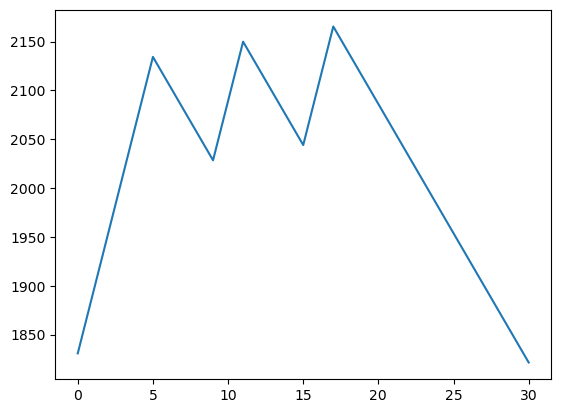

In [10]:
ax=plt.gca()
ax.plot(num39*3.4/0.039+num56*3.4/0.056)

maxsat 1438684738.2190332
max1 0.0002649737830254883
max2sat 1935491824.3867831
max2 0.0003384368685200993


Text(0.5, 1.0, '1080eV output during undulator exchange')

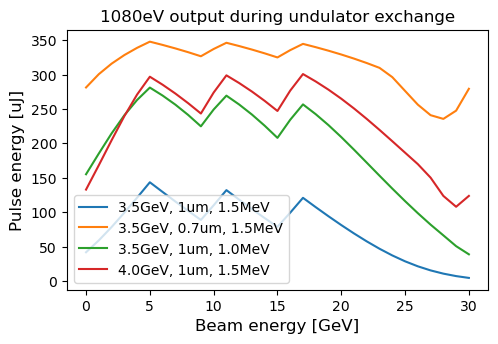

In [109]:
fig = plt.figure(num=1,figsize=[3.375*1.61,3.375])
fig.clf()
ax=plt.subplot(1,1,1)

def max_MX(ts,cur,mxp1,mxp2):
    mxp=mxp1
    MX1=analysis.MingXie(mxp[0],mxp[1],mxp[2],mxp[3],cur,mxp[5],mxp[6],mxp[7],mxp[8])
    Lgs1=MX1['Lg']
    psats1=MX1['Psat']
    p1=power(psats1,gl=Lgs1,und_len=3.4*45,sat_gl=21,postamp=2.25)
    print('maxsat',np.max(psats1))
    print('max1',np.trapz(p1,ts))
    mxp=mxp2
    MX2=analysis.MingXie(mxp[0],mxp[1],mxp[2],mxp[3],cur,mxp[5],mxp[6],mxp[7],mxp[8])
    Lgs2=MX2['Lg']
    psats2=MX2['Psat']
    p1=power(psats2,gl=Lgs2,und_len=3.4*45,sat_gl=21,postamp=2.25)
    print('max2sat',np.max(psats2))
    print('max2',np.trapz(p1,ts))
    
def int_mixed_MX(ts,cur,mxp1,mxp2,n1,n2,stage1only=False):
    mxp=mxp1
    MX1=analysis.MingXie(mxp[0],mxp[1],mxp[2],mxp[3],cur,mxp[5],mxp[6],mxp[7],mxp[8])
    Lgs1=MX1['Lg']
    psats1=MX1['Psat']

    p1=power(psats1,gl=Lgs1,und_len=3.4*n1,sat_gl=21,postamp=2.25)
    if stage1only:
        return np.trapz(p1,ts)

    mxp=mxp2
    MX2=analysis.MingXie(mxp[0],mxp[1],mxp[2],mxp[3],cur,mxp[5],mxp[6],mxp[7],mxp[8])
    Lgs2=MX2['Lg']
    psats2=MX2['Psat']

    # Ok. If stage 1 is only in exp regime, then we need only add a coresponding number of undulators to match # gain lengths. Otherwise, we probably need some kind of averaging of 
    lens=(3.4*n1)/Lgs1*Lgs2 
    p=power(psats2,gl=Lgs2,und_len=3.4*n2+lens,sat_gl=21,postamp=2.25)
    len1=(3.4*n1)/Lgs1-21
    #len1[len1<0]=0
    len2=3.4*n2/Lgs2
    p[len1>0]=p1[len1>0]*len1[len1>0]/(len1[len1>0]+len2[len1>0])+p[len1>0]*len2[len1>0]/(len1[len1>0]+len2[len1>0]);
    p[p1>p]=p1[p1>p]
    p=np.trapz(p,ts)
    
    return p


def mixed_power_estimate(beamEnergy,phEnergy,n1,n2,verbose=False,emi=1,dg=1.5):
    gamma0=beamEnergy/0.511
    delgamma=dg/0.511
    current=1.1e3
    emittance=emi*1e-6
    plam=1240e-9/phEnergy
    lamU=0.056
    Kgen=np.sqrt(2*gamma0**2*plam/lamU-1)
    if Kgen>9.21/np.sqrt(2):
        return 0
    L=4.4;
    Bp=3.336 #per GeV in [T m];
    Bdz=np.min([3,Bp*(gamma0*0.511/1000)*2/L-0.1]);
    f=Bp*(gamma0*0.511/1000)/Bdz
    k=2*f/L
    if (k**2-1)<=0:
        return 0
    beta1=L*k*(k+1)/np.sqrt(k**2-1)
    beta2=L*k*(k-1)/np.sqrt(k**2-1)
    sigBeam=np.sqrt(np.sqrt(beta1*beta2)*emittance/gamma0)
    ts=np.linspace(-100,100,500);
    cur=current*np.exp(-0.5*(ts/12)**2)
    lamU2=0.039
    Kgen2=np.sqrt(2*gamma0**2*plam/lamU2-1)
    if verbose:
        max_MX(ts*1e-15,cur,[Kgen,2*np.pi/lamU,gamma0,delgamma/gamma0,current,sigBeam,emittance,plam,0],[Kgen2,2*np.pi/lamU2,gamma0,delgamma/gamma0,current,sigBeam,emittance,plam,0])
        return 0
    if Kgen2>5.44/np.sqrt(2):
        p=int_mixed_MX(ts*1e-15,cur,[Kgen,2*np.pi/lamU,gamma0,delgamma/gamma0,current,sigBeam,emittance,plam,0],[Kgen2,2*np.pi/lamU2,gamma0,delgamma/gamma0,current,sigBeam,emittance,plam,0],n1,n2,stage1only=True)
        print('Kgen2 large')
    else:
        p=int_mixed_MX(ts*1e-15,cur,[Kgen,2*np.pi/lamU,gamma0,delgamma/gamma0,current,sigBeam,emittance,plam,0],[Kgen2,2*np.pi/lamU2,gamma0,delgamma/gamma0,current,sigBeam,emittance,plam,0],n1,n2)
    if np.isnan(p):
        return 0
    return p
    
mixed_power_estimate(beam_en, ph_en,num56[i],num39[i],verbose=True)

ax=plt.gca()
ph_en=1080;
beam_en=3500;
En = np.empty(num56.shape)
for i in range(num56.shape[0]):
    En[i] = mixed_power_estimate(beam_en, ph_en,num56[i],num39[i]) * 1e6
p=ax.plot(En,label='3.5GeV, 1um, 1.5MeV')

for i in range(num56.shape[0]):
    En[i] = mixed_power_estimate(beam_en, ph_en,num56[i],num39[i],emi=0.7) * 1e6
p=ax.plot(En,label='3.5GeV, 0.7um, 1.5MeV')

for i in range(num56.shape[0]):
    En[i] = mixed_power_estimate(beam_en, ph_en,num56[i],num39[i],dg=1.0) * 1e6
p=ax.plot(En,label='3.5GeV, 1um, 1.0MeV')

for i in range(num56.shape[0]):
    En[i] = mixed_power_estimate(4000, ph_en,num56[i],num39[i]) * 1e6
p=ax.plot(En,label='4.0GeV, 1um, 1.5MeV')
#cbar=plt.colorbar(p)
#cbar.set_label('Pulse Energy [mJ]', rotation=270, labelpad=15)
#ax.set_yscale('log')
#ax.set_xscale('log')
plt.legend()
ax.set_xlabel('Beam energy [GeV]',fontsize=12)
ax.set_ylabel('Pulse energy [uJ]',fontsize=12)
ax.set_title('1080eV output during undulator exchange')

maxsat 1438684738.2190332
max1 0.0002649737830254883
max2sat 1935491824.3867831
max2 0.0003384368685200993


Text(0.5, 1.0, '500eV output during undulator exchange')

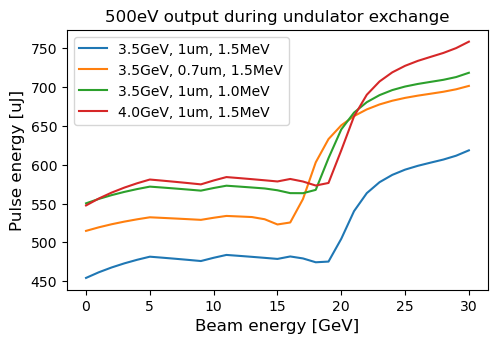

In [110]:
fig = plt.figure(num=1,figsize=[3.375*1.61,3.375])
fig.clf()
ax=plt.subplot(1,1,1)

def max_MX(ts,cur,mxp1,mxp2):
    mxp=mxp1
    MX1=analysis.MingXie(mxp[0],mxp[1],mxp[2],mxp[3],cur,mxp[5],mxp[6],mxp[7],mxp[8])
    Lgs1=MX1['Lg']
    psats1=MX1['Psat']
    p1=power(psats1,gl=Lgs1,und_len=3.4*45,sat_gl=21,postamp=2.25)
    print('maxsat',np.max(psats1))
    print('max1',np.trapz(p1,ts))
    mxp=mxp2
    MX2=analysis.MingXie(mxp[0],mxp[1],mxp[2],mxp[3],cur,mxp[5],mxp[6],mxp[7],mxp[8])
    Lgs2=MX2['Lg']
    psats2=MX2['Psat']
    p1=power(psats2,gl=Lgs2,und_len=3.4*45,sat_gl=21,postamp=2.25)
    print('max2sat',np.max(psats2))
    print('max2',np.trapz(p1,ts))
    
def int_mixed_MX(ts,cur,mxp1,mxp2,n1,n2,stage1only=False):
    mxp=mxp1
    MX1=analysis.MingXie(mxp[0],mxp[1],mxp[2],mxp[3],cur,mxp[5],mxp[6],mxp[7],mxp[8])
    Lgs1=MX1['Lg']
    psats1=MX1['Psat']

    p1=power(psats1,gl=Lgs1,und_len=3.4*n1,sat_gl=21,postamp=2.25)
    if stage1only:
        return np.trapz(p1,ts)

    mxp=mxp2
    MX2=analysis.MingXie(mxp[0],mxp[1],mxp[2],mxp[3],cur,mxp[5],mxp[6],mxp[7],mxp[8])
    Lgs2=MX2['Lg']
    psats2=MX2['Psat']

    # Ok. If stage 1 is only in exp regime, then we need only add a coresponding number of undulators to match # gain lengths. Otherwise, we probably need some kind of averaging of 
    lens=(3.4*n1)/Lgs1*Lgs2 
    p=power(psats2,gl=Lgs2,und_len=3.4*n2+lens,sat_gl=21,postamp=2.25)
    len1=(3.4*n1)/Lgs1-21
    #len1[len1<0]=0
    len2=3.4*n2/Lgs2
    p[len1>0]=p1[len1>0]*len1[len1>0]/(len1[len1>0]+len2[len1>0])+p[len1>0]*len2[len1>0]/(len1[len1>0]+len2[len1>0]);
    p[p1>p]=p1[p1>p]
    p=np.trapz(p,ts)
    
    return p


def mixed_power_estimate(beamEnergy,phEnergy,n1,n2,verbose=False,emi=1,dg=1.5):
    gamma0=beamEnergy/0.511
    delgamma=dg/0.511
    current=1.1e3
    emittance=emi*1e-6
    plam=1240e-9/phEnergy
    lamU=0.056
    Kgen=np.sqrt(2*gamma0**2*plam/lamU-1)
    if Kgen>9.21/np.sqrt(2):
        return 0
    L=4.4;
    Bp=3.336 #per GeV in [T m];
    Bdz=np.min([3,Bp*(gamma0*0.511/1000)*2/L-0.1]);
    f=Bp*(gamma0*0.511/1000)/Bdz
    k=2*f/L
    if (k**2-1)<=0:
        return 0
    beta1=L*k*(k+1)/np.sqrt(k**2-1)
    beta2=L*k*(k-1)/np.sqrt(k**2-1)
    sigBeam=np.sqrt(np.sqrt(beta1*beta2)*emittance/gamma0)
    ts=np.linspace(-100,100,500);
    cur=current*np.exp(-0.5*(ts/12)**2)
    lamU2=0.039
    Kgen2=np.sqrt(2*gamma0**2*plam/lamU2-1)
    if verbose:
        max_MX(ts*1e-15,cur,[Kgen,2*np.pi/lamU,gamma0,delgamma/gamma0,current,sigBeam,emittance,plam,0],[Kgen2,2*np.pi/lamU2,gamma0,delgamma/gamma0,current,sigBeam,emittance,plam,0])
        return 0
    if Kgen2>5.44/np.sqrt(2):
        p=int_mixed_MX(ts*1e-15,cur,[Kgen,2*np.pi/lamU,gamma0,delgamma/gamma0,current,sigBeam,emittance,plam,0],[Kgen2,2*np.pi/lamU2,gamma0,delgamma/gamma0,current,sigBeam,emittance,plam,0],n1,n2,stage1only=True)
        print('Kgen2 large')
    else:
        p=int_mixed_MX(ts*1e-15,cur,[Kgen,2*np.pi/lamU,gamma0,delgamma/gamma0,current,sigBeam,emittance,plam,0],[Kgen2,2*np.pi/lamU2,gamma0,delgamma/gamma0,current,sigBeam,emittance,plam,0],n1,n2)
    if np.isnan(p):
        return 0
    return p
    
mixed_power_estimate(beam_en, ph_en,num56[i],num39[i],verbose=True)

ax=plt.gca()
ph_en=500;
beam_en=3500;
En = np.empty(num56.shape)
for i in range(num56.shape[0]):
    En[i] = mixed_power_estimate(beam_en, ph_en,num56[i],num39[i]) * 1e6
p=ax.plot(En,label='3.5GeV, 1um, 1.5MeV')

for i in range(num56.shape[0]):
    En[i] = mixed_power_estimate(beam_en, ph_en,num56[i],num39[i],emi=0.7) * 1e6
p=ax.plot(En,label='3.5GeV, 0.7um, 1.5MeV')

for i in range(num56.shape[0]):
    En[i] = mixed_power_estimate(beam_en, ph_en,num56[i],num39[i],dg=1.0) * 1e6
p=ax.plot(En,label='3.5GeV, 1um, 1.0MeV')

for i in range(num56.shape[0]):
    En[i] = mixed_power_estimate(4000, ph_en,num56[i],num39[i]) * 1e6
p=ax.plot(En,label='4.0GeV, 1um, 1.5MeV')
#cbar=plt.colorbar(p)
#cbar.set_label('Pulse Energy [mJ]', rotation=270, labelpad=15)
#ax.set_yscale('log')
#ax.set_xscale('log')
plt.legend()
ax.set_xlabel('Beam energy [GeV]',fontsize=12)
ax.set_ylabel('Pulse energy [uJ]',fontsize=12)
ax.set_title('500eV output during undulator exchange')

### xleap version

In [16]:
num39=np.array([9, 9, 9, 9, 9, 8, 7, 6, 0])
num56=np.array([0, 1, 2, 3, 4, 5, 6, 5, 11])

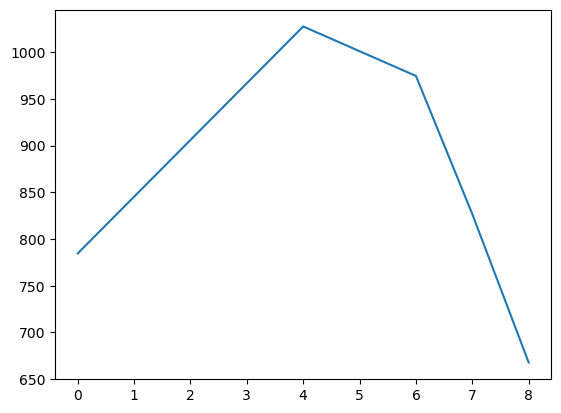

In [17]:
ax=plt.gca()
ax.plot(num39*3.4/0.039+num56*3.4/0.056)

maxsat 15517434893.427643
max1 1.9802292373052565e-05
max2sat 13935837118.159788
max2 1.496290276086984e-05


Text(0.5, 1.0, '500eV output during undulator exchange')

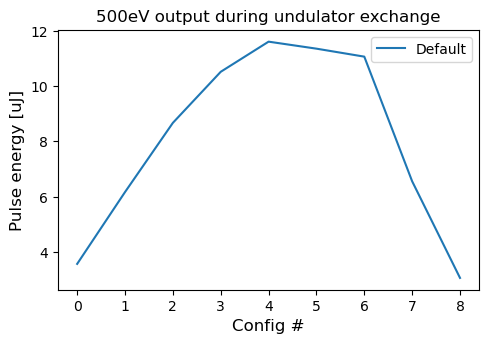

In [40]:
fig = plt.figure(num=1,figsize=[3.375*1.61,3.375])
fig.clf()
ax=plt.subplot(1,1,1)

def max_MX(ts,cur,mxp1,mxp2):
    mxp=mxp1
    MX1=analysis.MingXie(mxp[0],mxp[1],mxp[2],mxp[3],cur,mxp[5],mxp[6],mxp[7],mxp[8])
    Lgs1=MX1['Lg']
    psats1=MX1['Psat']
    p1=power(psats1,gl=Lgs1,und_len=3.4*45,sat_gl=21,postamp=1.25)
    print('maxsat',np.max(psats1))
    print('max1',np.trapz(p1,ts))
    mxp=mxp2
    MX2=analysis.MingXie(mxp[0],mxp[1],mxp[2],mxp[3],cur,mxp[5],mxp[6],mxp[7],mxp[8])
    Lgs2=MX2['Lg']
    psats2=MX2['Psat']
    p1=power(psats2,gl=Lgs2,und_len=3.4*45,sat_gl=21,postamp=1.25)
    print('max2sat',np.max(psats2))
    print('max2',np.trapz(p1,ts))
    
def int_mixed_MX(ts,cur,mxp1,mxp2,n1,n2,stage1only=False):
    mxp=mxp1
    MX1=analysis.MingXie(mxp[0],mxp[1],mxp[2],mxp[3],cur,mxp[5],mxp[6],mxp[7],mxp[8])
    Lgs1=MX1['Lg']
    psats1=MX1['Psat']

    p1=power(psats1,gl=Lgs1,und_len=3.4*n1,sat_gl=21,postamp=2.25)
    if stage1only:
        return np.trapz(p1,ts)

    mxp=mxp2
    MX2=analysis.MingXie(mxp[0],mxp[1],mxp[2],mxp[3],cur,mxp[5],mxp[6],mxp[7],mxp[8])
    Lgs2=MX2['Lg']
    psats2=MX2['Psat']

    # Ok. If stage 1 is only in exp regime, then we need only add a coresponding number of undulators to match # gain lengths. Otherwise, we probably need some kind of averaging of 
    lens=(3.4*n1)/Lgs1*Lgs2 
    p=power(psats2,gl=Lgs2,und_len=3.4*n2+lens,sat_gl=21,postamp=1.25)
    len1=(3.4*n1)/Lgs1-21
    #len1[len1<0]=0
    len2=3.4*n2/Lgs2
    p[len1>0]=p1[len1>0]*len1[len1>0]/(len1[len1>0]+len2[len1>0])+p[len1>0]*len2[len1>0]/(len1[len1>0]+len2[len1>0]);
    p[p1>p]=p1[p1>p]
    p=np.trapz(p,ts)
    
    return p


def mixed_power_estimate(beamEnergy,phEnergy,n1,n2,verbose=False,emi=0.75,dg=2.5):
    gamma0=beamEnergy/0.511
    delgamma=dg/0.511
    current=2.5e3
    emittance=emi*1e-6
    plam=1240e-9/phEnergy
    lamU=0.056
    Kgen=np.sqrt(2*gamma0**2*plam/lamU-1)
    if Kgen>9.21/np.sqrt(2):
        return 0
    L=4.4;
    Bp=3.336 #per GeV in [T m];
    Bdz=np.min([3,Bp*(gamma0*0.511/1000)*2/L-0.1]);
    f=Bp*(gamma0*0.511/1000)/Bdz
    k=2*f/L
    if (k**2-1)<=0:
        return 0
    beta1=L*k*(k+1)/np.sqrt(k**2-1)
    beta2=L*k*(k-1)/np.sqrt(k**2-1)
    sigBeam=np.sqrt(np.sqrt(beta1*beta2)*emittance/gamma0)
    ts=np.linspace(-2,2,200);
    cur=current*np.exp(-0.5*(ts/0.2)**2)
    lamU2=0.039
    Kgen2=np.sqrt(2*gamma0**2*plam/lamU2-1)
    if verbose:
        max_MX(ts*1e-15,cur,[Kgen,2*np.pi/lamU,gamma0,delgamma/gamma0,current,sigBeam,emittance,plam,0],[Kgen2,2*np.pi/lamU2,gamma0,delgamma/gamma0,current,sigBeam,emittance,plam,0])
        return 0
    if Kgen2>5.44/np.sqrt(2):
        p=int_mixed_MX(ts*1e-15,cur,[Kgen,2*np.pi/lamU,gamma0,delgamma/gamma0,current,sigBeam,emittance,plam,0],[Kgen2,2*np.pi/lamU2,gamma0,delgamma/gamma0,current,sigBeam,emittance,plam,0],n1,n2,stage1only=True)
        print('Kgen2 large')
    else:
        p=int_mixed_MX(ts*1e-15,cur,[Kgen,2*np.pi/lamU,gamma0,delgamma/gamma0,current,sigBeam,emittance,plam,0],[Kgen2,2*np.pi/lamU2,gamma0,delgamma/gamma0,current,sigBeam,emittance,plam,0],n1,n2)
    if np.isnan(p):
        return 0
    return p
    


ax=plt.gca()
ph_en=500;
beam_en=3750;
mixed_power_estimate(beam_en, ph_en,num56[5],num39[5],verbose=True)
En = np.empty(num56.shape)
for i in range(num56.shape[0]):
    En[i] = mixed_power_estimate(beam_en, ph_en,num56[i],num39[i]) * 1e6
p=ax.plot(En,label='Default')
#cbar=plt.colorbar(p)
#cbar.set_label('Pulse Energy [mJ]', rotation=270, labelpad=15)
#ax.set_yscale('log')
#ax.set_xscale('log')
plt.legend()
ax.set_xlabel('Config #',fontsize=12)
ax.set_ylabel('Pulse energy [uJ]',fontsize=12)
ax.set_title('500eV output during undulator exchange')

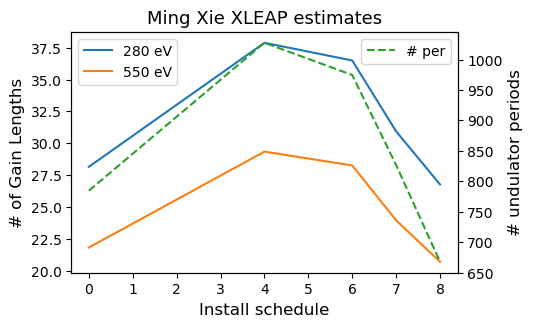

In [51]:
fig = plt.figure(num=1, figsize=[3.375*1.61, 3.375])
fig.clf()
ax = plt.subplot(1, 1, 1)

ph_en = 280
beam_en = 3750
En = np.empty(num56.shape)
for i in range(num56.shape[0]):
    En[i] = mixed_power_estimate(beam_en, ph_en, num56[i], num39[i])
line1, = ax.plot(En, label='280 eV', color='tab:blue')

ph_en = 550
for i in range(num56.shape[0]):
    En[i] = mixed_power_estimate(beam_en, ph_en, num56[i], num39[i])
line2, = ax.plot(En, label='550 eV', color='tab:orange')

# Plotting on the secondary y-axis
ax_r = ax.twinx()
line3, = ax_r.plot(num39 * 3.4 / 0.039 + num56 * 3.4 / 0.056, label='# per', color='tab:green', linestyle='--')
ax_r.set_ylabel('# undulator periods', fontsize=12)

# Legends
# Primary y-axis legend
ax.legend(loc='upper left', fontsize=10)

# Secondary y-axis legend (manually placed)
ax_r.legend(loc='upper right', fontsize=10)

# Axis labels and title
ax.set_xlabel('Install schedule', fontsize=12)
ax.set_ylabel('# of Gain Lengths', fontsize=12)
ax.set_title('Ming Xie XLEAP estimates', fontsize=13)

# Improve layout
plt.tight_layout()
plt.show()

In [52]:
3.4*11/0.056

667.8571428571428

In [56]:
3.5*7.5/0.039

673.0769230769231

## vs e spread for fun?

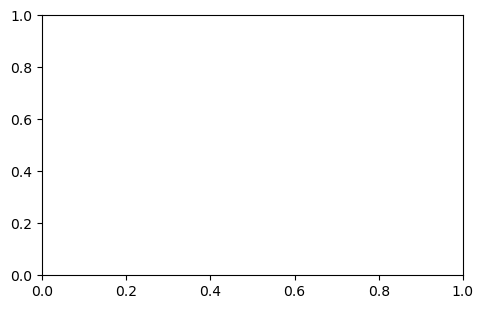

In [21]:
fig = plt.figure(num=1,figsize=[3.375*1.61,3.375])
fig.clf()
ax=plt.subplot(1,1,1)

def max_MX(ts,cur,mxp1,mxp2):
    mxp=mxp1
    MX1=analysis.MingXie(mxp[0],mxp[1],mxp[2],mxp[3],cur,mxp[5],mxp[6],mxp[7],mxp[8])
    Lgs1=MX1['Lg']
    psats1=MX1['Psat']
    p1=power(psats1,gl=Lgs1,und_len=3.4*45,sat_gl=21,postamp=2.25)
    print('maxsat',np.max(psats1))
    print('max1',np.trapz(p1,ts))
    mxp=mxp2
    MX2=analysis.MingXie(mxp[0],mxp[1],mxp[2],mxp[3],cur,mxp[5],mxp[6],mxp[7],mxp[8])
    Lgs2=MX2['Lg']
    psats2=MX2['Psat']
    p1=power(psats2,gl=Lgs2,und_len=3.4*45,sat_gl=21,postamp=2.25)
    print('max2sat',np.max(psats2))
    print('max2',np.trapz(p1,ts))
    
def int_mixed_MX(ts,cur,mxp1,mxp2,n1,n2,stage1only=False):
    mxp=mxp1
    MX1=analysis.MingXie(mxp[0],mxp[1],mxp[2],mxp[3],cur,mxp[5],mxp[6],mxp[7],mxp[8])
    Lgs1=MX1['Lg']
    psats1=MX1['Psat']

    p1=power(psats1,gl=Lgs1,und_len=3.4*n1,sat_gl=21,postamp=2.25)
    if stage1only:
        return np.trapz(p1,ts)

    mxp=mxp2
    MX2=analysis.MingXie(mxp[0],mxp[1],mxp[2],mxp[3],cur,mxp[5],mxp[6],mxp[7],mxp[8])
    Lgs2=MX2['Lg']
    psats2=MX2['Psat']

    # Ok. If stage 1 is only in exp regime, then we need only add a coresponding number of undulators to match # gain lengths. Otherwise, we probably need some kind of averaging of 
    lens=(3.4*n1)/Lgs1*Lgs2 
    p=power(psats2,gl=Lgs2,und_len=3.4*n2+lens,sat_gl=21,postamp=2.25)
    len1=(3.4*n1)/Lgs1-21
    #len1[len1<0]=0
    len2=3.4*n2/Lgs2
    p[len1>0]=p1[len1>0]*len1[len1>0]/(len1[len1>0]+len2[len1>0])+p[len1>0]*len2[len1>0]/(len1[len1>0]+len2[len1>0]);
    p[p1>p]=p1[p1>p]
    p=np.trapz(p,ts)
    
    return p


def mixed_power_estimate(beamEnergy,phEnergy,n1,n2,verbose=False,emi=1,dg=1.5):
    gamma0=beamEnergy/0.511
    delgamma=dg/0.511
    current=1.1e3
    emittance=emi*1e-6
    plam=1240e-9/phEnergy
    lamU=0.056
    Kgen=np.sqrt(2*gamma0**2*plam/lamU-1)
    if Kgen>9.21/np.sqrt(2):
        return 0
    L=4.4;
    Bp=3.336 #per GeV in [T m];
    Bdz=np.min([3,Bp*(gamma0*0.511/1000)*2/L-0.1]);
    f=Bp*(gamma0*0.511/1000)/Bdz
    k=2*f/L
    if (k**2-1)<=0:
        return 0
    beta1=L*k*(k+1)/np.sqrt(k**2-1)
    beta2=L*k*(k-1)/np.sqrt(k**2-1)
    sigBeam=np.sqrt(np.sqrt(beta1*beta2)*emittance/gamma0)
    ts=np.linspace(-100,100,500);
    cur=current*np.exp(-0.5*(ts/12)**2)
    lamU2=0.039
    Kgen2=np.sqrt(2*gamma0**2*plam/lamU2-1)
    if verbose:
        max_MX(ts*1e-15,cur,[Kgen,2*np.pi/lamU,gamma0,delgamma/gamma0,current,sigBeam,emittance,plam,0],[Kgen2,2*np.pi/lamU2,gamma0,delgamma/gamma0,current,sigBeam,emittance,plam,0])
        return 0
    if Kgen2>5.44/np.sqrt(2):
        p=int_mixed_MX(ts*1e-15,cur,[Kgen,2*np.pi/lamU,gamma0,delgamma/gamma0,current,sigBeam,emittance,plam,0],[Kgen2,2*np.pi/lamU2,gamma0,delgamma/gamma0,current,sigBeam,emittance,plam,0],n1,n2,stage1only=True)
        print('Kgen2 large')
    else:
        p=int_mixed_MX(ts*1e-15,cur,[Kgen,2*np.pi/lamU,gamma0,delgamma/gamma0,current,sigBeam,emittance,plam,0],[Kgen2,2*np.pi/lamU2,gamma0,delgamma/gamma0,current,sigBeam,emittance,plam,0],n1,n2)
    if np.isnan(p):
        return 0
    return p
    
#mixed_power_estimate(beam_en, ph_en,num56[i],num39[i],verbose=True)

ax=plt.gca()
ph_en=1080;
beam_en=3800;


En = []
espr=np.linspace(1,5,9);
phens=np.linspace(250,1100,11);
for es in espr:
    for ph in phens:
        En.append(mixed_power_estimate(beam_en, ph ,5,21, dg=es,emi=0.5)*1e3)
En=np.array(En)

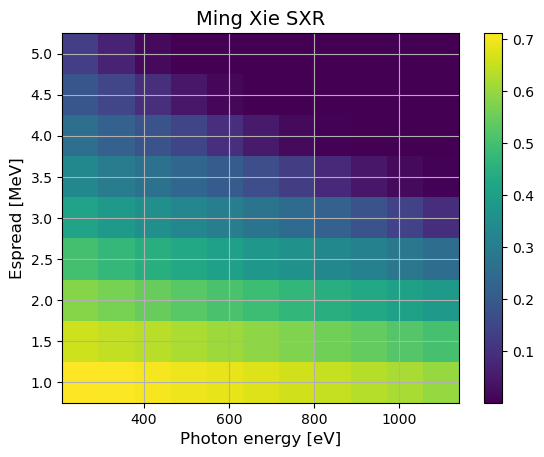

In [27]:
ax=plt.gca()
p=ax.pcolormesh(phens,espr,En.reshape([9,11]))

ax.set_ylabel('Espread [MeV]',fontsize=12)
ax.set_xlabel('Photon energy [eV]',fontsize=12)

plt.colorbar(p)

ax.set_title('Ming Xie SXR',fontsize=14)
ax.grid(which='major')

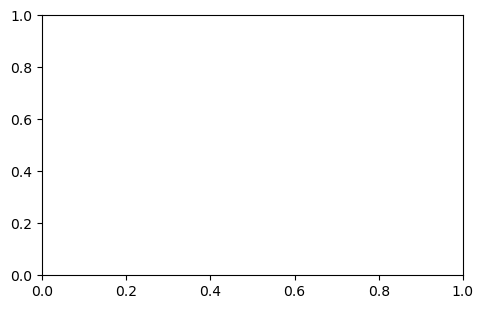

In [29]:
fig = plt.figure(num=1,figsize=[3.375*1.61,3.375])
fig.clf()
ax=plt.subplot(1,1,1)

def max_MX(ts,cur,mxp1,mxp2):
    mxp=mxp1
    MX1=analysis.MingXie(mxp[0],mxp[1],mxp[2],mxp[3],cur,mxp[5],mxp[6],mxp[7],mxp[8])
    Lgs1=MX1['Lg']
    psats1=MX1['Psat']
    p1=power(psats1,gl=Lgs1,und_len=3.4*45,sat_gl=21,postamp=2.25)
    print('maxsat',np.max(psats1))
    print('max1',np.trapz(p1,ts))
    mxp=mxp2
    MX2=analysis.MingXie(mxp[0],mxp[1],mxp[2],mxp[3],cur,mxp[5],mxp[6],mxp[7],mxp[8])
    Lgs2=MX2['Lg']
    psats2=MX2['Psat']
    p1=power(psats2,gl=Lgs2,und_len=3.4*45,sat_gl=21,postamp=2.25)
    print('max2sat',np.max(psats2))
    print('max2',np.trapz(p1,ts))
    
def int_mixed_MX(ts,cur,mxp1,mxp2,n1,n2,stage1only=False):
    mxp=mxp1
    MX1=analysis.MingXie(mxp[0],mxp[1],mxp[2],mxp[3],cur,mxp[5],mxp[6],mxp[7],mxp[8])
    Lgs1=MX1['Lg']
    psats1=MX1['Psat']

    p1=power(psats1,gl=Lgs1,und_len=3.4*n1,sat_gl=21,postamp=2.25)
    if stage1only:
        return np.trapz(p1,ts)

    mxp=mxp2
    MX2=analysis.MingXie(mxp[0],mxp[1],mxp[2],mxp[3],cur,mxp[5],mxp[6],mxp[7],mxp[8])
    Lgs2=MX2['Lg']
    psats2=MX2['Psat']

    # Ok. If stage 1 is only in exp regime, then we need only add a coresponding number of undulators to match # gain lengths. Otherwise, we probably need some kind of averaging of 
    lens=(3.4*n1)/Lgs1*Lgs2 
    p=power(psats2,gl=Lgs2,und_len=3.4*n2+lens,sat_gl=21,postamp=2.25)
    len1=(3.4*n1)/Lgs1-21
    #len1[len1<0]=0
    len2=3.4*n2/Lgs2
    p[len1>0]=p1[len1>0]*len1[len1>0]/(len1[len1>0]+len2[len1>0])+p[len1>0]*len2[len1>0]/(len1[len1>0]+len2[len1>0]);
    p[p1>p]=p1[p1>p]
    p=np.trapz(p,ts)
    
    return p


def mixed_power_estimate(beamEnergy,phEnergy,n1,n2,verbose=False,emi=1,dg=1.5):
    gamma0=beamEnergy/0.511
    delgamma=dg/0.511
    current=1.1e3
    emittance=emi*1e-6
    plam=1240e-9/phEnergy
    lamU=0.056
    Kgen=np.sqrt(2*gamma0**2*plam/lamU-1)
    if Kgen>9.21/np.sqrt(2):
        return 0
    L=4.4;
    Bp=3.336 #per GeV in [T m];
    Bdz=np.min([3,Bp*(gamma0*0.511/1000)*2/L-0.1]);
    f=Bp*(gamma0*0.511/1000)/Bdz
    k=2*f/L
    if (k**2-1)<=0:
        return 0
    beta1=L*k*(k+1)/np.sqrt(k**2-1)
    beta2=L*k*(k-1)/np.sqrt(k**2-1)
    sigBeam=np.sqrt(np.sqrt(beta1*beta2)*emittance/gamma0)
    ts=np.linspace(-100,100,500);
    cur=current*np.exp(-0.5*(ts/12)**2)
    lamU2=0.039
    Kgen2=np.sqrt(2*gamma0**2*plam/lamU2-1)
    if verbose:
        max_MX(ts*1e-15,cur,[Kgen,2*np.pi/lamU,gamma0,delgamma/gamma0,current,sigBeam,emittance,plam,0],[Kgen2,2*np.pi/lamU2,gamma0,delgamma/gamma0,current,sigBeam,emittance,plam,0])
        return 0
    if Kgen2>5.44/np.sqrt(2):
        p=int_mixed_MX(ts*1e-15,cur,[Kgen,2*np.pi/lamU,gamma0,delgamma/gamma0,current,sigBeam,emittance,plam,0],[Kgen2,2*np.pi/lamU2,gamma0,delgamma/gamma0,current,sigBeam,emittance,plam,0],n1,n2,stage1only=True)
        print('Kgen2 large')
    else:
        p=int_mixed_MX(ts*1e-15,cur,[Kgen,2*np.pi/lamU,gamma0,delgamma/gamma0,current,sigBeam,emittance,plam,0],[Kgen2,2*np.pi/lamU2,gamma0,delgamma/gamma0,current,sigBeam,emittance,plam,0],n1,n2)
    if np.isnan(p):
        return 0
    return p
    
#mixed_power_estimate(beam_en, ph_en,num56[i],num39[i],verbose=True)

ax=plt.gca()
ph_en=1000;
beam_en=3800;


En = []
espr=np.linspace(1,5,9);
emits=np.linspace(0.3,0.8,9);
for es in espr:
    for em in emits:
        En.append(mixed_power_estimate(beam_en, ph_en ,5,21, dg=es,emi=em)*1e3)
En=np.array(En)

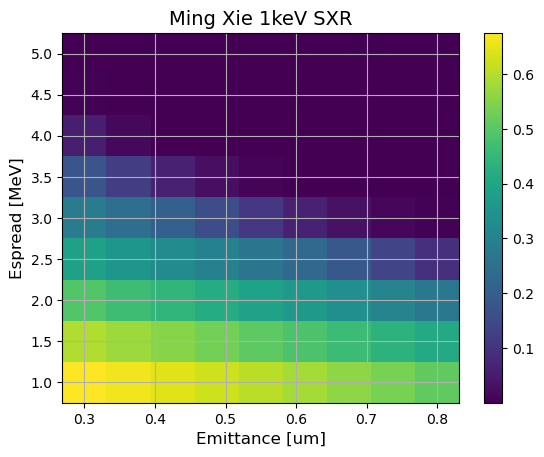

In [33]:
ax=plt.gca()
p=ax.pcolormesh(emits,espr,En.reshape([9,9]))

ax.set_ylabel('Espread [MeV]',fontsize=12)
ax.set_xlabel('Emittance [um]',fontsize=12)

plt.colorbar(p)

ax.set_title('Ming Xie 1keV SXR',fontsize=14)
ax.grid(which='major')

## End

# Induction linac

Search around CW 1kA, 1 GeV, 200um emittance, 1% energy spread

In [8]:
from scipy.optimize import brentq

qe = 1.602e-19      # C
me = 9.109e-31      # kg
c_light = 2.998e8   # m/s

nom_energy = 1000 #MeV
nom_emi = 200e-6 #normalized slice
nom_current = 1e3 # amps
nom_dgamma = 0.01*nom_energy #MeV
duty_cycle=100e-9/(1/120)  # 100ns at 120Hz

print(f'Beam current: {nom_current*duty_cycle} A')
print(f'Beam power: {nom_current*duty_cycle*nom_energy*1e6*1e-3:2.2f} kW')

Beam current: 0.012 A
Beam power: 12000.00 kW


In [12]:
#Magnetic field parameterization (conventional hybrid)
def B0_hybrid(gap, lam_u, Br=1.3): #1.3 matches lcls roughly
    a = 0.55*Br + 2.835
    b = -1.95*Br + 7.225
    c = -1.3*Br + 2.97
    B0 = a * np.exp(-b*(gap/lam_u) + c*(gap/lam_u)**2)
    return B0

def K_hybrid(gap, lam_u):
    B0 = B0_hybrid(gap, lam_u)
    K = qe * B0 * lam_u / (2*np.pi * me * c_light)
    return K
print(K_hybrid(7.2e-3,26e-3)) #lcls hxr 7.2mm gap 26mm period -->2.6=K

def K_required(lam_u, gamma, photon_eV):
    lam_ph = 1.2398e-6 / photon_eV
    val = 2 * (2 * gamma**2 * lam_ph / lam_u - 1)
    return np.sqrt(val) if val > 0 else np.nan


from scipy.special import j0, j1
# Resonance helper: beam energy for given photon, lambda_u, and K
def beam_energy_for_photon(photon_eV, lam_u, K):
    lam_ph = 1.2398e-6 / photon_eV  # m
    inside = lam_u * (1 + K**2 / 2) / (2 * lam_ph)
    gamma = np.sqrt(inside)
    return gamma * 0.511e-3  # GeV

# JJ factor (for planar undulator)
def JJ(K):
    x = K**2 / (4 + 2*K**2)
    return j0(x) - j1(x)

2.593960946365298


### Single undulator tuning

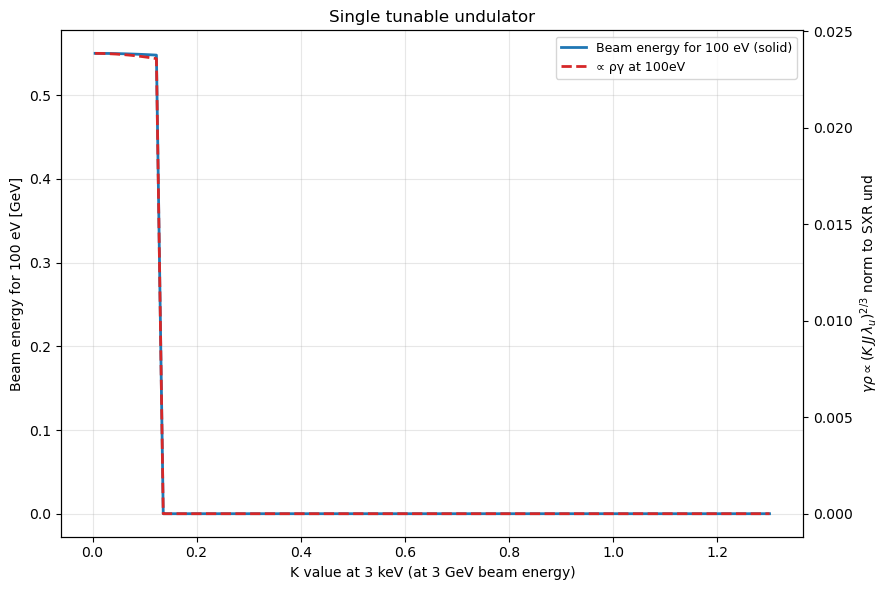

In [17]:
from scipy.special import j0, j1

# Resonance helper: beam energy for given photon, lambda_u, and K
def beam_energy_for_photon(photon_eV, lam_u, K):
    lam_ph = 1.2398e-6 / photon_eV  # m
    inside = lam_u * (1 + K**2 / 2) / (2 * lam_ph)
    gamma = np.sqrt(inside)
    return gamma * 0.511e-3  # GeV

# JJ factor (for planar undulator)
def JJ(K):
    x = K**2 / (4 + 2*K**2)
    return j0(x) - j1(x)

# Fixed parameters
E_beam_3keV = 3.0  # GeV
photon_3keV = 3000.0  # eV
photon_100eV = 100.0  # eV
gap_min = 50e-3      # m

# Range of K3 values to scan (1–4 is reasonable)
K3_vals = np.linspace(0.005, 1.3, 100)

# Arrays to fill
lam_u_vals = np.zeros_like(K3_vals)
E100_vals = np.zeros_like(K3_vals)
K100_vals = np.zeros_like(K3_vals)
rho_scaled = np.zeros_like(K3_vals)

gamma3 = E_beam_3keV * 1e3 / 0.511
lam_ph_3keV = 1.2398e-6 / photon_3keV

for i, K3 in enumerate(K3_vals):
    # --- Step 1: determine undulator period from 3 keV @ 3 GeV ---
    lam_u = 2 * lam_ph_3keV * gamma3**2 / (1 + K3**2 / 2)
    lam_u_vals[i] = lam_u * 1e3  # mm for plotting
    if K_hybrid(gap_min, lam_u) < K3:
        continue

    # --- Step 2: determine K at 100 eV with min mm gap ---
    K100 = K_hybrid(gap_min, lam_u)
    K100_vals[i] = K100

    # --- Step 3: compute beam energy to get 100 eV with that K and lambda_u ---
    E100 = beam_energy_for_photon(photon_100eV, lam_u, K100)
    E100_vals[i] = E100

    # --- Step 4: scaled FEL rho proxy ---
    gamma100 = E100 * 1e3 / 0.511
    rho_scaled[i] = (K100 * JJ(K100)*lam_u)**(2/3)#/rho23ref

# --- Plot ---
fig, ax1 = plt.subplots(figsize=(9,6))
ax2 = ax1.twinx()

ax1.plot(K3_vals, E100_vals, lw=2, label="Beam energy for 100 eV (solid)")
ax2.plot(K3_vals, rho_scaled, '--', lw=2, color='tab:red',
         label="∝ ργ at 100eV")

ax1.set_xlabel("K value at 3 keV (at 3 GeV beam energy)")
ax1.set_ylabel("Beam energy for 100 eV [GeV]")
ax2.set_ylabel(r"$\gamma \rho \propto (K \, JJ \, \lambda_u)^{2/3}$ norm to SXR und")
ax1.grid(True, alpha=0.3)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="best", fontsize=9)

plt.title("Single tunable undulator")
plt.tight_layout()
plt.show()


### Scaling to high photon energy

In [ ]:
def mx_power(phEnergy,emittance,gamma0,uLen=105):
    delgamma=3/0.511
    current=3.4e3
    #emittance=0.27e-6
    plam=1240e-9/phEnergy
    lamU=0.026
    if 2*gamma0**2*plam/lamU-1<0:
        return 0
    Kgen=np.sqrt(2*gamma0**2*plam/lamU-1)
    
    Bp=3.336 #per GeV in [T m], 
    L=4.03
    Bdz=3; #tesla
    f=Bp*(gamma0*0.511/1000)/Bdz
    k=2*f/L
    beta1=L*k*(k+1)/np.sqrt(k**2-1)
    beta2=L*k*(k-1)/np.sqrt(k**2-1)
    sigBeam=(np.sqrt(beta1*emittance/gamma0)+np.sqrt(beta2*emittance/gamma0))/2;
    
    MX=analysis.MingXie(Kgen,2*np.pi/lamU,gamma0,delgamma/gamma0,current,sigBeam,emittance,plam,0)
    #print(MX)
    Lg=MX['Lg']
    return power(MX['Psat'],gl=Lg,und_len=105,sat_gl=16)
mx_power(18e3,0.5e-6,14.5e3/0.511)*1e-9

NameError: name 'power' is not defined

In [ ]:
mx_power(10e3,0.5e-6,8e3/0.511)*1e-9

3.352044257093609

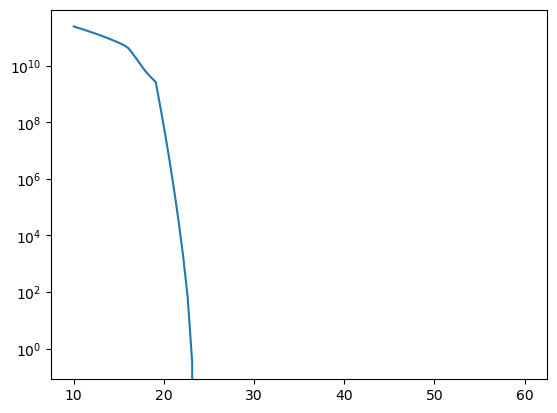

In [ ]:
ax=plt.gca()
emis=np.arange(0.1,0.7,0.1)*1e-6
gamma0s=np.arange(8000,28000,4000)/0.511
phEs=np.linspace(10,60,100);
est_powers=np.zeros((len(emis),len(gamma0s),len(phEs)))
for ii,emi in enumerate(emis):
    for jj,gamma0 in enumerate(gamma0s):
        for kk, phE in enumerate(phEs):
            est_powers[ii,jj,kk]= mx_power(phE*1e3,emi,gamma0)
ax.semilogy(phEs,est_powers[0,0,:])
plt.show()

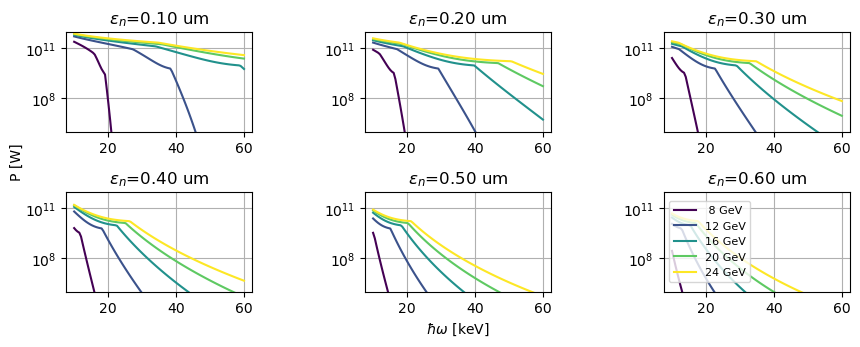

In [ ]:
fig = plt.figure(num=1,figsize=[3.375*3,3.375*1])
fig.clf()
nplots=len(emis)
nrows=2
ncols=int(np.ceil(nplots/nrows))
outer_grid=fig.add_gridspec(nrows,ncols,wspace=0.6,hspace=0.6)


ax_bottom = fig.add_subplot(outer_grid[-1, :])
[ax_bottom.spines[x].set_visible(False) for x in ['top','bottom','left','right']]
ax_bottom.set_xticks([])  # Remove x-ticks
ax_bottom.set_yticks([])  # Remove y-ticks
ax_bottom.set_xlabel("$\hbar\omega$ [keV]",labelpad=21)
ax_left = fig.add_subplot(outer_grid[:, 0])
[ax_left.spines[x].set_visible(False) for x in ['top','bottom','left','right']]
ax_left.set_xticks([])  # Remove x-ticks
ax_left.set_yticks([])  # Remove y-ticks
ax_left.set_ylabel("P [W]",labelpad=30)

for ii,emi in enumerate(emis):
    ax=fig.add_subplot(outer_grid[ii])
    ax.set_title('$\epsilon_n$={:0.2f} um'.format(emi*1e6))
    ax.set_ylim([1e6,1e12])
    ax.grid()
    for jj,gamma0 in enumerate(gamma0s):
        color=cm.viridis((gamma0-np.min(gamma0s))/np.ptp(gamma0s))
        ax.semilogy(phEs,est_powers[ii,jj,:],color=color,label='{:2.0f} GeV'.format(gamma0*0.511/1000))
        
    if ii==len(emis)-1:
        plt.legend(fontsize=8,loc=6)
        


plt.show()